# ✈️ NASA C-MAPSS FD001 — 통합 분석 노트북

**EDA · 통계 검정 · 전처리 파이프라인 · ML 분기 · DL 분기**

---

공통 파이프라인: 상수 센서 제거 → RUL cap=125 → Gaussian(σ=2) → Validation 분할 → MinMax 정규화  
ML 분기: lag·diff·rolling·std·EMA → 파생변수 생성 → XGBoost / LightGBM + NASA S-Score  
DL 분기: 슬라이딩 윈도우(W=30) → Long Format CSV 저장 + val_eval(수명 50~90% 절단)

### 📋 전체 목차
| # | 섹션 | 핵심 내용 |
|---|------|----------|
| 0 | 환경 설정 | 라이브러리 설치 & 전역 상수 |
| 1 | 데이터 로딩 | 자동 경로 탐색 & 컬럼 표준화 |
| 2 | 전처리 전 EDA | 품질검사 · 수명분포 · 센서분포 · 트렌드 · RUL상관 · 시계열추세 |
| 3 | 통계 검정 | 시차상관 · Mann-Kendall · 대응표본검정 |
| 4-8 | 전처리 결정 1~5 | 상수센서제거 · RUL Cap · Gaussian · Validation분할 · MinMax |
| 9 | 전처리 후 검증 | 상관관계·분포·KS검정·열화트렌드·다중공선성 |
| 10 | ML 분기 | 파생변수 · 롤링피처 · XGBoost · LightGBM · NASA S-Score |
| 11 | DL 분기 | 슬라이딩윈도우 · val_eval 생성 |

## 0. 환경 설정

### 💡 왜 필요한가?
분석에 필요한 라이브러리를 설치하고, 전체 노트북에서 공유하는 전역 상수를 정의합니다.

In [1]:
import sys, subprocess
for pkg in ['numpy','pandas','scikit-learn','scipy','matplotlib','seaborn',
            'statsmodels','xgboost','lightgbm','tqdm','joblib']:
    try:
        subprocess.check_call([sys.executable,'-m','pip','install','-q',pkg])
    except Exception as e:
        print(f'⚠️ {pkg} 설치 실패: {e}')
print('✅ 라이브러리 설치 완료')


✅ 라이브러리 설치 완료


In [2]:
import os, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import platform
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from scipy.stats import ks_2samp, kendalltau, ttest_rel, shapiro, wilcoxon
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from statsmodels.tsa.stattools import adfuller
import logging
import matplotlib.font_manager as fm

warnings.filterwarnings('ignore')
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# ── 한글 폰트 ─────────────────────────────────────────────────────
def force_korean_font():
    system = platform.system()
    if system == 'Windows':
        font_path, font_name = 'C:/Windows/Fonts/malgun.ttf', 'Malgun Gothic'
    elif system == 'Darwin':
        font_path, font_name = '/System/Library/Fonts/AppleGothic.ttf', 'AppleGothic'
    else:
        font_path, font_name = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf', 'NanumGothic'
        if not os.path.exists(font_path):
            os.system('apt-get update -qq && apt-get install -y fonts-nanum -qq')
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rcParams['font.family'] = font_name
        plt.rcParams['font.sans-serif'] = [font_name]
        plt.rcParams['axes.unicode_minus'] = False
        print(f'✅ 한글 폰트 적용: {font_name}')
    else:
        print('❌ 폰트 못 찾음 — 한글 깨짐 발생 가능')

force_korean_font()

# ── 다크 테마 ──────────────────────────────────────────────────────
BG, BG2, GRID = '#0f1117', '#1a1d2e', '#2d3148'
WHITE, GRAY   = '#ffffff', '#aaaaaa'
C = ['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8','#00b894','#e17055']

plt.rcParams.update({
    'figure.facecolor':BG,  'axes.facecolor':BG2,
    'axes.edgecolor':GRID,  'axes.labelcolor':GRAY,
    'xtick.color':GRAY,     'ytick.color':GRAY,
    'text.color':WHITE,     'grid.color':GRID,
    'grid.alpha':0.4,       'axes.grid':True,
    'font.size':10,         'axes.titlesize':11,
    'legend.facecolor':BG2, 'legend.edgecolor':GRID,
})
force_korean_font()

# ── 전역 상수 ──────────────────────────────────────────────────────
RAW_COLS = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]

RENAME_MAP = {
    'unit':'unit_nr', 'cycle':'time_cycles',
    'op1':'setting_1','op2':'setting_2','op3':'setting_3',
    **{f's{i}':f's_{i}' for i in range(1,22)}
}

SENSOR_COLS  = [f's_{i}' for i in range(1,22)]
OP_COLS      = ['setting_1','setting_2','setting_3']
ID_COLS      = ['unit_nr','time_cycles']
RUL_CAP      = 125
GAUSS_SIGMA  = 2
CONST_THR    = 0.01

# ML 파생변수 파라미터
TEMPORAL_LAGS      = [1, 3, 5]
TEMPORAL_DIFFS     = [1]
TEMPORAL_ROLLS     = [3, 5]
TEMPORAL_ROLL_STDS = [3, 5]
TEMPORAL_EMAS      = [5]

SENSOR_DESC = {
    's_1':'T2 팬 입구 온도(°R)',       's_2':'T24 LPC 출구 온도(°R)',
    's_3':'T30 HPC 출구 온도(°R)',     's_4':'T50 LPT 출구 온도(°R)',
    's_5':'P2 팬 입구 압력(psia)',      's_6':'P15 바이패스 압력(psia)',
    's_7':'P30 HPC 출구 압력(psia)',   's_8':'Nf 팬 속도(rpm)',
    's_9':'Nc 코어 속도(rpm)',          's_10':'epr 엔진 압력비',
    's_11':'Ps30 정적압력(psia)',       's_12':'phi 연료/Ps30 비율',
    's_13':'NRf 보정 팬 속도(rpm)',     's_14':'NRc 보정 코어속도(rpm)',
    's_15':'BPR 바이패스 비율',         's_16':'farB 버너 연료공기비',
    's_17':'htBleed 블리드 엔탈피',     's_18':'Nf_dmd 요구 팬 속도',
    's_19':'PCNfR 요구 보정 팬속도',    's_20':'W31 HPT 냉각블리드',
    's_21':'W32 LPT 냉각블리드',
}

print('✅ 환경 설정 완료')
print(f'   RUL Cap={RUL_CAP}  |  σ={GAUSS_SIGMA}  |  상수 기준 std<{CONST_THR}')
print(f'   ML lag={TEMPORAL_LAGS} diff={TEMPORAL_DIFFS} roll={TEMPORAL_ROLLS} roll_std={TEMPORAL_ROLL_STDS} ema={TEMPORAL_EMAS}')


✅ 한글 폰트 적용: Malgun Gothic
✅ 한글 폰트 적용: Malgun Gothic
✅ 환경 설정 완료
   RUL Cap=125  |  σ=2  |  상수 기준 std<0.01
   ML lag=[1, 3, 5] diff=[1] roll=[3, 5] roll_std=[3, 5] ema=[5]


---
## 1. 데이터 로딩 & 컬럼명 표준화

In [3]:
# ── 자동 경로 탐색 (CMAPSSData 폴더 위치를 자동으로 찾습니다) ──
DATA_DIR = 'CMAPSSData'
for c in ['CMAPSSData','./CMAPSSData','../CMAPSSData','../../CMAPSSData',
          '../../../CMAPSSData','../../../../CMAPSSData']:
    if os.path.exists(os.path.join(c,'train_FD001.txt')):
        DATA_DIR = c; break
else:
    print(f'❌ CMAPSSData 폴더를 찾지 못했습니다. 현재 위치: {os.getcwd()}')
    print('   DATA_DIR 변수를 실제 경로로 직접 수정해주세요.')

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_FD001.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_FD001.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'], engine='python')

# 컬럼명 표준화
train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename( columns=RENAME_MAP, inplace=True)

print(f'✅ FD001 로딩 완료')
print(f'   Train : {train_raw.shape}  |  엔진 {train_raw["unit_nr"].nunique()}대')
print(f'   Test  : {test_raw.shape}   |  엔진 {test_raw["unit_nr"].nunique()}대')
print(f'   RUL   : {rul_df.shape}')
print(f'\n표준화 컬럼: {list(train_raw.columns)}')
display(train_raw.head(3))


✅ FD001 로딩 완료
   Train : (20631, 26)  |  엔진 100대
   Test  : (13096, 26)   |  엔진 100대
   RUL   : (100, 1)

표준화 컬럼: ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21']


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442


---
## 2. 전처리 전 EDA
### 2-1. 기초 통계 & 데이터 품질

In [4]:
print('=== 기초 통계 & 데이터 품질 검사 ===')

quality = pd.DataFrame({
    '구분'       : ['Train','Test'],
    '전체 행'    : [len(train_raw), len(test_raw)],
    '결측치'     : [train_raw.isnull().sum().sum(), test_raw.isnull().sum().sum()],
    '중복 행'    : [train_raw.duplicated().sum(), test_raw.duplicated().sum()],
    '음수 센서'  : [(train_raw[SENSOR_COLS]<0).sum().sum(), (test_raw[SENSOR_COLS]<0).sum().sum()],
    '엔진 수'    : [train_raw['unit_nr'].nunique(), test_raw['unit_nr'].nunique()],
    '판정'       : ['✅ 정상','✅ 정상'],
}).set_index('구분')
display(quality)

print('\n--- 센서별 기술통계 (Train) ---')
desc = train_raw[SENSOR_COLS].describe().T
desc['CV(변동계수)'] = (desc['std'] / desc['mean'].abs()).round(5)
display(desc[['mean','std','min','max','CV(변동계수)']]
        .style.background_gradient(subset=['CV(변동계수)'], cmap='YlOrRd').format('{:.4f}'))

print('\n📌 CV(변동계수) ≈ 0 인 센서 = 비행 내내 거의 같은 값 = 열화 정보 없음 → 제거 대상')


=== 기초 통계 & 데이터 품질 검사 ===


,전체 행,결측치,중복 행,음수 센서,엔진 수,판정
구분,,,,,,
Train,20631,0,0,0,100,✅ 정상
Test,13096,0,0,0,100,✅ 정상



--- 센서별 기술통계 (Train) ---


,mean,std,min,max,CV(변동계수)
s_1,518.6700,0.0000,518.6700,518.6700,0.0000
s_2,642.6809,0.5001,641.2100,644.5300,0.0008
s_3,1590.5231,6.1311,1571.0400,1616.9100,0.0039
s_4,1408.9338,9.0006,1382.2500,1441.4900,0.0064
s_5,14.6200,0.0000,14.6200,14.6200,0.0000
s_6,21.6098,0.0014,21.6000,21.6100,0.0001
s_7,553.3677,0.8851,549.8500,556.0600,0.0016
s_8,2388.0967,0.0710,2387.9000,2388.5600,0.0000
s_9,9065.2429,22.0829,9021.7300,9244.5900,0.0024
s_10,1.3000,0.0000,1.3000,1.3000,0.0000



📌 CV(변동계수) ≈ 0 인 센서 = 비행 내내 거의 같은 값 = 열화 정보 없음 → 제거 대상


### 📊 2-1. 기초 통계 & 데이터 품질 검사 결과

---

#### 데이터 품질 확인
| 항목 | Train | Test |
|------|-------|------|
| 전체 행 | 20,631 | 13,096 |
| 결측치 | 0 | 0 |
| 중복 행 | 0 | 0 |
| 음수 센서 | 0 | 0 |
| 엔진 수 | 100 | 100 |

> ✅ 결측치, 중복, 음수 전부 없음 → C-MAPSS는 컴퓨터 시뮬레이션 데이터라 매우 깨끗함  
> → 별도 결측치 처리 불필요

#### 🔑 핵심 결론
> **데이터 품질 이상 없음**  
> **s_1, s_5, s_6, s_10, s_16, s_18, s_19 → CV≈0 → 상수 센서 → 제거 대상**  
> **나머지 14개 센서 → 열화 정보 포함 가능 → 유지**


### 2-2. 엔진 수명 분포

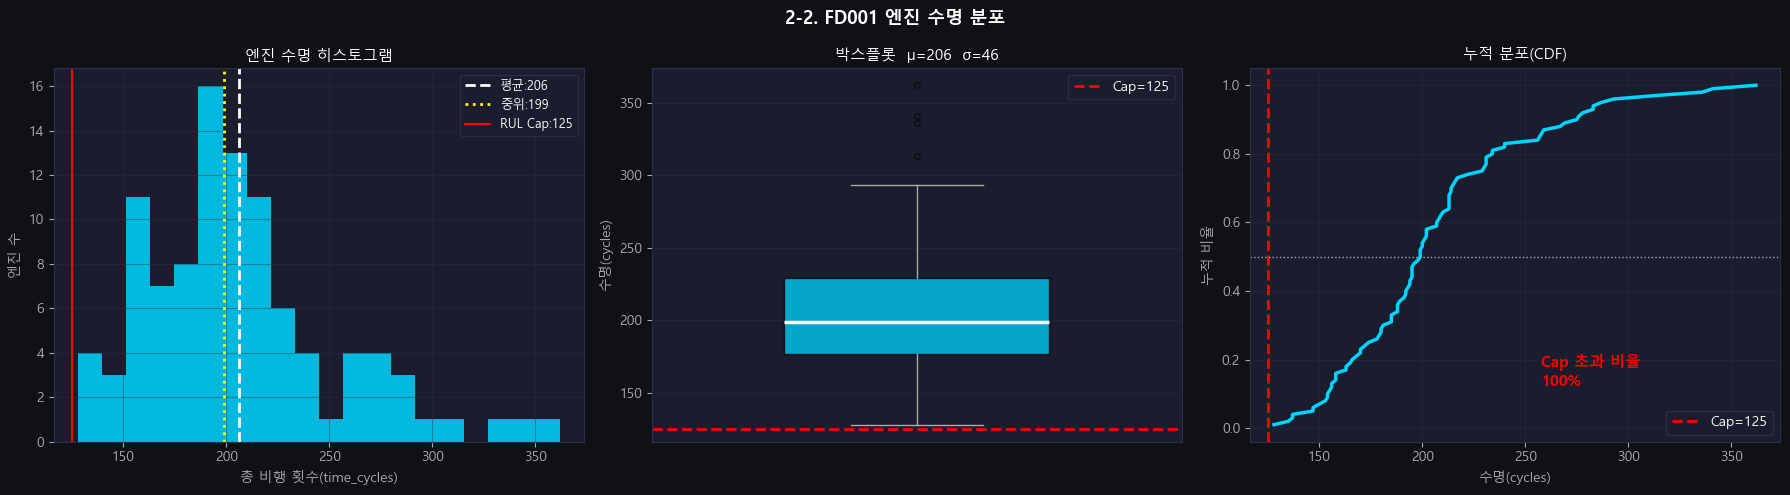


엔진 수명 통계:
  평균=206.3  중위=199.0  min=128  max=362
  Cap=125 초과 엔진: 100대 (100%)

📌 100% 엔진이 수명 125 사이클 초과 → Cap=125 설정 근거


In [5]:
lifecycles = train_raw.groupby('unit_nr')['time_cycles'].max()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('2-2. FD001 엔진 수명 분포', fontsize=13, fontweight='bold')

ax = axes[0]
ax.hist(lifecycles, bins=20, color=C[0], alpha=0.85, edgecolor='none')
ax.axvline(lifecycles.mean(),   color='white',  ls='--', lw=2, label=f'평균:{lifecycles.mean():.0f}')
ax.axvline(lifecycles.median(), color='yellow', ls=':',  lw=2, label=f'중위:{lifecycles.median():.0f}')
ax.axvline(RUL_CAP, color='red', ls='-', lw=1.5, label=f'RUL Cap:{RUL_CAP}')
ax.set_xlabel('총 비행 횟수(time_cycles)'); ax.set_ylabel('엔진 수')
ax.set_title('엔진 수명 히스토그램'); ax.legend(fontsize=9)

ax = axes[1]
bp = ax.boxplot(lifecycles, patch_artist=True, vert=True, widths=0.5,
                medianprops=dict(color='white',lw=2.5),
                whiskerprops=dict(color=GRAY), capprops=dict(color=GRAY),
                flierprops=dict(marker='o',color=GRAY,markersize=4,alpha=0.5))
bp['boxes'][0].set_facecolor(C[0]); bp['boxes'][0].set_alpha(0.75)
ax.axhline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.set_ylabel('수명(cycles)')
ax.set_title(f'박스플롯  μ={lifecycles.mean():.0f}  σ={lifecycles.std():.0f}')
ax.set_xticks([]); ax.legend()

ax = axes[2]
lc_sorted = np.sort(lifecycles)
cdf = np.arange(1, len(lc_sorted)+1)/len(lc_sorted)
ax.plot(lc_sorted, cdf, color=C[0], lw=2.5)
ax.axvline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.axhline(0.5, color=GRAY, ls=':', lw=1)
pct_above = (lifecycles > RUL_CAP).mean()*100
ax.text(0.55, 0.15, f'Cap 초과 비율\n{pct_above:.0f}%', transform=ax.transAxes,
        fontsize=11, color='red', fontweight='bold')
ax.set_xlabel('수명(cycles)'); ax.set_ylabel('누적 비율')
ax.set_title('누적 분포(CDF)'); ax.legend()

plt.tight_layout(); plt.show()

print(f'\n엔진 수명 통계:')
print(f'  평균={lifecycles.mean():.1f}  중위={lifecycles.median():.1f}  min={lifecycles.min()}  max={lifecycles.max()}')
print(f'  Cap={RUL_CAP} 초과 엔진: {(lifecycles>RUL_CAP).sum()}대 ({pct_above:.0f}%)')
print(f'\n📌 100% 엔진이 수명 {RUL_CAP} 사이클 초과 → Cap={RUL_CAP} 설정 근거')


### 📊 2-2. 엔진 수명 분포 분석 결과

---

- **150~250 구간에 엔진이 가장 많이 분포** — 평균 206번, 중위수 199번
- 빨간 수직선(Cap=125): **모든 엔진이 이 선 오른쪽에 위치** → 어떤 엔진도 125사이클 이전에 고장나지 않음
- CDF에서 Cap=125 이하 엔진이 0% → **Cap=125 설정의 데이터 기반 근거** ✅


### 2-3. 운전 조건 & 센서 추세 시각화 (EDA)

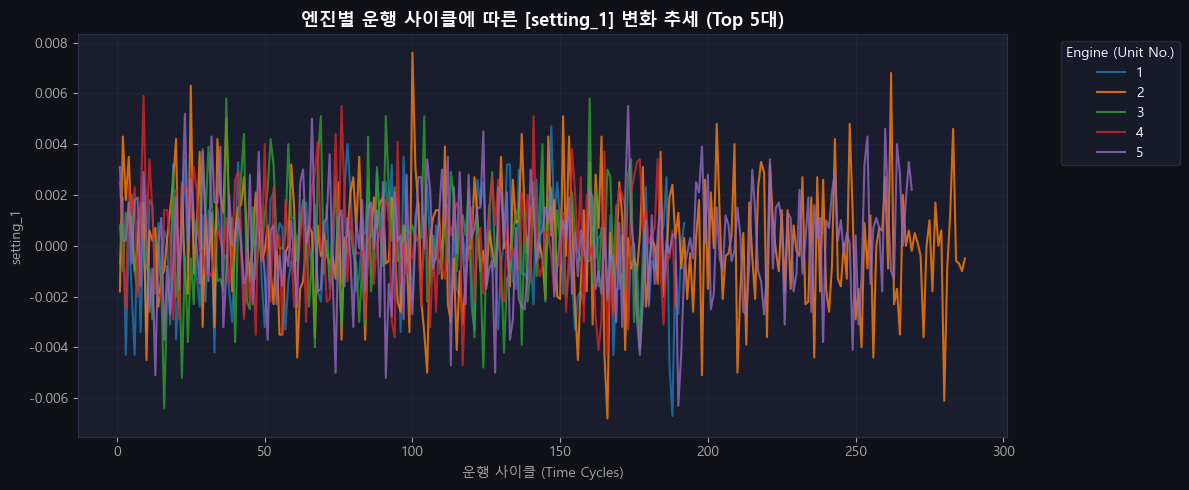

In [6]:
# 운전 조건(setting_1) 엔진별 사이클 추세
def plot_engine_trend(df, target_col='setting_1', num_engines=5):
    """지정된 개수의 엔진에 대해 특정 컬럼의 사이클별 변화를 선 그래프로 시각화"""
    plt.figure(figsize=(12, 5))
    engine_ids = df['unit_nr'].unique()[:num_engines]
    sample_df = df[df['unit_nr'].isin(engine_ids)]
    sns.lineplot(data=sample_df, x='time_cycles', y=target_col,
                 hue='unit_nr', palette='tab10', linewidth=1.5, alpha=0.8)
    plt.title(f'엔진별 운행 사이클에 따른 [{target_col}] 변화 추세 (Top {num_engines}대)',
              fontsize=13, fontweight='bold')
    plt.xlabel('운행 사이클 (Time Cycles)'); plt.ylabel(target_col)
    plt.legend(title='Engine (Unit No.)', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout(); plt.show()

plot_engine_trend(train_raw, target_col='setting_1', num_engines=5)


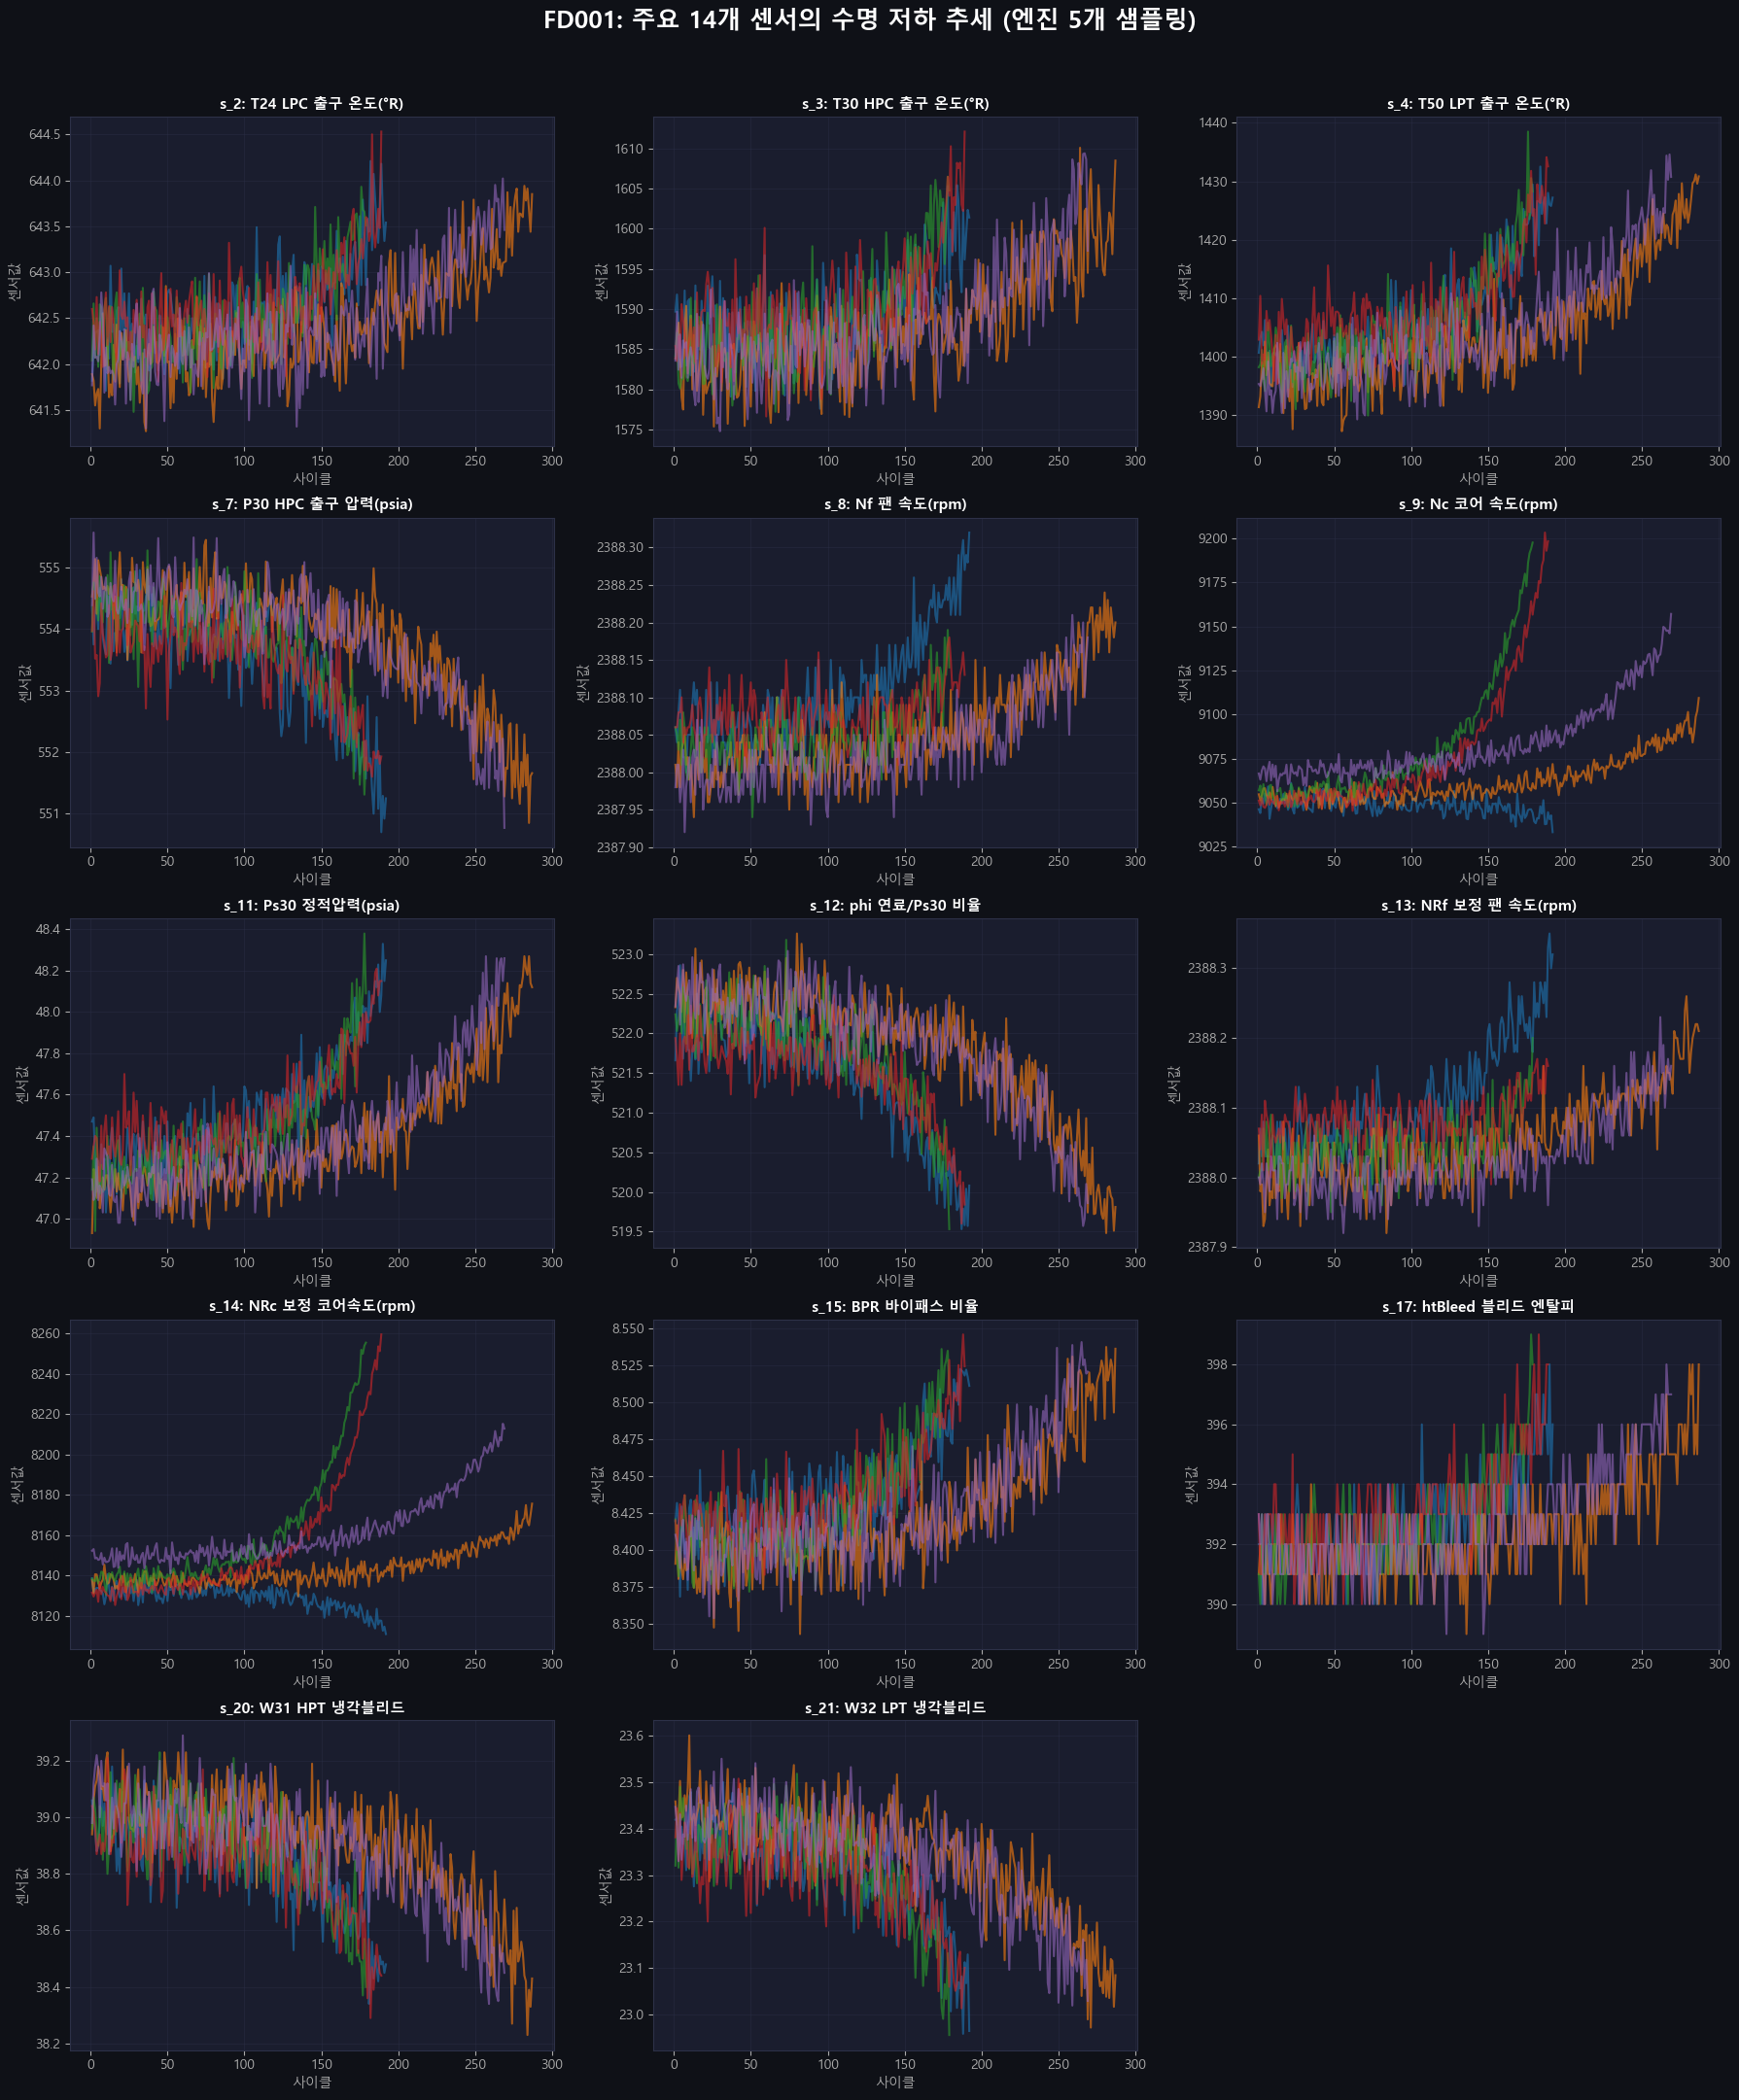

In [7]:
# 14개 유용 센서 — 모든 엔진 수명 추세 (5개 샘플링)
sensor_14 = ['s_2','s_3','s_4','s_7','s_8','s_9','s_11',
             's_12','s_13','s_14','s_15','s_17','s_20','s_21']
sample_units_5 = train_raw['unit_nr'].unique()[:5]

fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()
for i, sensor in enumerate(sensor_14):
    for unit in sample_units_5:
        unit_data = train_raw[train_raw['unit_nr'] == unit]
        axes[i].plot(unit_data['time_cycles'], unit_data[sensor], alpha=0.6, label=f'Unit {unit}')
    axes[i].set_title(f'{sensor}: {SENSOR_DESC.get(sensor,sensor)[:25]}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('사이클'); axes[i].set_ylabel('센서값')
axes[-1].axis('off')
plt.tight_layout(); plt.subplots_adjust(top=0.93)
fig.suptitle('FD001: 주요 14개 센서의 수명 저하 추세 (엔진 5개 샘플링)', fontsize=18, fontweight='bold')
plt.show()


### 2-4. 센서 분포 & 이상치 (전처리 전 — 21개 전체)

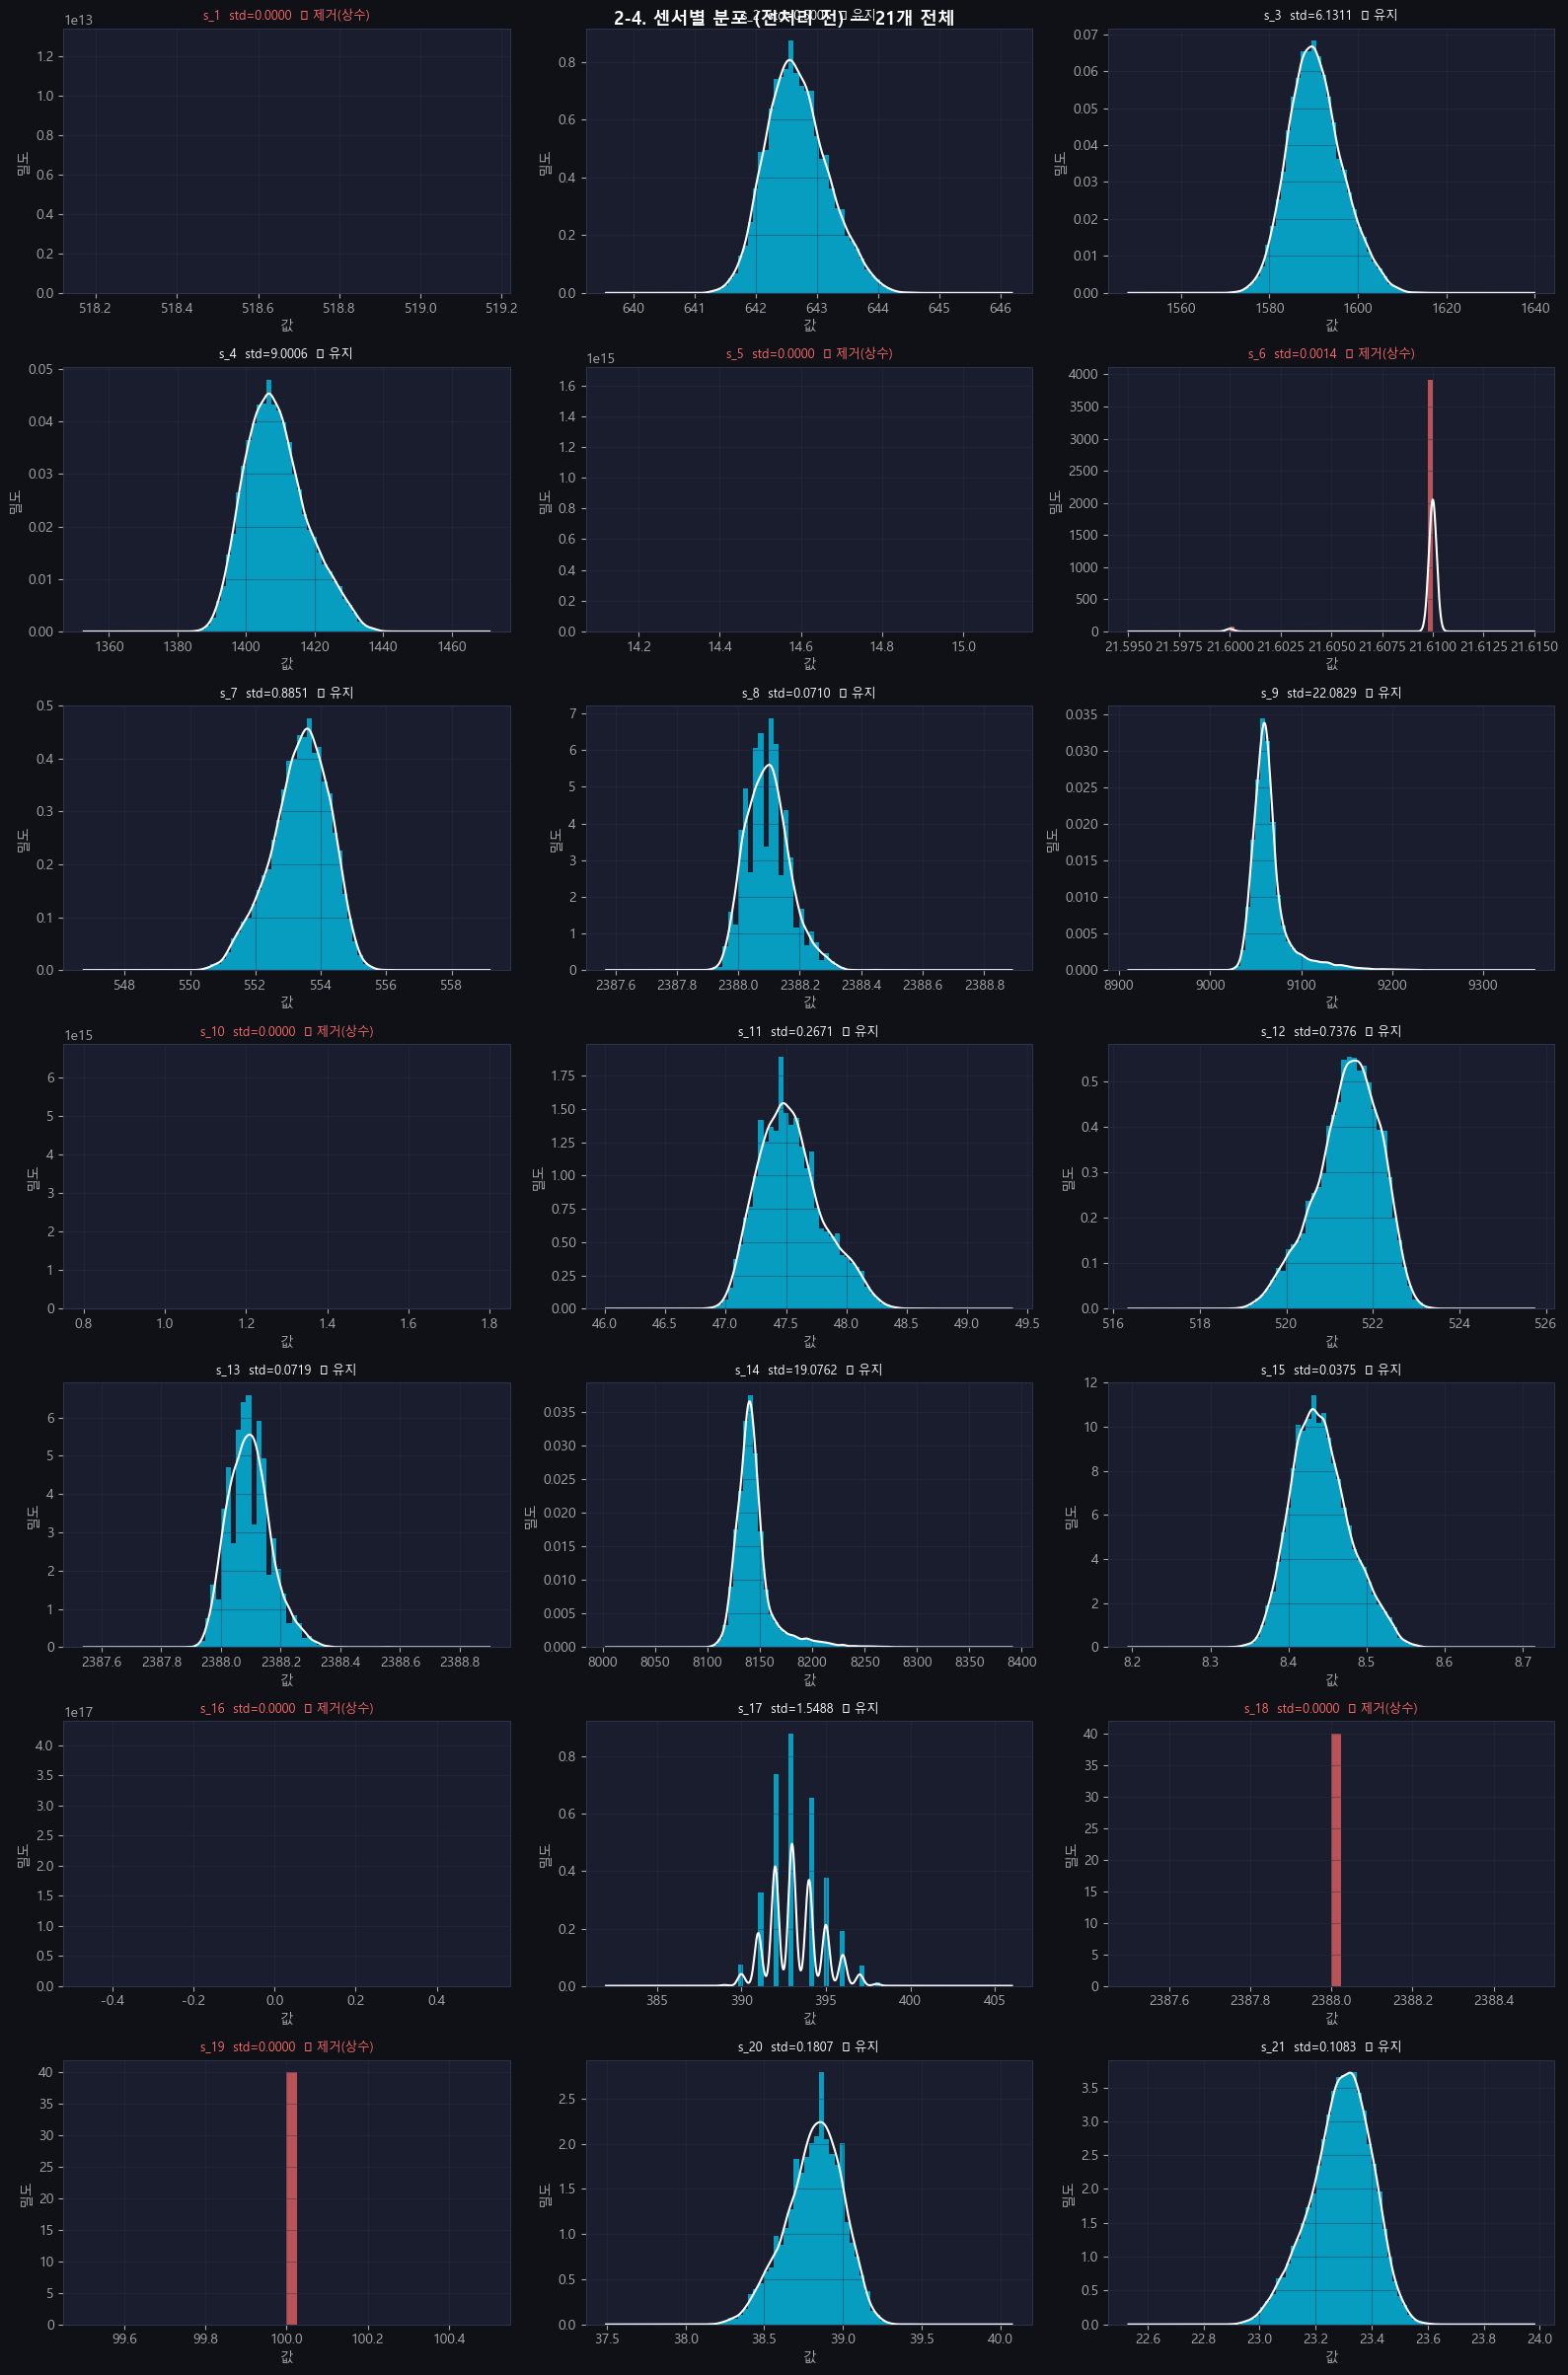

--- IQR 기준 이상치 탐지 ---


,센서,이상치 수,비율(%)
1,s_2,128,0.620
2,s_3,165,0.800
3,s_4,120,0.582
5,s_6,406,1.968
6,s_7,110,0.533
7,s_8,320,1.551
8,s_9,1686,8.172
10,s_11,167,0.809
11,s_12,146,0.708
12,s_13,161,0.780


In [8]:
n_cols, n_rows = 3, 7
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3.5))
fig.suptitle('2-4. 센서별 분포 (전처리 전) — 21개 전체', fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, SENSOR_COLS):
    data = train_raw[s].dropna()
    std_val = data.std()
    is_const = std_val < CONST_THR
    color = C[1] if is_const else C[0]
    ax.hist(data, bins=40, color=color, alpha=0.7, density=True, edgecolor='none')
    try: data.plot.kde(ax=ax, color='white', lw=1.5)
    except: pass
    label = '❌ 제거(상수)' if is_const else '✅ 유지'
    ax.set_title(f'{s}  std={std_val:.4f}  {label}', fontsize=9,
                 color=C[1] if is_const else WHITE)
    ax.set_xlabel('값'); ax.set_ylabel('밀도')

for ax in axes.flat[len(SENSOR_COLS):]: ax.set_visible(False)
plt.tight_layout(); plt.show()

print('--- IQR 기준 이상치 탐지 ---')
outlier_rows = []
for s in SENSOR_COLS:
    Q1, Q3 = train_raw[s].quantile(0.25), train_raw[s].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((train_raw[s] < Q1-1.5*IQR)|(train_raw[s] > Q3+1.5*IQR)).sum()
    outlier_rows.append({'센서':s,'이상치 수':n_out,'비율(%)':round(n_out/len(train_raw)*100,3)})
out_df = pd.DataFrame(outlier_rows)
nonzero = out_df[out_df['이상치 수']>0]
if len(nonzero): display(nonzero)
else: print('✅ IQR 기준 이상치 없음 (시뮬레이션 데이터 특성)')


### 📊 2-4. 센서별 분포 & 이상치 탐지 결과

---

- **빨간색 센서 (상수, 제거 대상):** s_1, s_5, s_6, s_10, s_16, s_18, s_19 → 막대가 한 점에만 집중 = 값이 전혀 변하지 않음
- **파란색 센서 (유용, 유지):** 나머지 14개 → 종 모양 분포 = 값이 다양하게 변함 = 열화 정보 포함 가능

> 💡 s_9, s_14 이상치 비율이 높은 이유: 고장 직전 급격히 낮아지는 값들이 IQR 기준으로 이상치로 잡힘 → **실제로는 열화 신호 → 제거하면 안됨** ✅  
> 💡 s_8은 다봉분포 형태 — 팬 속도가 운전 단계마다 달라지는 현상 → 주의깊게 봐야 할 센서


### 2-5. 센서 간 상관관계 히트맵 (전처리 전)

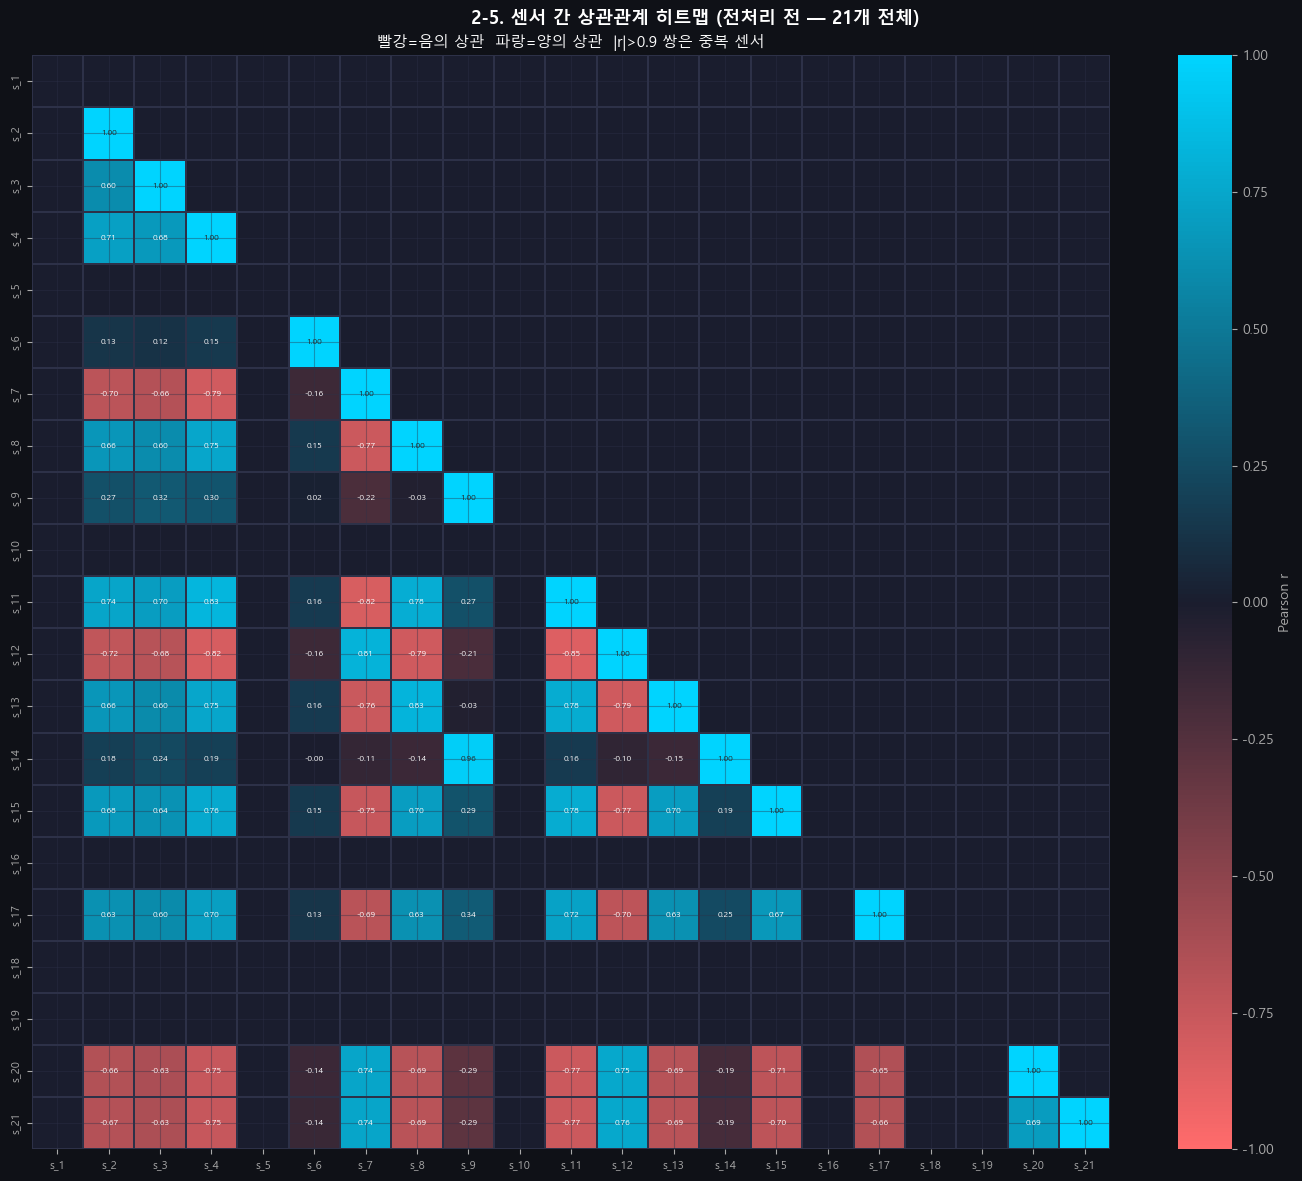

--- 고상관 센서 쌍 (|r| > 0.9) ---


,센서A,센서B,r
0,s_9,s_14,0.963


In [9]:
from matplotlib.colors import LinearSegmentedColormap

cmap_rg = LinearSegmentedColormap.from_list('rg',['#ff6b6b','#1a1d2e','#00d4ff'],N=256)

corr_before = train_raw[SENSOR_COLS].corr()

fig, ax = plt.subplots(figsize=(14, 12))
fig.suptitle('2-5. 센서 간 상관관계 히트맵 (전처리 전 — 21개 전체)', fontsize=13, fontweight='bold')

mask = np.triu(np.ones_like(corr_before, dtype=bool), k=1)
sns.heatmap(corr_before, ax=ax, mask=mask, cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size':6}, linewidths=0.3, linecolor=GRID,
            cbar_kws={'label':'Pearson r'})
ax.set_title('빨강=음의 상관  파랑=양의 상관  |r|>0.9 쌍은 중복 센서')
ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

pairs = []
for i in range(len(SENSOR_COLS)):
    for j in range(i+1, len(SENSOR_COLS)):
        r = corr_before.iloc[i,j]
        if abs(r) > 0.9:
            pairs.append({'센서A':SENSOR_COLS[i],'센서B':SENSOR_COLS[j],'r':round(r,3)})
print('--- 고상관 센서 쌍 (|r| > 0.9) ---')
if pairs: display(pd.DataFrame(pairs))
else: print('  해당 없음')


### 📊 2-5. 센서 간 상관관계 히트맵 결과

---

**고상관 센서 쌍: s_9 ↔ s_14 (r=0.963)**
- s_9 = Nc 코어 속도(rpm), s_14 = NRc 보정 코어속도(rpm) → 같은 물리 현상을 다른 방식으로 측정
- → 추후 피처 중요도 분석에서 재검토 예정

**상수 센서(s_1, s_5, s_10, s_16, s_18, s_19)**: 히트맵에서 색이 없는 구간 → 다른 센서와 상관관계 자체가 없음 = 제거 근거 재확인


### 2-6. 센서별 열화 트렌드 (전처리 전)

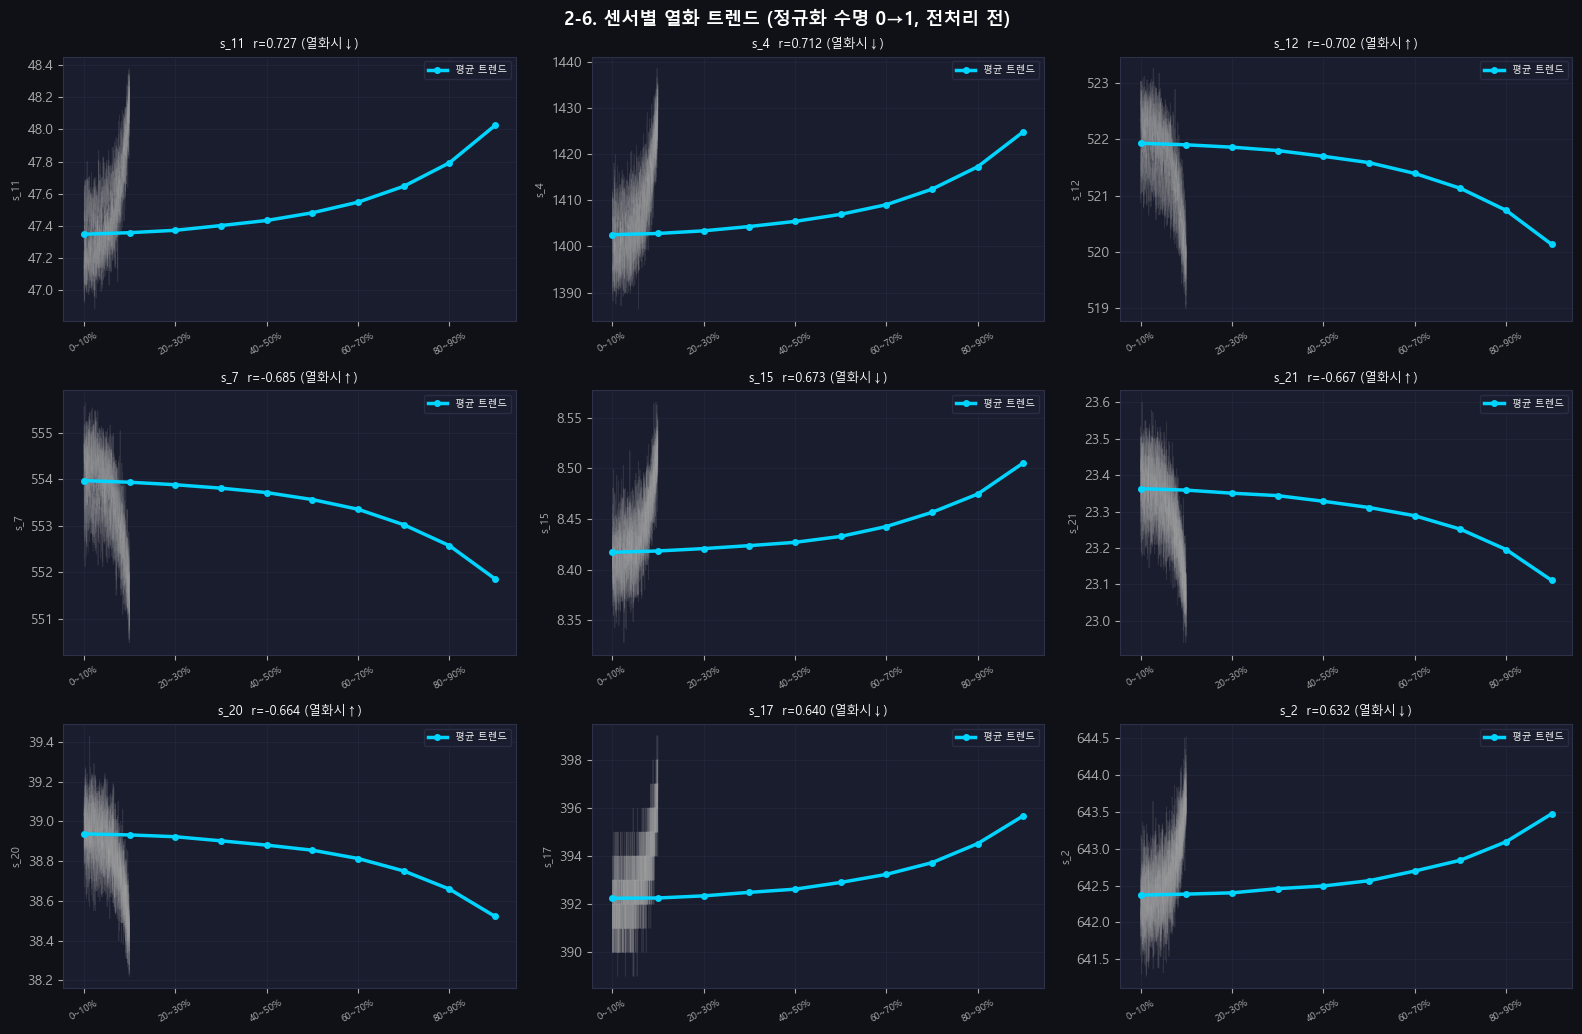

📌 r < 0: 엔진이 닳을수록 센서값 증가 (온도↑)  |  r > 0: 감소 (속도↓)


In [10]:
tr_trend = train_raw.copy()
mc = tr_trend.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_trend = tr_trend.join(mc, on='unit_nr')
tr_trend['norm_life'] = tr_trend['time_cycles']/tr_trend['max_c']

bins   = np.linspace(0, 1, 11)
labels = [f'{int(a*100)}~{int(b*100)}%' for a,b in zip(bins[:-1],bins[1:])]
tr_trend['life_bin'] = pd.cut(tr_trend['norm_life'], bins=bins, labels=labels)
trend_mean = tr_trend.groupby('life_bin', observed=True)[SENSOR_COLS].mean()

corr_with_life = tr_trend[SENSOR_COLS+['norm_life']].corr()['norm_life'][SENSOR_COLS]
trend_sensors  = corr_with_life[corr_with_life.abs()>0.1].sort_values(key=abs, ascending=False).index.tolist()
trend_sensors  = trend_sensors[:9]

n_cols = 3
n_rows = (len(trend_sensors)+n_cols-1)//n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3.5))
fig.suptitle('2-6. 센서별 열화 트렌드 (정규화 수명 0→1, 전처리 전)', fontsize=13, fontweight='bold')

x_pos = range(len(labels))
sample_units15 = tr_trend['unit_nr'].unique()[:15]
for ax, s in zip(axes.flat, trend_sensors):
    for u in sample_units15:
        sub = tr_trend[tr_trend['unit_nr']==u].sort_values('norm_life')
        ax.plot(sub['norm_life'], sub[s], color=GRAY, alpha=0.15, lw=0.6)
    ax.plot(x_pos, trend_mean[s].values, color=C[0], lw=2.5, marker='o', markersize=4, label='평균 트렌드')
    r = corr_with_life[s]
    direction = '열화시↑' if r<0 else '열화시↓'
    ax.set_title(f'{s}  r={r:.3f} ({direction})', fontsize=9)
    ax.set_xticks(x_pos[::2]); ax.set_xticklabels(labels[::2], rotation=30, fontsize=7)
    ax.set_ylabel(s, fontsize=8); ax.legend(fontsize=7)

for ax in axes.flat[len(trend_sensors):]: ax.set_visible(False)
plt.tight_layout(); plt.show()
print('📌 r < 0: 엔진이 닳을수록 센서값 증가 (온도↑)  |  r > 0: 감소 (속도↓)')


### 📊 2-6. 센서별 열화 트렌드 결과

---

**열화시 증가하는 센서 (r < 0):** s_12(-0.702), s_7(-0.685), s_20(-0.664) — 연료효율저하, 압축기 과부하, 냉각 필요 증가  
**열화시 감소하는 센서 (r > 0):** s_11(0.727), s_4(0.712), s_15(0.673) — 압력 손실 증가, 터빈 효율 저하  

> 후반 구간(80~100%)에서 평균 트렌드가 급격히 변화 → 이 구간의 패턴 학습이 RUL 예측의 핵심  
> Cap=125 설정 근거 재확인 — 초반 0~20% 구간은 센서값이 안정적


### 2-7. RUL 상관계수 (전처리 전)

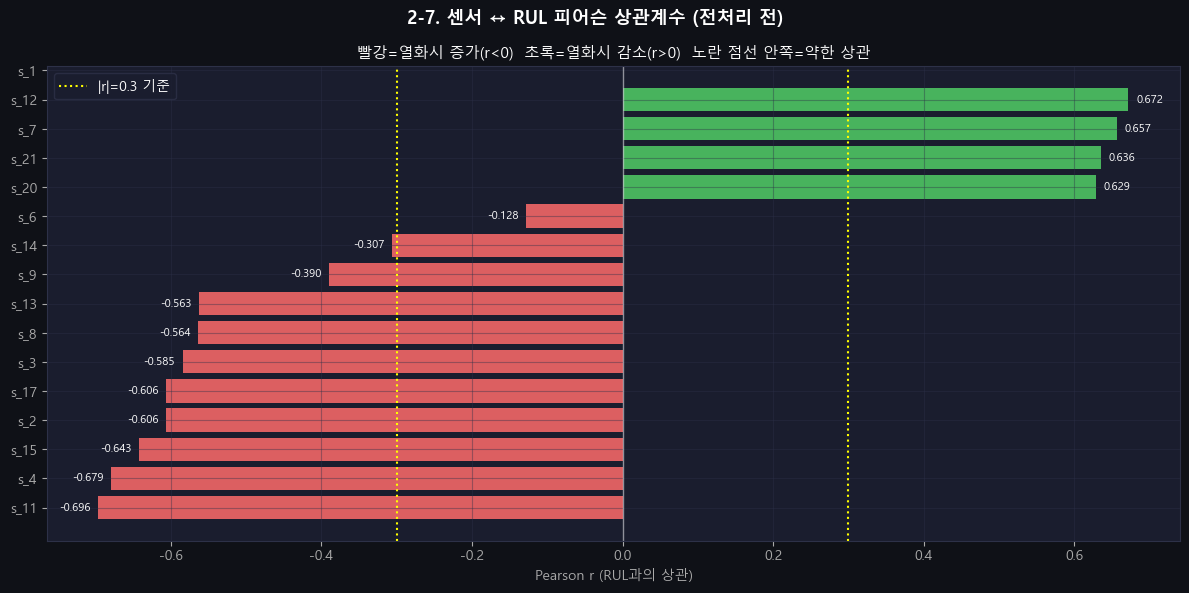

|r|>0.3 고상관 센서: 14개
  s_11: r=-0.696  Ps30 정적압력(psia)
  s_4: r=-0.679  T50 LPT 출구 온도(°R)
  s_12: r=0.672  phi 연료/Ps30 비율
  s_7: r=0.657  P30 HPC 출구 압력(psia)
  s_15: r=-0.643  BPR 바이패스 비율
  s_21: r=0.636  W32 LPT 냉각블리드
  s_20: r=0.629  W31 HPT 냉각블리드
  s_2: r=-0.606  T24 LPC 출구 온도(°R)
  s_17: r=-0.606  htBleed 블리드 엔탈피
  s_3: r=-0.585  T30 HPC 출구 온도(°R)
  s_8: r=-0.564  Nf 팬 속도(rpm)
  s_13: r=-0.563  NRf 보정 팬 속도(rpm)
  s_9: r=-0.390  Nc 코어 속도(rpm)
  s_14: r=-0.307  NRc 보정 코어속도(rpm)


In [11]:
tr_rul = train_raw.copy()
mc = tr_rul.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_rul = tr_rul.join(mc, on='unit_nr')
tr_rul['RUL'] = tr_rul['max_c'] - tr_rul['time_cycles']

rul_corr_before = tr_rul[SENSOR_COLS+['RUL']].corr()['RUL'][SENSOR_COLS].sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('2-7. 센서 ↔ RUL 피어슨 상관계수 (전처리 전)', fontsize=13, fontweight='bold')

bar_colors = [C[1] if v<0 else C[2] for v in rul_corr_before]
bars = ax.barh(rul_corr_before.index, rul_corr_before.values, color=bar_colors, alpha=0.85)
ax.axvline(0,    color='white', lw=1, alpha=0.5)
ax.axvline( 0.3, color='yellow', lw=1.5, ls=':', label='|r|=0.3 기준')
ax.axvline(-0.3, color='yellow', lw=1.5, ls=':')
ax.set_xlabel('Pearson r (RUL과의 상관)')
ax.set_title('빨강=열화시 증가(r<0)  초록=열화시 감소(r>0)  노란 점선 안쪽=약한 상관')
ax.legend()
for bar, val in zip(bars, rul_corr_before.values):
    ax.text(val+(0.01 if val>=0 else -0.01), bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=8)
plt.tight_layout(); plt.show()

high_corr = rul_corr_before[rul_corr_before.abs()>0.3]
print(f'|r|>0.3 고상관 센서: {len(high_corr)}개')
for s,r in high_corr.sort_values(key=abs,ascending=False).items():
    print(f'  {s}: r={r:.3f}  {SENSOR_DESC.get(s,"")[:30]}')


### 📊 2-7. RUL 상관계수 결과 (전처리 전)

---

- **상수 센서(s_1, s_5, s_10, s_16, s_18, s_19)**: r≈0 → 제거 근거 재확인 ✅
- **유용 센서 14개 전부 |r| > 0.3** → 모두 RUL과 유의미한 상관관계 → 14개 모두 모델 입력으로 사용 근거 ✅
- s_9(r=-0.390), s_14(r=-0.307): 다른 센서 대비 상대적으로 낮음 → 추후 피처 중요도 분석에서 재검토


---
## 3. 통계 검정

---

#### 검정 목적
EDA에서 시각적으로 확인한 패턴들을 **통계적으로 증명**하는 단계

| 검정 | 목적 |
|------|------|
| 3-1. 시차 상관관계 (Lag Correlation) | 몇 사이클 전 센서값이 RUL과 가장 연관있는지 확인 → 슬라이딩 윈도우 크기(30) 근거 |
| 3-2. Mann-Kendall 추세 검정 | 센서값의 열화 트렌드가 통계적으로 유의미한지 검정 |
| 3-3. 대응 표본 검정 | 수명 20% 전후 센서값 차이가 통계적으로 유의미한지 검정 |

> 💡 모든 검정의 유의수준: α = 0.05


### 3-1. 시차 상관관계 (Lag Correlation, lag 0~30)

> **해석:** lag=k에서의 상관계수는 '현재 센서값이 k사이클 뒤의 RUL과 얼마나 관련되는가'를 의미.  
> 절댓값이 클수록, 최적 lag가 클수록 해당 센서가 **조기 경보(early warning) 능력**이 높음.

=== 3-1. 시차 상관관계 (Lag Correlation, lag 0~30) ===


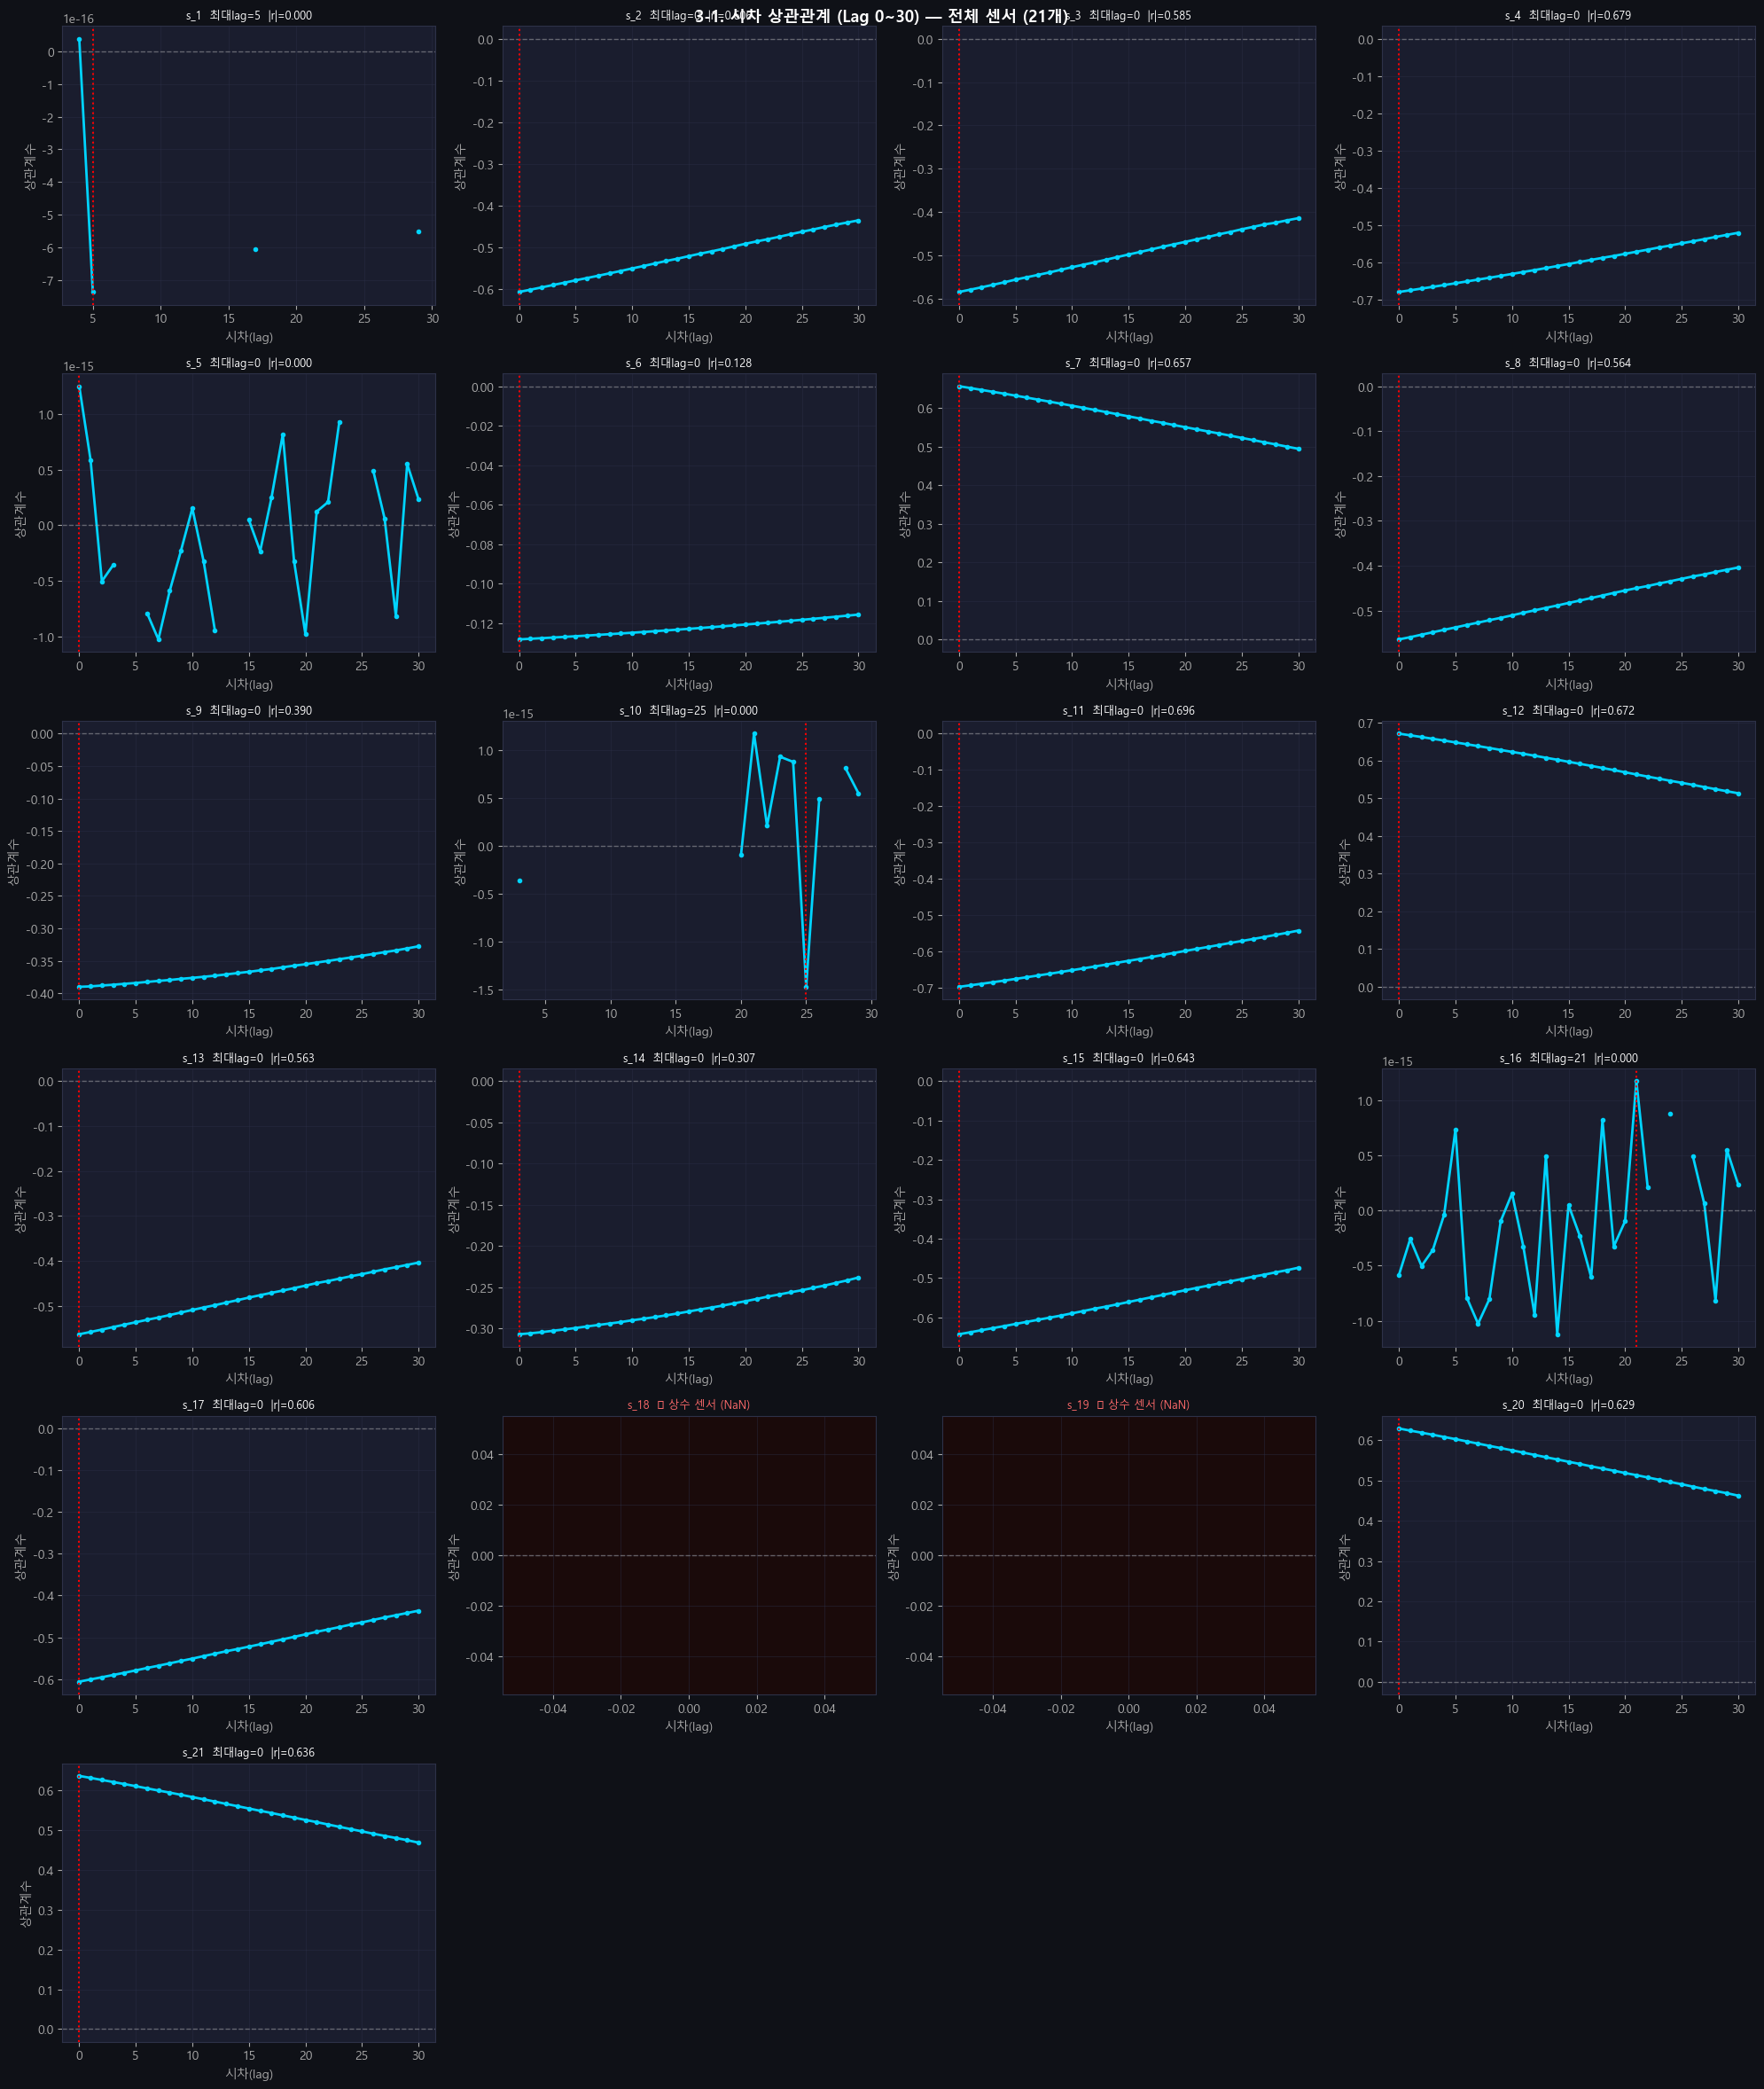


=== 센서별 최적 시차 요약 ===
  s_1: lag=5사이클에서 최대 상관 (r=-0.000)
  s_2: lag=0사이클에서 최대 상관 (r=-0.606)
  s_3: lag=0사이클에서 최대 상관 (r=-0.585)
  s_4: lag=0사이클에서 최대 상관 (r=-0.679)
  s_5: lag=0사이클에서 최대 상관 (r=0.000)
  s_6: lag=0사이클에서 최대 상관 (r=-0.128)
  s_7: lag=0사이클에서 최대 상관 (r=0.657)
  s_8: lag=0사이클에서 최대 상관 (r=-0.564)
  s_9: lag=0사이클에서 최대 상관 (r=-0.390)
  s_10: lag=25사이클에서 최대 상관 (r=-0.000)
  s_11: lag=0사이클에서 최대 상관 (r=-0.696)
  s_12: lag=0사이클에서 최대 상관 (r=0.672)
  s_13: lag=0사이클에서 최대 상관 (r=-0.563)
  s_14: lag=0사이클에서 최대 상관 (r=-0.307)
  s_15: lag=0사이클에서 최대 상관 (r=-0.643)
  s_16: lag=21사이클에서 최대 상관 (r=0.000)
  s_17: lag=0사이클에서 최대 상관 (r=-0.606)
  s_18: ❌ 상수 센서 — 상관관계 계산 불가 (NaN)
  s_19: ❌ 상수 센서 — 상관관계 계산 불가 (NaN)
  s_20: lag=0사이클에서 최대 상관 (r=0.629)
  s_21: lag=0사이클에서 최대 상관 (r=0.636)


In [12]:
print('=== 3-1. 시차 상관관계 (Lag Correlation, lag 0~30) ===')

all_sensors = [f's_{i}' for i in range(1, 22)]
tr_lag = train_raw.copy()
mc = tr_lag.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_lag = tr_lag.join(mc, on='unit_nr')
tr_lag['RUL'] = tr_lag['max_c'] - tr_lag['time_cycles']

max_lag = 30
lag_results = {}
for s in all_sensors:
    lag_corrs = []
    for lag in range(0, max_lag + 1):
        shifted = tr_lag.groupby('unit_nr')[s].shift(lag)
        valid = ~shifted.isna()
        r = tr_lag.loc[valid, 'RUL'].corr(shifted[valid])
        lag_corrs.append(r)
    lag_results[s] = lag_corrs

n_cols = 4
n_rows = (len(all_sensors) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
fig.suptitle('3-1. 시차 상관관계 (Lag 0~30) — 전체 센서 (21개)', fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, all_sensors):
    lag_corrs = lag_results[s]
    arr = np.abs(lag_corrs)

    # 상수 센서(전부 NaN) 처리 ─ nanargmax 호출 전 유효값 존재 여부 확인
    if np.all(np.isnan(arr)):
        best_lag, best_r = 0, float('nan')
        ax.set_facecolor('#1a0a0a')   # 상수 센서는 배경 강조
    else:
        best_lag = int(np.nanargmax(arr))
        best_r   = lag_corrs[best_lag]

    ax.plot(range(max_lag + 1), lag_corrs, color=C[0], lw=2, marker='o', markersize=3)
    ax.axhline(0, color=GRAY, ls='--', lw=1, alpha=0.5)
    if np.isfinite(best_r):
        ax.axvline(best_lag, color='red', ls=':', lw=1.5)
        ax.set_title(f'{s}  최대lag={best_lag}  |r|={abs(best_r):.3f}', fontsize=9)
    else:
        ax.set_title(f'{s}  ❌ 상수 센서 (NaN)', fontsize=9, color=C[1])
    ax.set_xlabel('시차(lag)'); ax.set_ylabel('상관계수')

for ax in axes.flat[len(all_sensors):]: ax.set_visible(False)
plt.tight_layout(); plt.show()

print('\n=== 센서별 최적 시차 요약 ===')
for s in all_sensors:
    arr = np.abs(lag_results[s])
    if np.all(np.isnan(arr)):
        print(f'  {s}: ❌ 상수 센서 — 상관관계 계산 불가 (NaN)')
    else:
        best_lag = int(np.nanargmax(arr))
        best_r   = lag_results[s][best_lag]
        print(f'  {s}: lag={best_lag}사이클에서 최대 상관 (r={best_r:.3f})')


=== 3-1b. 시차상관관계 히트맵 (100개 엔진 평균, lag 0~15) ===


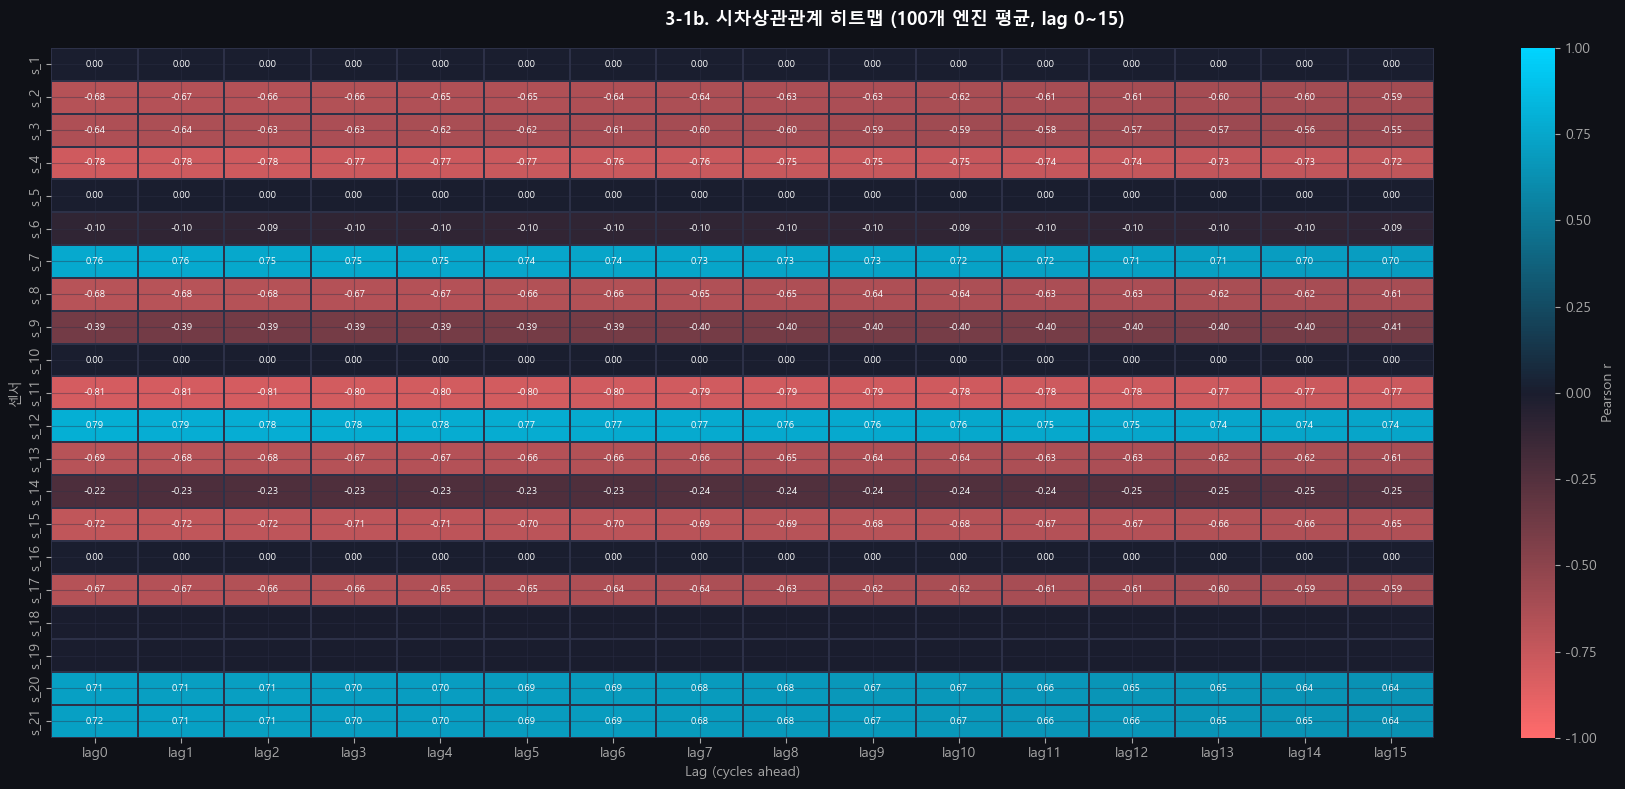

In [13]:
# 시차 상관관계 히트맵 (Optuna 방식 — 엔진별 평균)
print('=== 3-1b. 시차상관관계 히트맵 (100개 엔진 평균, lag 0~15) ===')

MAX_LAG = 15
LAGS    = list(range(0, MAX_LAG + 1))
lag_matrix = np.full((len(SENSOR_COLS), len(LAGS)), np.nan)

for si, s in enumerate(SENSOR_COLS):
    unit_lag_corrs = {lag: [] for lag in LAGS}
    for uid in tr_rul['unit_nr'].unique():
        udf    = tr_rul[tr_rul['unit_nr'] == uid].sort_values('time_cycles')
        sensor = udf[s].values
        rul    = udf['RUL'].values
        for lag in LAGS:
            if len(sensor) > lag + 5:
                c = np.corrcoef(sensor[:len(sensor) - lag], rul[lag:])[0, 1]
                if np.isfinite(c):
                    unit_lag_corrs[lag].append(c)
    lag_matrix[si] = [
        np.mean(unit_lag_corrs[l]) if unit_lag_corrs[l] else np.nan
        for l in LAGS
    ]

lag_df = pd.DataFrame(lag_matrix, index=SENSOR_COLS,
                       columns=[f'lag{l}' for l in LAGS])

cmap_lag = LinearSegmentedColormap.from_list('lag', ['#ff6b6b', '#1a1d2e', '#00d4ff'], N=256)
fig, ax = plt.subplots(figsize=(18, 8))
fig.suptitle('3-1b. 시차상관관계 히트맵 (100개 엔진 평균, lag 0~15)', fontsize=13, fontweight='bold')
sns.heatmap(lag_df, ax=ax, cmap=cmap_lag, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.3, linecolor=GRID, cbar_kws={'label': 'Pearson r'})
ax.set_xlabel('Lag (cycles ahead)'); ax.set_ylabel('센서')
plt.tight_layout(); plt.show()


### 3-1. 시차 상관관계 결과

---

- **유의미한 센서에서 모두 lag=0에서 최대 상관** — 과거 값보다 현재 값이 RUL을 가장 잘 설명
- **lag=30까지도 상관관계가 유지됨** → 과거 30사이클치 데이터가 여전히 유효한 정보를 담고 있음  
  → **슬라이딩 윈도우 크기 30 설정의 근거** ✅
- **상수 센서 6개 자연 탈락** — r=NaN → 값이 변하지 않아 상관관계 계산 자체 불가 → 상수 센서 제거 근거 통계적으로 재확인


---

## 3-2. Mann-Kendall 추세 검정

---

### 검정 목적

센서값이 시간에 따라 단조롭게 증가 또는 감소하는 추세가 통계적으로 유의미한지 검정

> 엔진 1개가 아닌 **FD001 전체 100개 엔진**을 대상으로 검정하여 결과의 신뢰도를 높임

---

### 가설

- **H₀**: 센서값에 단조 추세가 없다 (랜덤하게 변한다)
- **H₁**: 센서값에 유의미한 단조 추세가 있다 (열화 신호 존재)

> 100개 엔진 각각에 대해 검정 후, **90% 이상(90개 이상)의 엔진에서 유의미한 추세**가 확인된 센서를 열화 신호 센서로 판정


=== 3-2. Mann-Kendall 추세 검정 (전체 100개 엔진) ===
τ > 0 → 상승 트렌드  |  τ < 0 → 하강 트렌드  |  p < 0.05 → 유의



,유효 엔진 수,추세 있는 엔진 수,비율(%),평균 τ,추세 방향,판정
센서,,,,,,
s_2,100,100,100.0,0.4826,증가↑,추세 있음✅
s_3,100,100,100.0,0.4527,증가↑,추세 있음✅
s_4,100,100,100.0,0.5889,증가↑,추세 있음✅
s_7,100,100,100.0,-0.5695,감소↓,추세 있음✅
s_17,100,100,100.0,0.5220,증가↑,추세 있음✅
s_12,100,100,100.0,-0.6033,감소↓,추세 있음✅
s_11,100,100,100.0,0.6336,증가↑,추세 있음✅
s_20,100,100,100.0,-0.5228,감소↓,추세 있음✅
s_21,100,100,100.0,-0.5183,감소↓,추세 있음✅


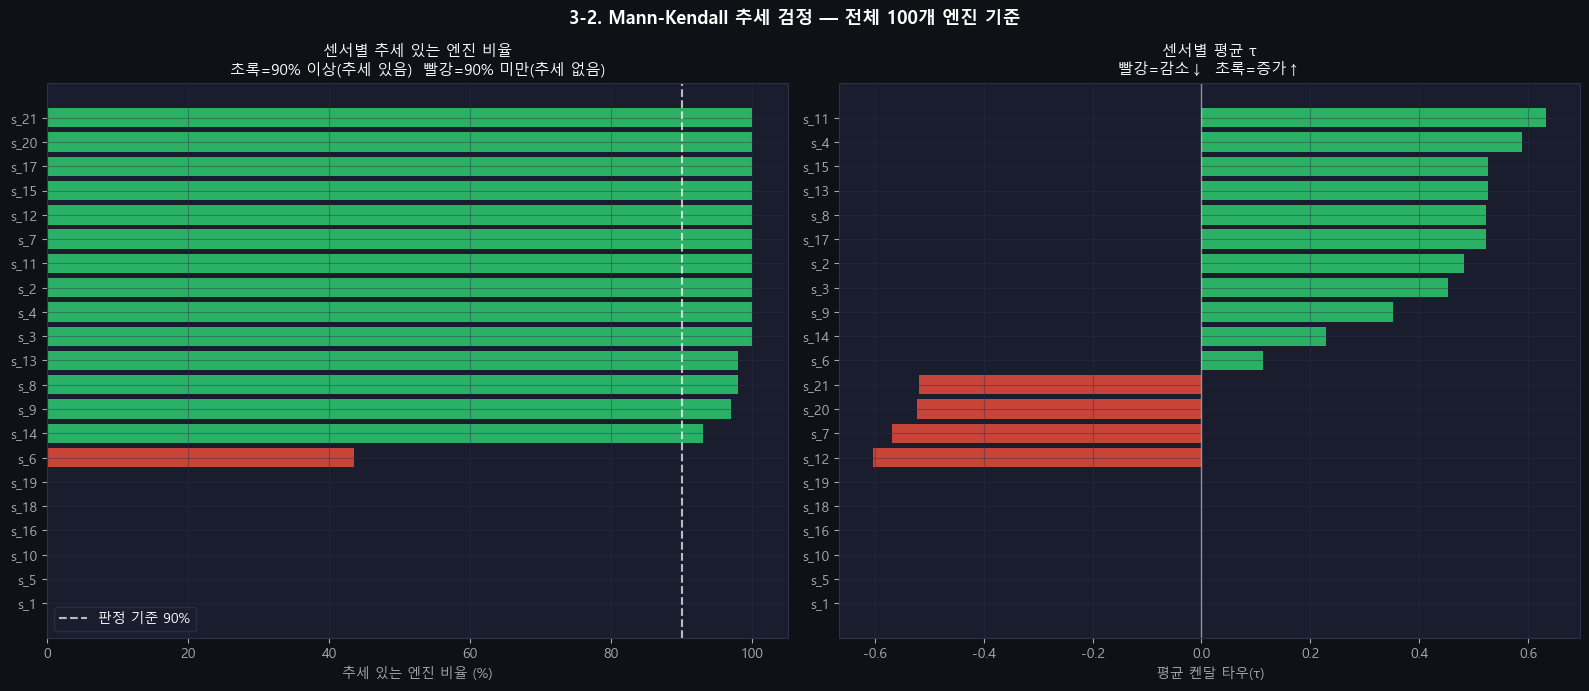

In [14]:
print('=== 3-2. Mann-Kendall 추세 검정 (전체 100개 엔진) ===')
print('τ > 0 → 상승 트렌드  |  τ < 0 → 하강 트렌드  |  p < 0.05 → 유의')
print()

all_units_mk = train_raw['unit_nr'].unique()
results_mk = {s: [] for s in all_sensors}

for unit in all_units_mk:
    unit_df = train_raw[train_raw['unit_nr'] == unit].sort_values('time_cycles')
    for s in all_sensors:
        arr = unit_df[s].values
        time_idx = np.arange(len(arr))
        tau, p_val = kendalltau(time_idx, arr)
        if np.isfinite(tau):
            results_mk[s].append({'tau': tau, 'p_val': p_val})

mk_rows = []
for s in all_sensors:
    taus = [r['tau'] for r in results_mk[s]]
    p_vals = [r['p_val'] for r in results_mk[s]]
    n_valid = len(results_mk[s])
    n_significant = sum(p < 0.05 for p in p_vals)
    sig_ratio = n_significant / n_valid if n_valid > 0 else np.nan
    mk_rows.append({
        '센서': s, '유효 엔진 수': n_valid,
        '추세 있는 엔진 수': n_significant,
        '비율(%)': round(sig_ratio * 100, 1) if np.isfinite(sig_ratio) else np.nan,
        '평균 τ': round(np.mean(taus), 4) if taus else np.nan,
        '추세 방향': '증가↑' if np.mean(taus) > 0 else '감소↓' if taus else '-',
        '판정': '추세 있음✅' if np.isfinite(sig_ratio) and sig_ratio >= 0.9 else '추세 없음⚠️'
    })

mk_df = pd.DataFrame(mk_rows).set_index('센서')
display(mk_df.sort_values('비율(%)', ascending=False, na_position='last'))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('3-2. Mann-Kendall 추세 검정 — 전체 100개 엔진 기준', fontsize=13, fontweight='bold')

mk_sorted = mk_df.sort_values('비율(%)', ascending=True, na_position='first')
ratio_vals = mk_sorted['비율(%)'].fillna(0).values
colors_ratio = ['#e74c3c' if (pd.isna(v) or v < 90) else '#2ecc71' for v in mk_sorted['비율(%)']]
axes[0].barh(mk_sorted.index, ratio_vals, color=colors_ratio, alpha=0.85)
axes[0].axvline(90, color='white', lw=1.5, linestyle='--', alpha=0.7, label='판정 기준 90%')
axes[0].set_xlabel('추세 있는 엔진 비율 (%)')
axes[0].set_title('센서별 추세 있는 엔진 비율\n초록=90% 이상(추세 있음)  빨강=90% 미만(추세 없음)')
axes[0].legend()

mk_sorted2 = mk_df.sort_values('평균 τ', ascending=True, na_position='first')
tau_vals = mk_sorted2['평균 τ'].fillna(0).values
colors_tau = ['#e74c3c' if (pd.isna(v) or v < 0) else '#2ecc71' for v in mk_sorted2['평균 τ']]
axes[1].barh(mk_sorted2.index, tau_vals, color=colors_tau, alpha=0.85)
axes[1].axvline(0, color='white', lw=1, alpha=0.5)
axes[1].set_xlabel('평균 켄달 타우(τ)')
axes[1].set_title('센서별 평균 τ\n빨강=감소↓  초록=증가↑')
plt.tight_layout(); plt.show()


### 검정 결과 해석 — Mann-Kendall

---

#### 전체 요약
- 결과: **14/21개 센서에서 유의미한 추세 확인**
- 100% 그룹 10개 센서: 단 한 개의 예외 엔진도 없이 전체에서 추세 확인
- 추세 없는 7개 센서(s_1, s_5, s_6, s_10, s_16, s_18, s_19): **상수 센서 제거 결과(7개 제거)와 완전히 일치** → 전처리 근거 통계적으로 검증 완료 ✅

#### 추세 방향 해석
- **증가 센서 (τ > 0):** s_2, s_3, s_4, s_8, s_9, s_11, s_13, s_14, s_15, s_17 → 열화될수록 값 상승
- **감소 센서 (τ < 0):** s_7, s_12, s_20, s_21 → 열화될수록 값 하락 (s_12 τ=-0.603, s_7 τ=-0.570 으로 추세 강도 가장 강함)


---

### 3-3. 대응 표본 검정 (Paired t-test / Wilcoxon)

---

#### 검정 목적
수명 80% 이전(초기 구간)과 마지막 20%(열화 구간)의 센서 평균이 통계적으로 유의미하게 다른지 검정

#### 가설
- **H₀**: 정상구간(RUL 상위 80%)과 열화구간(RUL 하위 20%)의 센서 평균에 차이가 없다
- **H₁**: 열화구간(RUL 하위 20%)에서 센서 평균이 유의미하게 달라진다

> 검정 방법: Shapiro-Wilk 정규성 검정 후 → 정규 시 Paired t-test / 비정규 시 Wilcoxon 자동 선택


=== 3-3. 대응 표본 검정 ===
목적: 잔여 수명 20% 전후 센서값 차이가 통계적으로 유의미한지 검정



,정상구간 평균,열화구간 평균,평균 차이(Δ),검정 방법,p-value,변화 방향,판정
센서,,,,,,,
s_1,518.6700,518.6700,0.0000,Wilcoxon,0.0000,감소↓,차이 있음✅
s_2,642.5383,643.2919,-0.7536,Paired t-test,0.0000,증가↑,차이 있음✅
s_3,1588.7911,1597.7837,-8.9926,Paired t-test,0.0000,증가↑,차이 있음✅
s_4,1406.0480,1421.1627,-15.1147,Wilcoxon,0.0000,증가↑,차이 있음✅
s_5,14.6200,14.6200,0.0000,Wilcoxon,0.6661,감소↓,차이 없음⚠️
s_6,21.6098,21.6100,-0.0002,Wilcoxon,0.0000,증가↑,차이 있음✅
s_7,553.6394,552.2015,1.4379,Wilcoxon,0.0000,감소↓,차이 있음✅
s_8,2388.0789,2388.1776,-0.0988,Wilcoxon,0.0000,증가↑,차이 있음✅
s_9,9059.9224,9083.8422,-23.9198,Wilcoxon,0.0000,증가↑,차이 있음✅


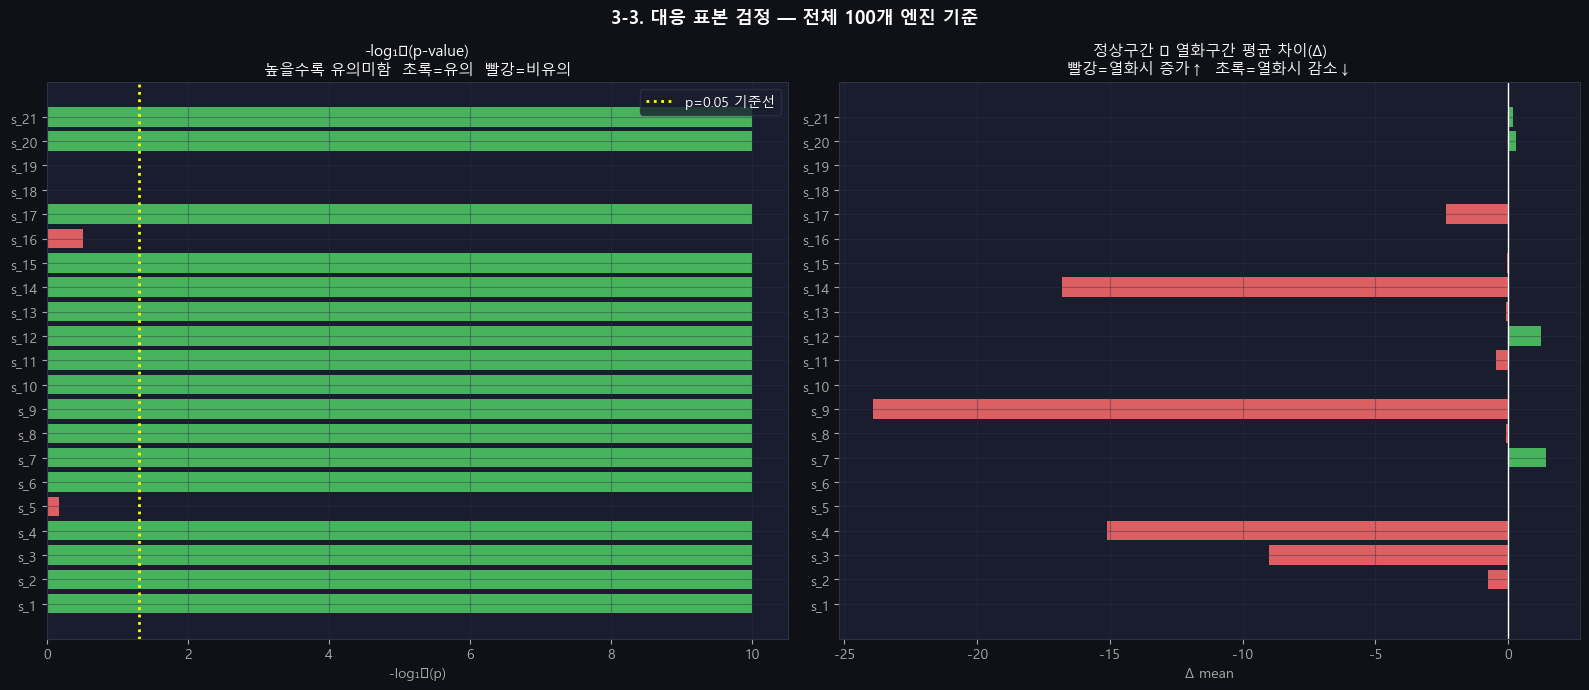


유의한 센서 수: 17 / 21개
사용된 검정: {'Wilcoxon': 15, 'Paired t-test': 6}


In [15]:
print('=== 3-3. 대응 표본 검정 ===')
print('목적: 잔여 수명 20% 전후 센서값 차이가 통계적으로 유의미한지 검정')
print()

tr_paired = train_raw.copy()
mc = tr_paired.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_paired = tr_paired.join(mc, on='unit_nr')
tr_paired['RUL'] = tr_paired['max_c'] - tr_paired['time_cycles']

ttest_rows = []
for s in all_sensors:
    before_means, after_means = [], []
    for unit in train_raw['unit_nr'].unique():
        sub = tr_paired[tr_paired['unit_nr'] == unit].sort_values('time_cycles')
        threshold = sub['RUL'].quantile(0.20)
        before = sub[sub['RUL'] >  threshold][s].mean()
        after  = sub[sub['RUL'] <= threshold][s].mean()
        if np.isfinite(before) and np.isfinite(after):
            before_means.append(before)
            after_means.append(after)

    diffs = np.array(before_means) - np.array(after_means)
    _, p_sw = shapiro(diffs) if len(diffs) >= 3 else (np.nan, 0.0)
    if p_sw > 0.05:
        stat, p_val = ttest_rel(before_means, after_means); test_name = 'Paired t-test'
    else:
        stat, p_val = wilcoxon(diffs); test_name = 'Wilcoxon'

    ttest_rows.append({
        '센서': s,
        '정상구간 평균': round(np.mean(before_means), 4),
        '열화구간 평균': round(np.mean(after_means),  4),
        '평균 차이(Δ)': round(float(np.mean(diffs)), 4),
        '검정 방법': test_name,
        'p-value': round(p_val, 4) if np.isfinite(p_val) else np.nan,
        '변화 방향': '증가↑' if np.mean(diffs) < 0 else '감소↓',
        '판정': '차이 있음✅' if (np.isfinite(p_val) and p_val < 0.05) else '차이 없음⚠️'
    })

ttest_df = pd.DataFrame(ttest_rows).set_index('센서')
display(ttest_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('3-3. 대응 표본 검정 — 전체 100개 엔진 기준', fontsize=13, fontweight='bold')

p_vals_tt = ttest_df['p-value'].values
log_p = -np.log10(np.clip(np.nan_to_num(p_vals_tt, nan=1.0), 1e-10, 1))
bc_p = [C[1] if (np.isnan(p) or p >= 0.05) else C[2] for p in p_vals_tt]
axes[0].barh(ttest_df.index, log_p, color=bc_p, alpha=0.85)
axes[0].axvline(-np.log10(0.05), color='yellow', lw=2, ls=':', label='p=0.05 기준선')
axes[0].set_title('-log₁₀(p-value)\n높을수록 유의미함  초록=유의  빨강=비유의')
axes[0].set_xlabel('-log₁₀(p)'); axes[0].legend()

diff_vals = ttest_df['평균 차이(Δ)'].values
bc_d = [C[1] if v < 0 else C[2] for v in diff_vals]
axes[1].barh(ttest_df.index, diff_vals, color=bc_d, alpha=0.85)
axes[1].axvline(0, color='white', lw=1)
axes[1].set_title('정상구간 − 열화구간 평균 차이(Δ)\n빨강=열화시 증가↑  초록=열화시 감소↓')
axes[1].set_xlabel('Δ mean')
plt.tight_layout(); plt.show()

print(f"\n유의한 센서 수: {(ttest_df['판정'] == '차이 있음✅').sum()} / {len(ttest_df)}개")
print(f"사용된 검정: {ttest_df['검정 방법'].value_counts().to_dict()}")


### 검정 결과 해석 — 대응 표본 검정

---

- 결과: **17/21개 센서에서 열화구간에서 유의미한 변화 확인**
- 차이 없는 센서 4개 (s_5, s_16, s_18, s_19): 정상구간과 열화구간 모두 완전히 동일한 값 → 상수 센서임을 재확인
- 검정 방법: Wilcoxon 15개 / Paired t-test 6개 → 데이터 분포에 맞는 검정 자동 선택

> **결론:** 21개 센서 중 17개가 열화구간(마지막 20%)에서 통계적으로 유의미한 변화를 보임 → 상수 센서 제거 결과와 일치 ✅


---
### 로그 변환 미적용 근거

- s_9, s_14 로그 변환 실험 결과: 변환 전후 분포 형태가 거의 동일 — 수치만 작아지고 실질적 효과 없음
- → 1차 공통 전처리에서 제외, 추후 모델 성능 실험 단계에서 재검토 예정

### 주의사항
- 모든 기준은 **Train 데이터**로만 계산 — Test는 Train 기준을 그대로 적용
- 상수 센서 제거 목록, scaler 전부 Train 기준 (데이터 누수 방지)


---
## 4. 결정 1 — 상수 센서 제거 (21개 → 14개)

**근거:** 비행 내내 값이 거의 변하지 않는 센서는 열화 정보를 담지 못함. 기준: `std < 0.01`  
> ⚠️ 기준은 **train**에서만 계산 → **동일 피처 목록**을 test에 적용 (누수 방지)


제거 (7개): ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
유지 (14개): ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


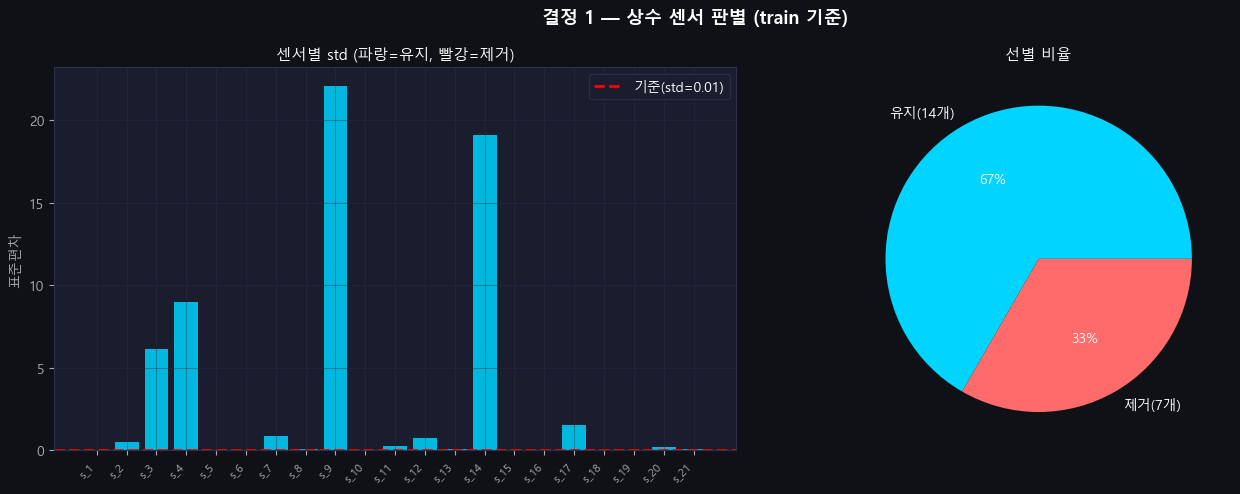


✅ 결정 1 완료: 26 → 19 컬럼


In [16]:
train_std      = train_raw[SENSOR_COLS].std()
USEFUL_SENSORS = train_std[train_std >= CONST_THR].index.tolist()
CONST_SENSORS  = train_std[train_std <  CONST_THR].index.tolist()

print(f'제거 ({len(CONST_SENSORS)}개): {CONST_SENSORS}')
print(f'유지 ({len(USEFUL_SENSORS)}개): {USEFUL_SENSORS}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('결정 1 — 상수 센서 판별 (train 기준)', fontsize=13, fontweight='bold')

ax = axes[0]
colors_bar = [C[0] if s in USEFUL_SENSORS else C[1] for s in SENSOR_COLS]
ax.bar(range(len(SENSOR_COLS)), train_std.values, color=colors_bar, alpha=0.85)
ax.axhline(CONST_THR, color='red', ls='--', lw=2, label=f'기준(std={CONST_THR})')
ax.set_xticks(range(len(SENSOR_COLS)))
ax.set_xticklabels(SENSOR_COLS, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('표준편차'); ax.set_title('센서별 std (파랑=유지, 빨강=제거)'); ax.legend()

ax = axes[1]
ax.pie([len(USEFUL_SENSORS), len(CONST_SENSORS)],
       labels=[f'유지({len(USEFUL_SENSORS)}개)', f'제거({len(CONST_SENSORS)}개)'],
       colors=[C[0], C[1]], autopct='%1.0f%%', textprops={'color':WHITE})
ax.set_title('선별 비율')
plt.tight_layout(); plt.show()

KEEP = ID_COLS + OP_COLS + USEFUL_SENSORS
train_s1 = train_raw[KEEP].copy()
test_s1  = test_raw[KEEP].copy()
print(f'\n✅ 결정 1 완료: {train_raw.shape[1]} → {train_s1.shape[1]} 컬럼')


## 5. 결정 2 — Piecewise RUL 생성 (Cap = 125)

**근거:** 100% 엔진이 수명 125 초과. 마지막 125 사이클(위험 구간)에만 모델이 집중하도록 함.  
> **train 전용** — test의 RUL은 `RUL_FD001.txt`에서 직접 가져옴  
> RUL_raw 컬럼은 시각화 용도로만 사용 — 모델 입력 시에는 RUL(cap 적용) 컬럼만 사용


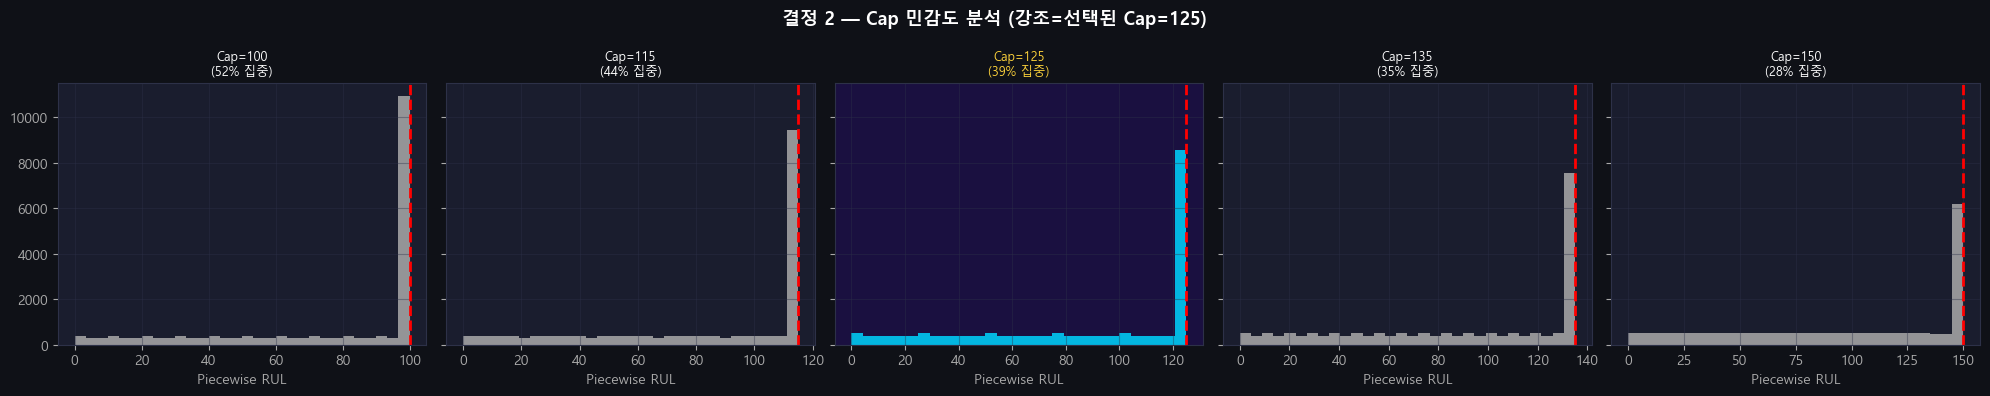

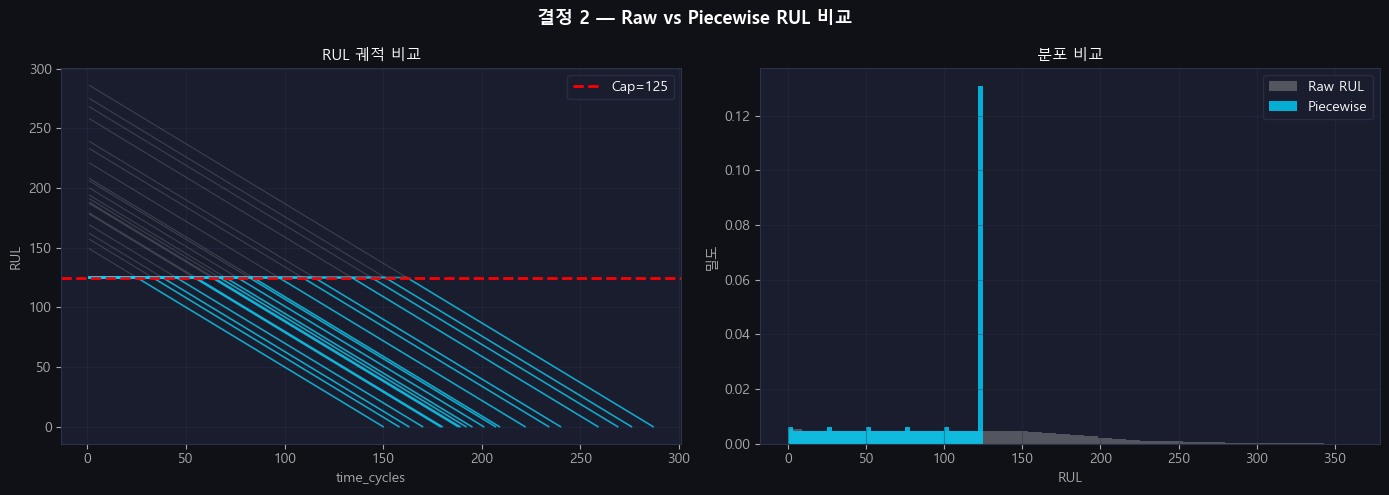

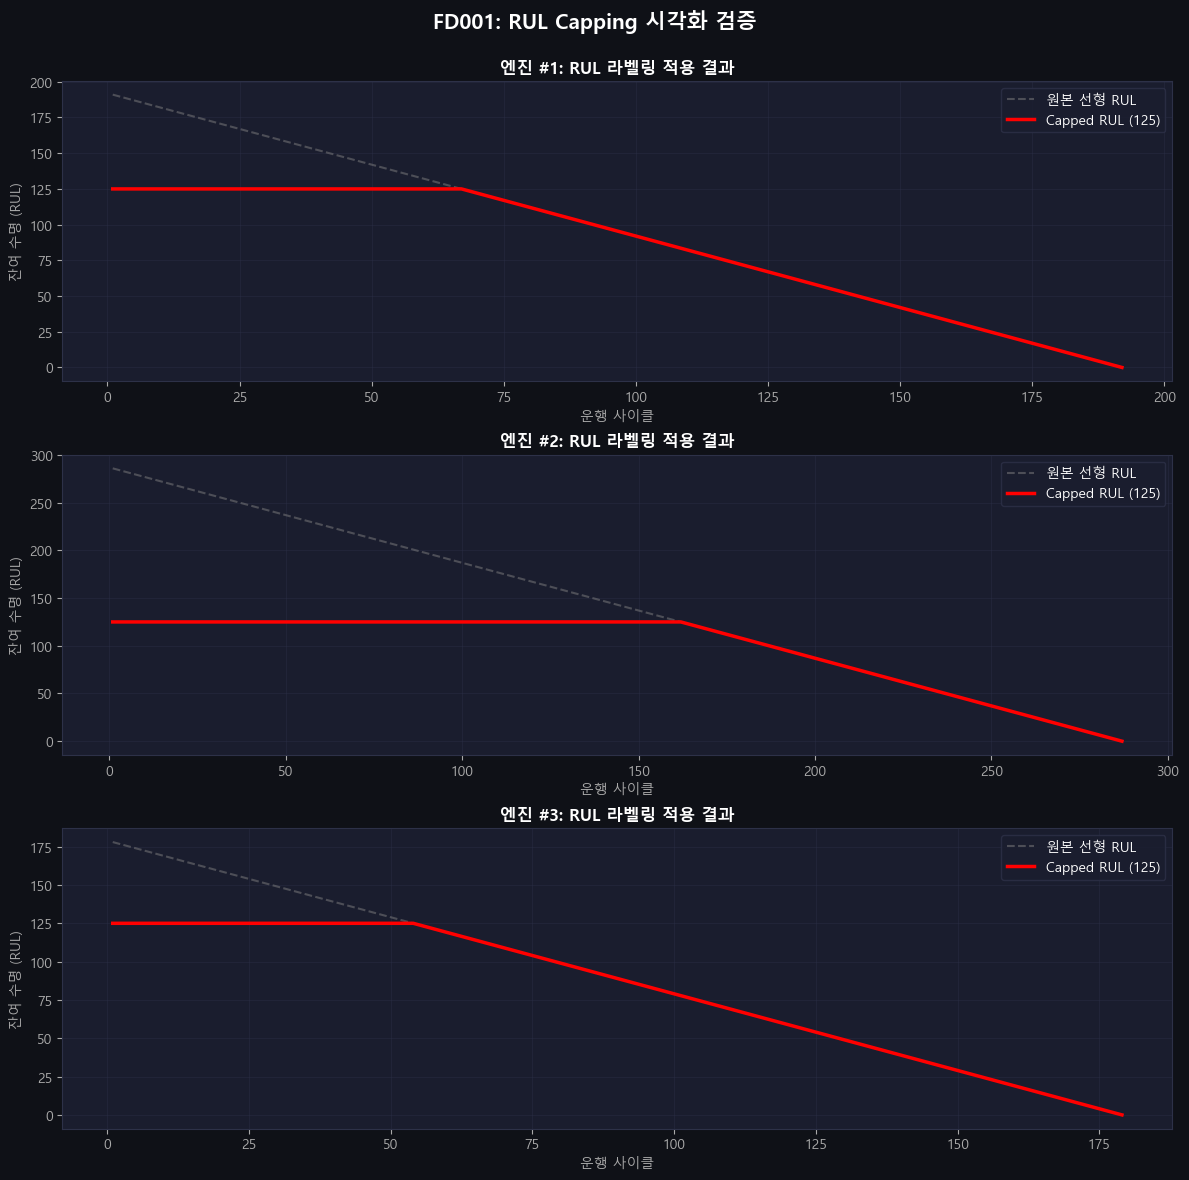

✅ 결정 2 완료  |  RUL std: 68.9 → 41.7 (39% 감소)


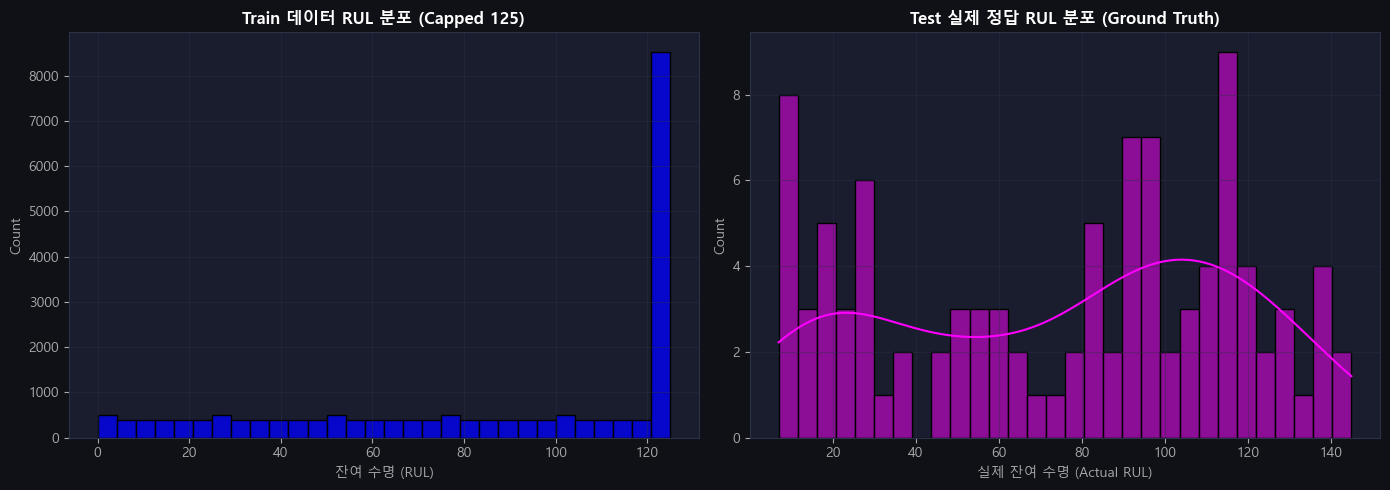

In [17]:
def add_piecewise_rul(df, cap=RUL_CAP):
    df = df.copy()
    mc = df.groupby('unit_nr')['time_cycles'].max().rename('max_c')
    df = df.join(mc, on='unit_nr')
    df['RUL_raw'] = df['max_c'] - df['time_cycles']
    df['RUL']     = df['RUL_raw'].clip(upper=cap)
    return df.drop('max_c', axis=1)

train_s2 = add_piecewise_rul(train_s1)
test_s2  = test_s1.copy()

# Cap 민감도 분석
caps = [100, 115, 125, 135, 150]
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig.suptitle('결정 2 — Cap 민감도 분석 (강조=선택된 Cap=125)', fontsize=13, fontweight='bold')
for ax, cap in zip(axes, caps):
    tmp = train_s2['RUL_raw'].clip(upper=cap)
    pct = (train_s2['RUL_raw']>=cap).mean()*100
    ax.hist(tmp, bins=30, color=C[0] if cap==125 else GRAY, alpha=0.85, edgecolor='none')
    ax.axvline(cap, color='red', ls='--', lw=2)
    ax.set_title(f'Cap={cap}\n({pct:.0f}% 집중)',
                 color='#ffd43b' if cap==125 else WHITE, fontsize=9)
    ax.set_xlabel('Piecewise RUL')
    if cap==125: ax.patch.set_facecolor('#1a1040')
plt.tight_layout(); plt.show()

# 엔진별 RUL 궤적 + 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('결정 2 — Raw vs Piecewise RUL 비교', fontsize=13, fontweight='bold')
ax = axes[0]
for u in train_s2['unit_nr'].unique()[:20]:
    sub = train_s2[train_s2['unit_nr']==u].sort_values('time_cycles')
    ax.plot(sub['time_cycles'], sub['RUL_raw'], color=GRAY,  alpha=0.25, lw=0.8)
    ax.plot(sub['time_cycles'], sub['RUL'],     color=C[0], alpha=0.7,  lw=1.2)
ax.axhline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.set_xlabel('time_cycles'); ax.set_ylabel('RUL'); ax.set_title('RUL 궤적 비교'); ax.legend()

ax = axes[1]
ax.hist(train_s2['RUL_raw'], bins=40, alpha=0.4, color=GRAY,  density=True, label='Raw RUL')
ax.hist(train_s2['RUL'],     bins=40, alpha=0.8, color=C[0], density=True, label='Piecewise')
ax.set_xlabel('RUL'); ax.set_ylabel('밀도'); ax.set_title('분포 비교'); ax.legend()
plt.tight_layout(); plt.show()

# 엔진 3개 RUL 라벨링 시각화
sample_units3 = train_s2['unit_nr'].unique()[:3]
fig, axes = plt.subplots(len(sample_units3), 1, figsize=(12, 12))
for i, unit in enumerate(sample_units3):
    unit_data = train_s2[train_s2['unit_nr'] == unit]
    axes[i].plot(unit_data['time_cycles'], unit_data['RUL_raw'],
                 label='원본 선형 RUL', color='gray', linestyle='--', alpha=0.5)
    axes[i].plot(unit_data['time_cycles'], unit_data['RUL'],
                 label=f'Capped RUL ({RUL_CAP})', color='red', lw=2.5)
    axes[i].set_title(f'엔진 #{unit}: RUL 라벨링 적용 결과', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('운행 사이클'); axes[i].set_ylabel('잔여 수명 (RUL)'); axes[i].legend()
plt.tight_layout(); plt.subplots_adjust(top=0.92)
fig.suptitle('FD001: RUL Capping 시각화 검증', fontsize=15, fontweight='bold')
plt.show()

raw_std, piece_std = train_s2['RUL_raw'].std(), train_s2['RUL'].std()
print(f'✅ 결정 2 완료  |  RUL std: {raw_std:.1f} → {piece_std:.1f} ({(1-piece_std/raw_std)*100:.0f}% 감소)')

# Test RUL 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train_s2['RUL'], kde=False, color='blue', ax=axes[0], bins=30)
axes[0].set_title('Train 데이터 RUL 분포 (Capped 125)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('잔여 수명 (RUL)')
sns.histplot(rul_df['RUL'], kde=True, color='magenta', ax=axes[1], bins=30)
axes[1].set_title('Test 실제 정답 RUL 분포 (Ground Truth)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('실제 잔여 수명 (Actual RUL)')
plt.tight_layout(); plt.show()


## 6. 결정 3 — Gaussian 스무딩 (σ = 2)

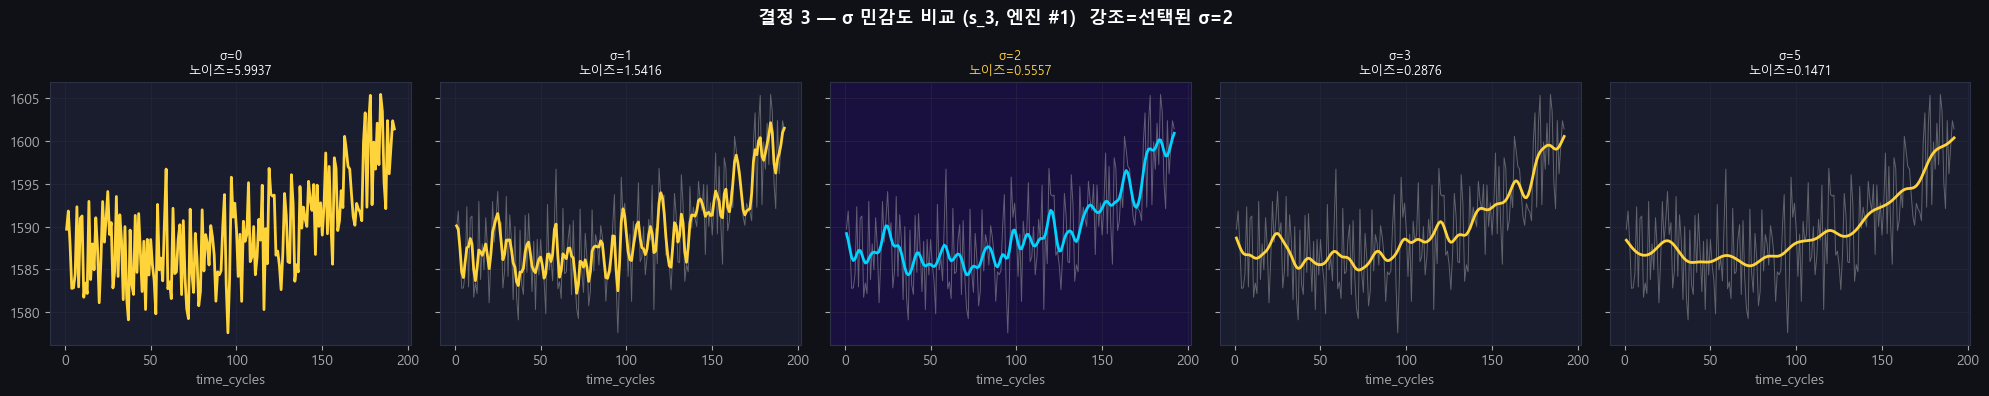

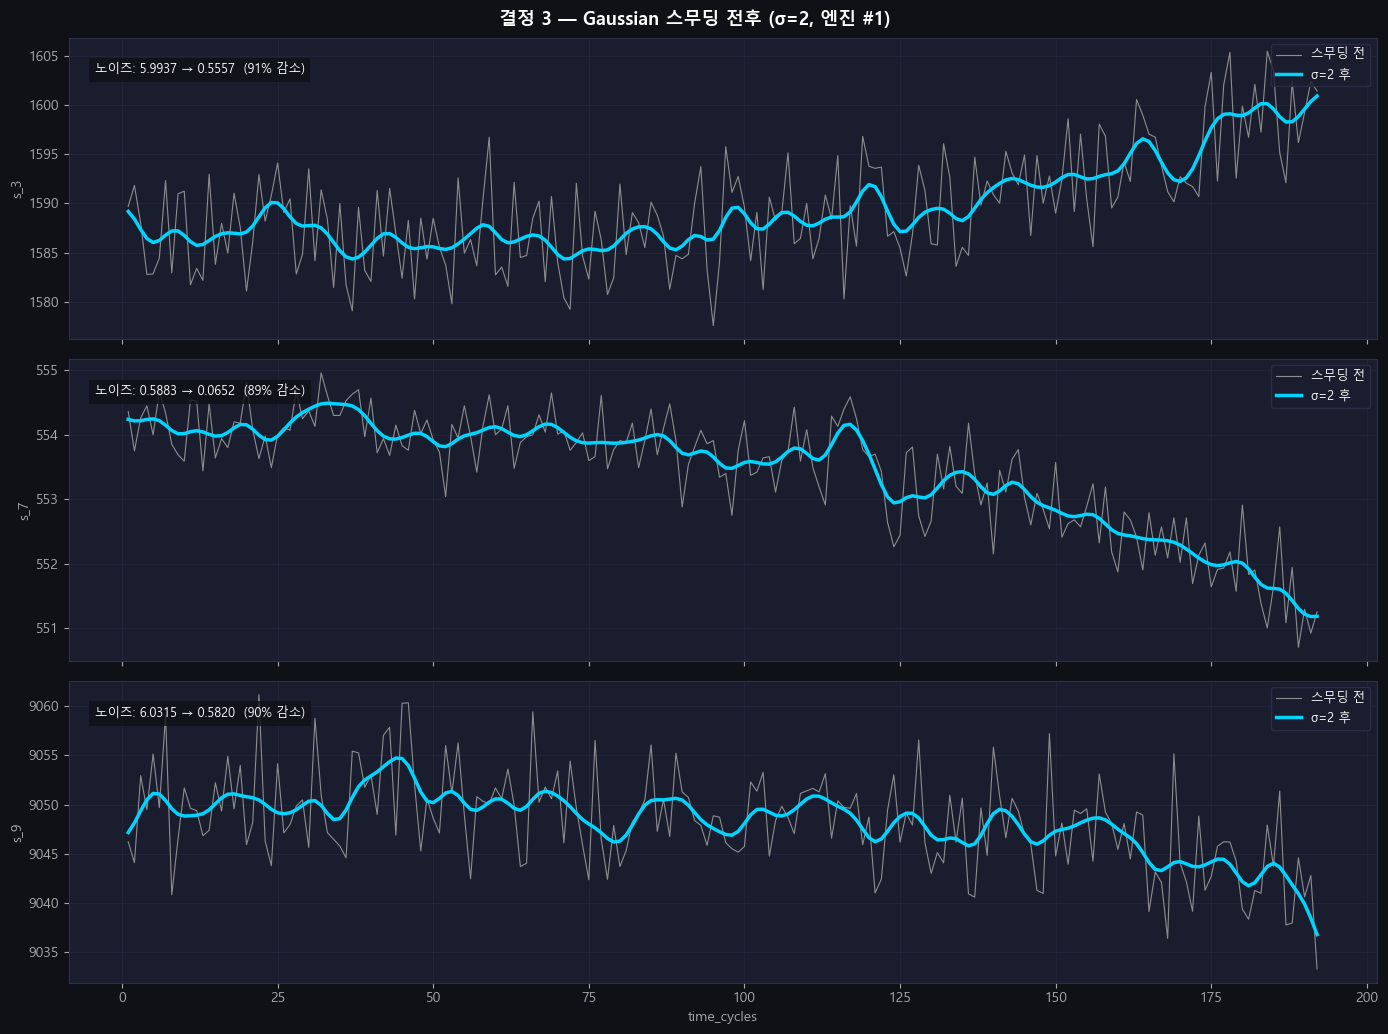

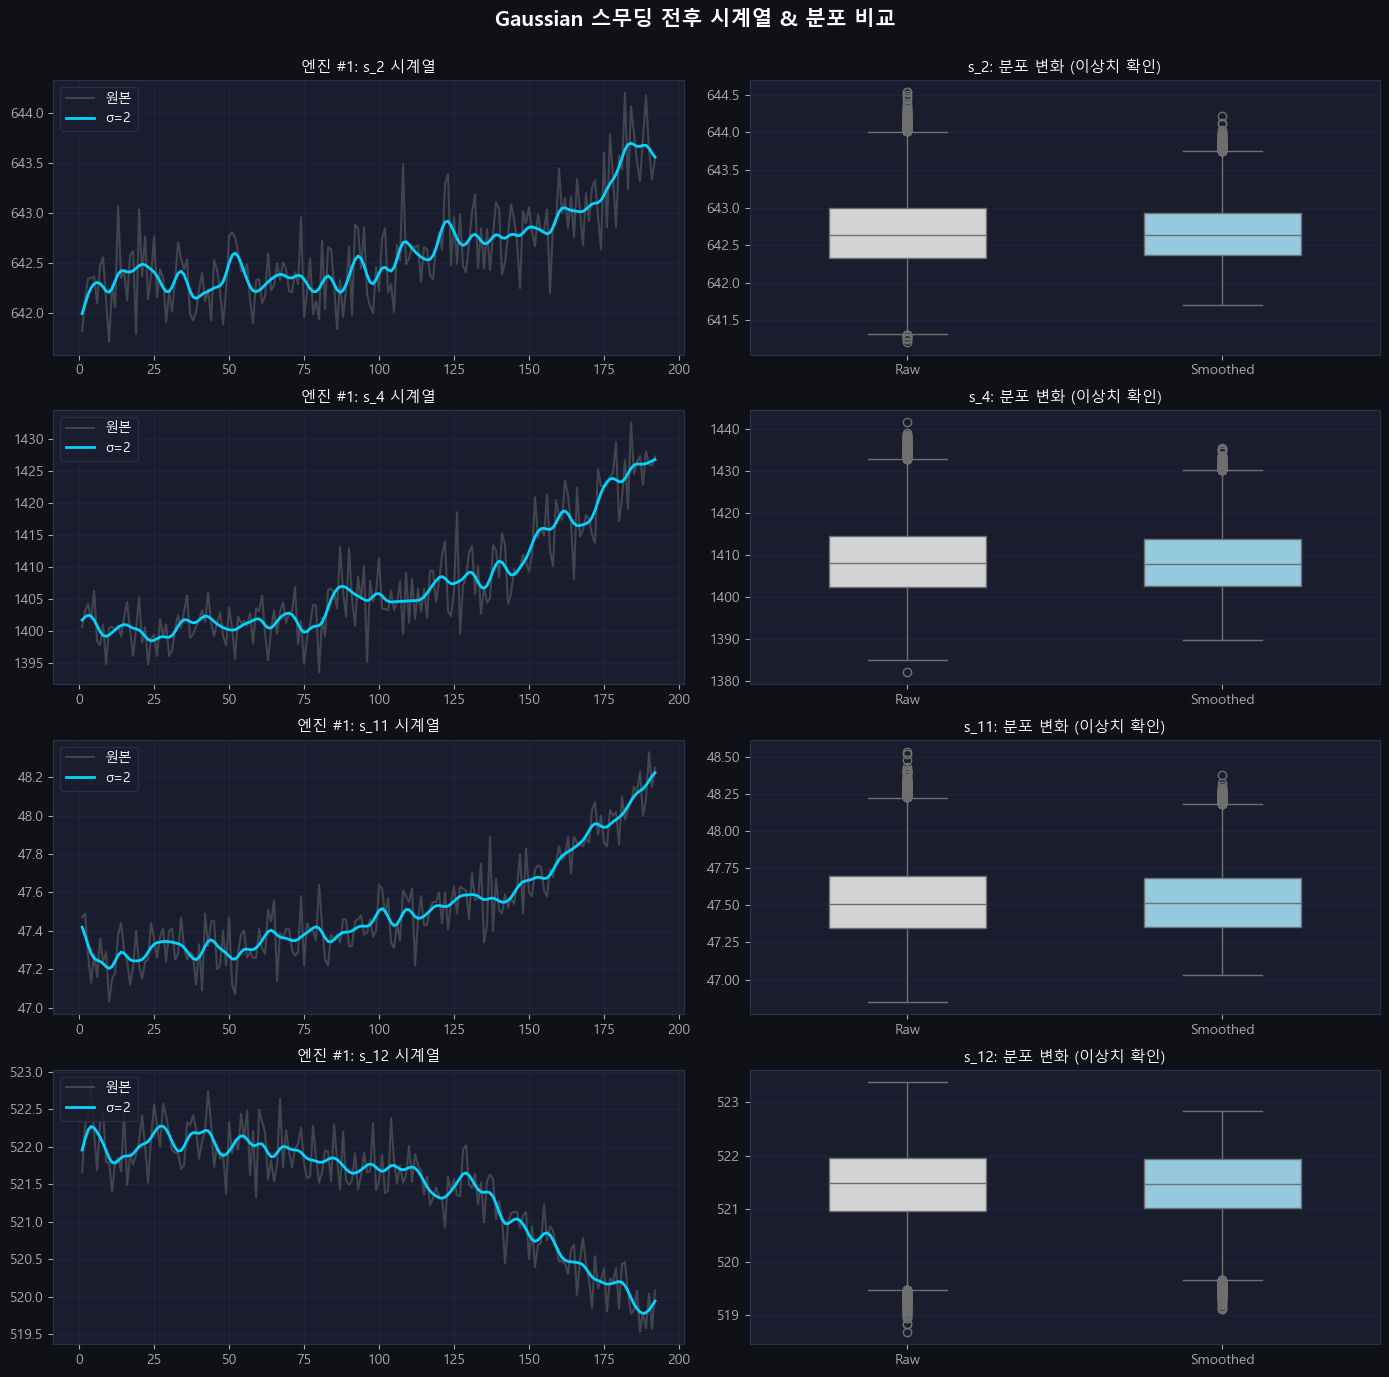

✅ 결정 3 완료  (σ=2, mode=nearest)


In [18]:
def apply_gaussian(df, features, sigma=GAUSS_SIGMA):
    df = df.copy().sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
    df[features] = df[features].astype(np.float32)
    for uid in df['unit_nr'].unique():
        mask = df['unit_nr'] == uid
        for col in features:
            arr = df.loc[mask, col].to_numpy(dtype=np.float32)
            df.loc[mask, col] = gaussian_filter1d(arr, sigma=sigma, mode='nearest')
    return df

train_s3 = apply_gaussian(train_s2, USEFUL_SENSORS)
test_s3  = apply_gaussian(test_s2,  USEFUL_SENSORS)

# σ 민감도 비교
unit1_raw = train_s2[train_s2['unit_nr']==1].sort_values('time_cycles')
s_ex = 's_3' if 's_3' in USEFUL_SENSORS else USEFUL_SENSORS[0]
sigmas_test = [0, 1, 2, 3, 5]

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig.suptitle(f'결정 3 — σ 민감도 비교 ({s_ex}, 엔진 #1)  강조=선택된 σ=2', fontsize=13, fontweight='bold')
for ax, sig in zip(axes, sigmas_test):
    y_raw = unit1_raw[s_ex].values
    y_f   = gaussian_filter1d(y_raw, sigma=sig, mode='nearest') if sig>0 else y_raw
    noise = np.std(np.diff(y_f))
    ax.plot(unit1_raw['time_cycles'], y_raw, color=GRAY, alpha=0.5, lw=0.7, label='원본')
    ax.plot(unit1_raw['time_cycles'], y_f,   color=C[0] if sig==GAUSS_SIGMA else C[3], lw=2)
    ax.set_title(f'σ={sig}\n노이즈={noise:.4f}',
                 color='#ffd43b' if sig==GAUSS_SIGMA else WHITE, fontsize=9)
    if sig==GAUSS_SIGMA: ax.patch.set_facecolor('#1a1040')
    ax.set_xlabel('time_cycles')
plt.tight_layout(); plt.show()

# 전후 비교
unit1_before = train_s2[train_s2['unit_nr']==1].sort_values('time_cycles')
unit1_after  = train_s3[train_s3['unit_nr']==1].sort_values('time_cycles')
show3 = [s for s in ['s_3','s_7','s_9'] if s in USEFUL_SENSORS]
if len(show3) < 2: show3 = USEFUL_SENSORS[:3]

fig, axes = plt.subplots(len(show3), 1, figsize=(14, 3.5*len(show3)), sharex=True)
if len(show3)==1: axes=[axes]
fig.suptitle(f'결정 3 — Gaussian 스무딩 전후 (σ={GAUSS_SIGMA}, 엔진 #1)', fontsize=13, fontweight='bold')
for ax, s in zip(axes, show3):
    ax.plot(unit1_before['time_cycles'], unit1_before[s], color=GRAY, lw=0.8, alpha=0.8, label='스무딩 전')
    ax.plot(unit1_after['time_cycles'],  unit1_after[s],  color=C[0], lw=2.5, label=f'σ={GAUSS_SIGMA} 후')
    nb = np.std(np.diff(unit1_before[s].values)); na = np.std(np.diff(unit1_after[s].values))
    pct = (1-na/nb)*100 if nb>0 else 0
    ax.text(0.02, 0.88, f'노이즈: {nb:.4f} → {na:.4f}  ({pct:.0f}% 감소)',
            transform=ax.transAxes, fontsize=9, bbox=dict(facecolor=BG, alpha=0.8, edgecolor='none'))
    ax.set_ylabel(s); ax.legend(fontsize=9, loc='upper right')
axes[-1].set_xlabel('time_cycles')
plt.tight_layout(); plt.show()

# 전후 박스플롯 비교 (4개 센서)
sample_sensors_gauss = ['s_2', 's_4', 's_11', 's_12']
unit_id_gauss = 1
fig, axes = plt.subplots(len(sample_sensors_gauss), 2, figsize=(14, 14))
for i, sensor in enumerate(sample_sensors_gauss):
    # 시계열 비교
    axes[i,0].plot(train_s2[train_s2['unit_nr']==unit_id_gauss]['time_cycles'],
                   train_s2[train_s2['unit_nr']==unit_id_gauss][sensor],
                   color='gray', alpha=0.4, label='원본')
    axes[i,0].plot(train_s3[train_s3['unit_nr']==unit_id_gauss]['time_cycles'],
                   train_s3[train_s3['unit_nr']==unit_id_gauss][sensor],
                   color=C[0], lw=2, label=f'σ={GAUSS_SIGMA}')
    axes[i,0].set_title(f'엔진 #{unit_id_gauss}: {sensor} 시계열', fontsize=11)
    axes[i,0].legend(loc='upper left')
    # 박스플롯 비교
    compare_df = pd.DataFrame({'Raw': train_s2[sensor], 'Smoothed': train_s3[sensor]})
    sns.boxplot(data=compare_df, ax=axes[i,1], palette=['lightgray','skyblue'], width=0.5)
    axes[i,1].set_title(f'{sensor}: 분포 변화 (이상치 확인)', fontsize=11)
plt.tight_layout(); plt.subplots_adjust(top=0.93)
fig.suptitle('Gaussian 스무딩 전후 시계열 & 분포 비교', fontsize=15, fontweight='bold')
plt.show()

print(f'✅ 결정 3 완료  (σ={GAUSS_SIGMA}, mode=nearest)')


## 7. 결정 4 — Validation 분할 (엔진 단위 랜덤 80:20, random_state=42)

**공통 전처리(상수 제거 → RUL cap → Gaussian)가 끝난 `train_s3` 기준으로 분리.**  
파생변수(ML) 또는 슬라이딩 윈도우(DL)는 **정규화 이후** 각 분기에서 독립적으로 생성한다.

> ✅ 같은 엔진이 sub-train / validation에 동시에 들어가지 않도록 **unit 단위 그룹 분할**  
> ✅ `random_state=42`로 고정하여 **항상 동일한 엔진 조합**이 선택되도록 설정


In [19]:
VALID_RATIO  = 0.2
RANDOM_STATE = 42

gss = GroupShuffleSplit(n_splits=1, test_size=VALID_RATIO, random_state=RANDOM_STATE)
subtrain_idx, valid_idx = next(gss.split(train_s3, groups=train_s3['unit_nr']))

subtrain_common = train_s3.iloc[subtrain_idx].copy().reset_index(drop=True)
valid_common    = train_s3.iloc[valid_idx].copy().reset_index(drop=True)
test_common     = test_s3.copy()

subtrain_units = np.sort(subtrain_common['unit_nr'].unique())
valid_units    = np.sort(valid_common['unit_nr'].unique())
all_units      = np.sort(train_s3['unit_nr'].unique())

# 누수 방지 검증
overlap = set(subtrain_units).intersection(set(valid_units))
assert len(overlap) == 0, f'❌ train/valid 엔진 겹침 발생: {sorted(list(overlap))[:5]}'
assert len(subtrain_units) + len(valid_units) == len(all_units), '❌ 엔진 수 합이 전체와 다릅니다.'

print('=== 결정 4 — Validation 분할 완료 ===')
print(f'분할 방식: GroupShuffleSplit (unit 기준)  |  random_state={RANDOM_STATE}')
print(f'전체 train 엔진: {len(all_units)}대  |  sub-train: {len(subtrain_units)}대  |  valid: {len(valid_units)}대')
print(f'겹치는 엔진 수: {len(overlap)}  ✅')

display(pd.DataFrame({
    '구분'          : ['Sub-train', 'Validation', 'Test'],
    '행 수'         : [len(subtrain_common), len(valid_common), len(test_common)],
    '엔진 수'       : [subtrain_common['unit_nr'].nunique(), valid_common['unit_nr'].nunique(),
                       test_common['unit_nr'].nunique()],
    '피처 수(공통)' : [len(USEFUL_SENSORS)] * 3,
    'RUL 포함'      : ['예', '예', '아니오'],
}))

=== 결정 4 — Validation 분할 완료 ===
분할 방식: GroupShuffleSplit (unit 기준)  |  random_state=42
전체 train 엔진: 100대  |  sub-train: 80대  |  valid: 20대
겹치는 엔진 수: 0  ✅


,구분,행 수,엔진 수,피처 수(공통),RUL 포함
0,Sub-train,16561,80,14,예
1,Validation,4070,20,14,예
2,Test,13096,100,14,아니오


## 8. 결정 5 — MinMax 정규화 (sub-train 기준 fit)

**fit은 `sub-train`에서만** — validation·test는 동일 scaler로 transform (데이터 누수 방지).  
정규화 대상: **유용 센서 컬럼** (`USEFUL_SENSORS`) — ML/DL 파생변수는 정규화 후 생성.


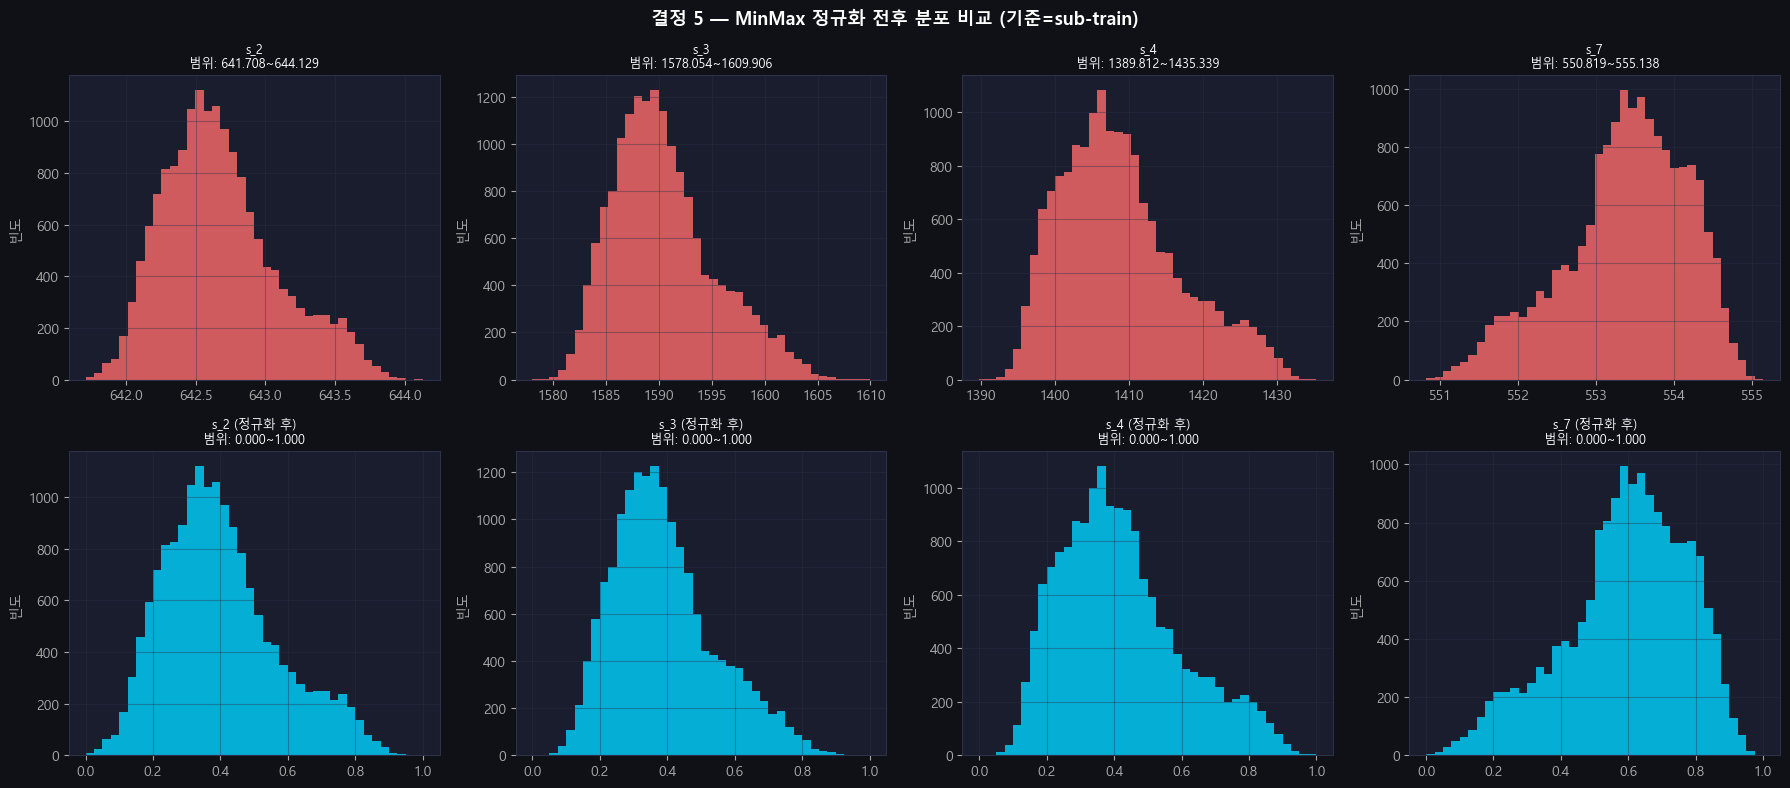

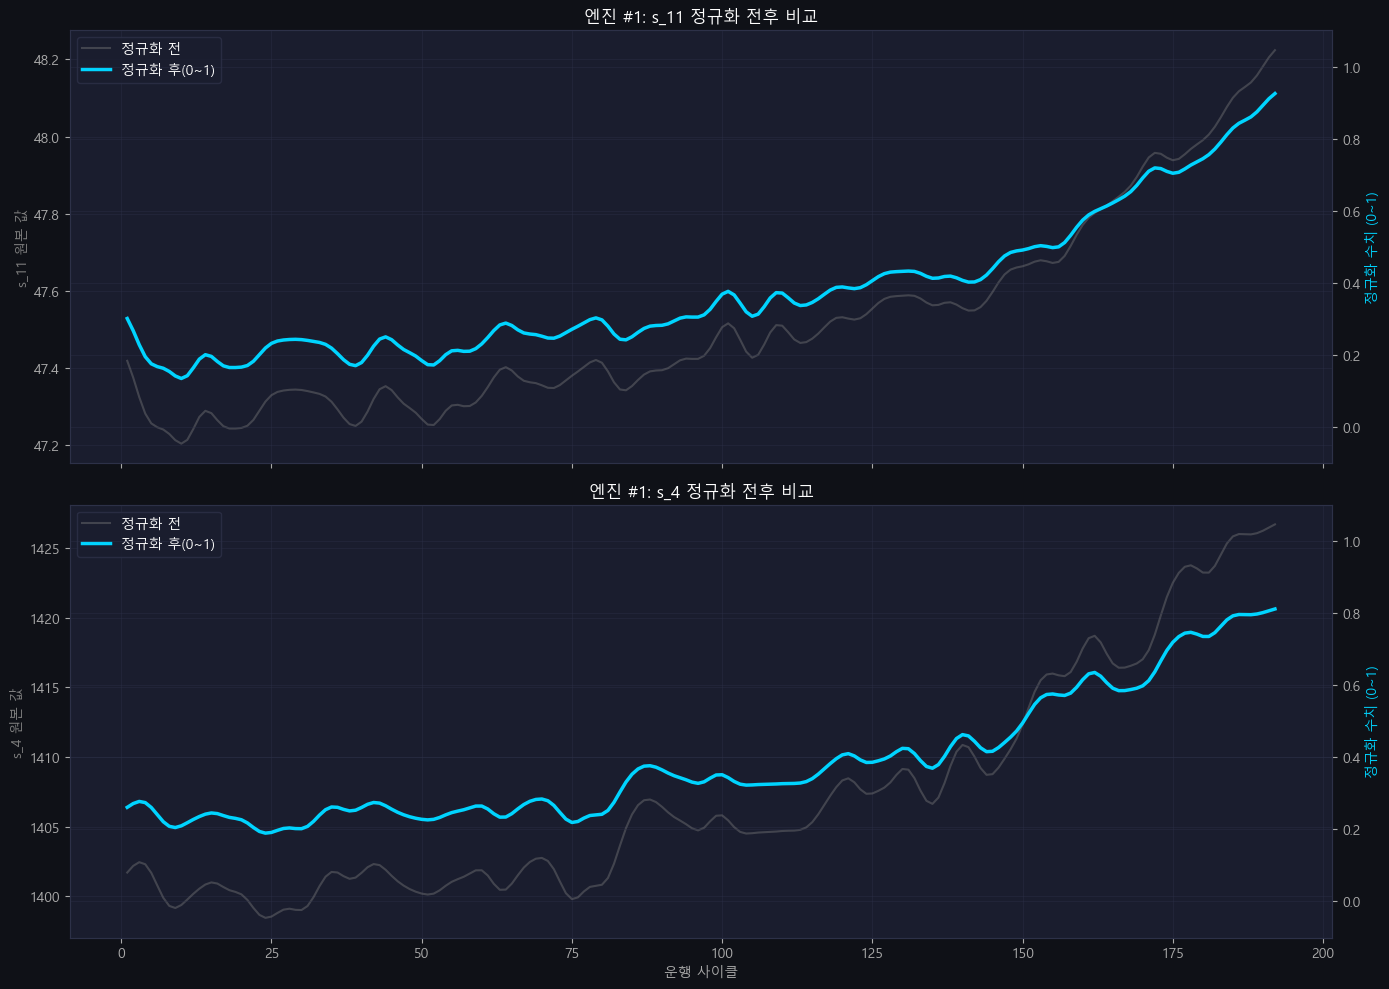

,전_min,전_max,후_min,후_max
s_2,641.708191,644.129395,0.0,1.0
s_3,1578.054077,1609.906494,0.0,1.0
s_4,1389.811523,1435.338623,0.0,1.0
s_7,550.819397,555.138428,0.0,1.0
s_8,2387.958008,2388.467285,0.0,1.0
s_9,9027.010742,9235.208984,0.0,1.0
s_11,47.029999,48.320301,0.0,1.0
s_12,519.109802,522.842102,0.0,1.0
s_13,2387.961914,2388.457031,0.0,1.0
s_14,8103.128906,8288.884766,0.0,1.0



✅ 결정 5 완료
   Sub-train : 0.0000~1.0000
   Validation: -0.1094~1.0457
   Test      : -0.0607~1.0086


In [20]:
before_min = subtrain_common[USEFUL_SENSORS].min()
before_max = subtrain_common[USEFUL_SENSORS].max()

scaler = MinMaxScaler()
scaler.fit(subtrain_common[USEFUL_SENSORS])

subtrain_s4 = subtrain_common.copy()
valid_s4    = valid_common.copy()
test_s4     = test_common.copy()

subtrain_s4[USEFUL_SENSORS] = scaler.transform(subtrain_common[USEFUL_SENSORS])
valid_s4[USEFUL_SENSORS]    = scaler.transform(valid_common[USEFUL_SENSORS])
test_s4[USEFUL_SENSORS]     = scaler.transform(test_common[USEFUL_SENSORS])

# 전체 train (검증용 — 동일 scaler로 변환)
train_s4 = train_s3.copy()
train_s4[USEFUL_SENSORS] = scaler.transform(train_s3[USEFUL_SENSORS])

# 전후 분포 비교
show4 = USEFUL_SENSORS[:4]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('결정 5 — MinMax 정규화 전후 분포 비교 (기준=sub-train)', fontsize=13, fontweight='bold')
for col, s in enumerate(show4):
    b = subtrain_common[s]; a = subtrain_s4[s]
    axes[0, col].hist(b, bins=40, color=C[1], alpha=0.8, edgecolor='none')
    axes[0, col].set_title(f'{s}\n범위: {b.min():.3f}~{b.max():.3f}', fontsize=9)
    axes[0, col].set_ylabel('빈도')
    axes[1, col].hist(a, bins=40, color=C[0], alpha=0.8, edgecolor='none')
    axes[1, col].set_title(f'{s} (정규화 후)\n범위: {a.min():.3f}~{a.max():.3f}', fontsize=9)
    axes[1, col].set_ylabel('빈도')
plt.tight_layout(); plt.show()

# 정규화 전후 시계열 비교 (이중 축)
target_sensors_norm = ['s_11', 's_4']
unit_id_norm = 1
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
for i, sensor in enumerate(target_sensors_norm):
    lns1 = axes[i].plot(train_s3[train_s3['unit_nr']==unit_id_norm]['time_cycles'],
                        train_s3[train_s3['unit_nr']==unit_id_norm][sensor],
                        color='gray', alpha=0.4, label='정규화 전')
    axes[i].set_ylabel(f'{sensor} 원본 값', color='gray')
    ax2 = axes[i].twinx()
    lns2 = ax2.plot(train_s4[train_s4['unit_nr']==unit_id_norm]['time_cycles'],
                    train_s4[train_s4['unit_nr']==unit_id_norm][sensor],
                    color=C[0], lw=2.5, label='정규화 후(0~1)')
    ax2.set_ylabel('정규화 수치 (0~1)', color=C[0]); ax2.set_ylim(-0.1, 1.1)
    lns = lns1+lns2; labs = [l.get_label() for l in lns]
    axes[i].legend(lns, labs, loc='upper left')
    axes[i].set_title(f'엔진 #{unit_id_norm}: {sensor} 정규화 전후 비교', fontsize=12)
axes[1].set_xlabel('운행 사이클')
plt.tight_layout(); plt.show()

range_df = pd.DataFrame({
    '전_min': before_min, '전_max': before_max,
    '후_min': subtrain_s4[USEFUL_SENSORS].min(),
    '후_max': subtrain_s4[USEFUL_SENSORS].max(),
})
display(range_df.round(4))
print(f'\n✅ 결정 5 완료')
print(f'   Sub-train : {subtrain_s4[USEFUL_SENSORS].min().min():.4f}~{subtrain_s4[USEFUL_SENSORS].max().max():.4f}')
print(f'   Validation: {valid_s4[USEFUL_SENSORS].min().min():.4f}~{valid_s4[USEFUL_SENSORS].max().max():.4f}')
print(f'   Test      : {test_s4[USEFUL_SENSORS].min().min():.4f}~{test_s4[USEFUL_SENSORS].max().max():.4f}')


---
## 9. 전처리 후 검증 — 공통 전처리 확인

### 9-1. 센서 간 상관관계 — 전처리 전후 비교

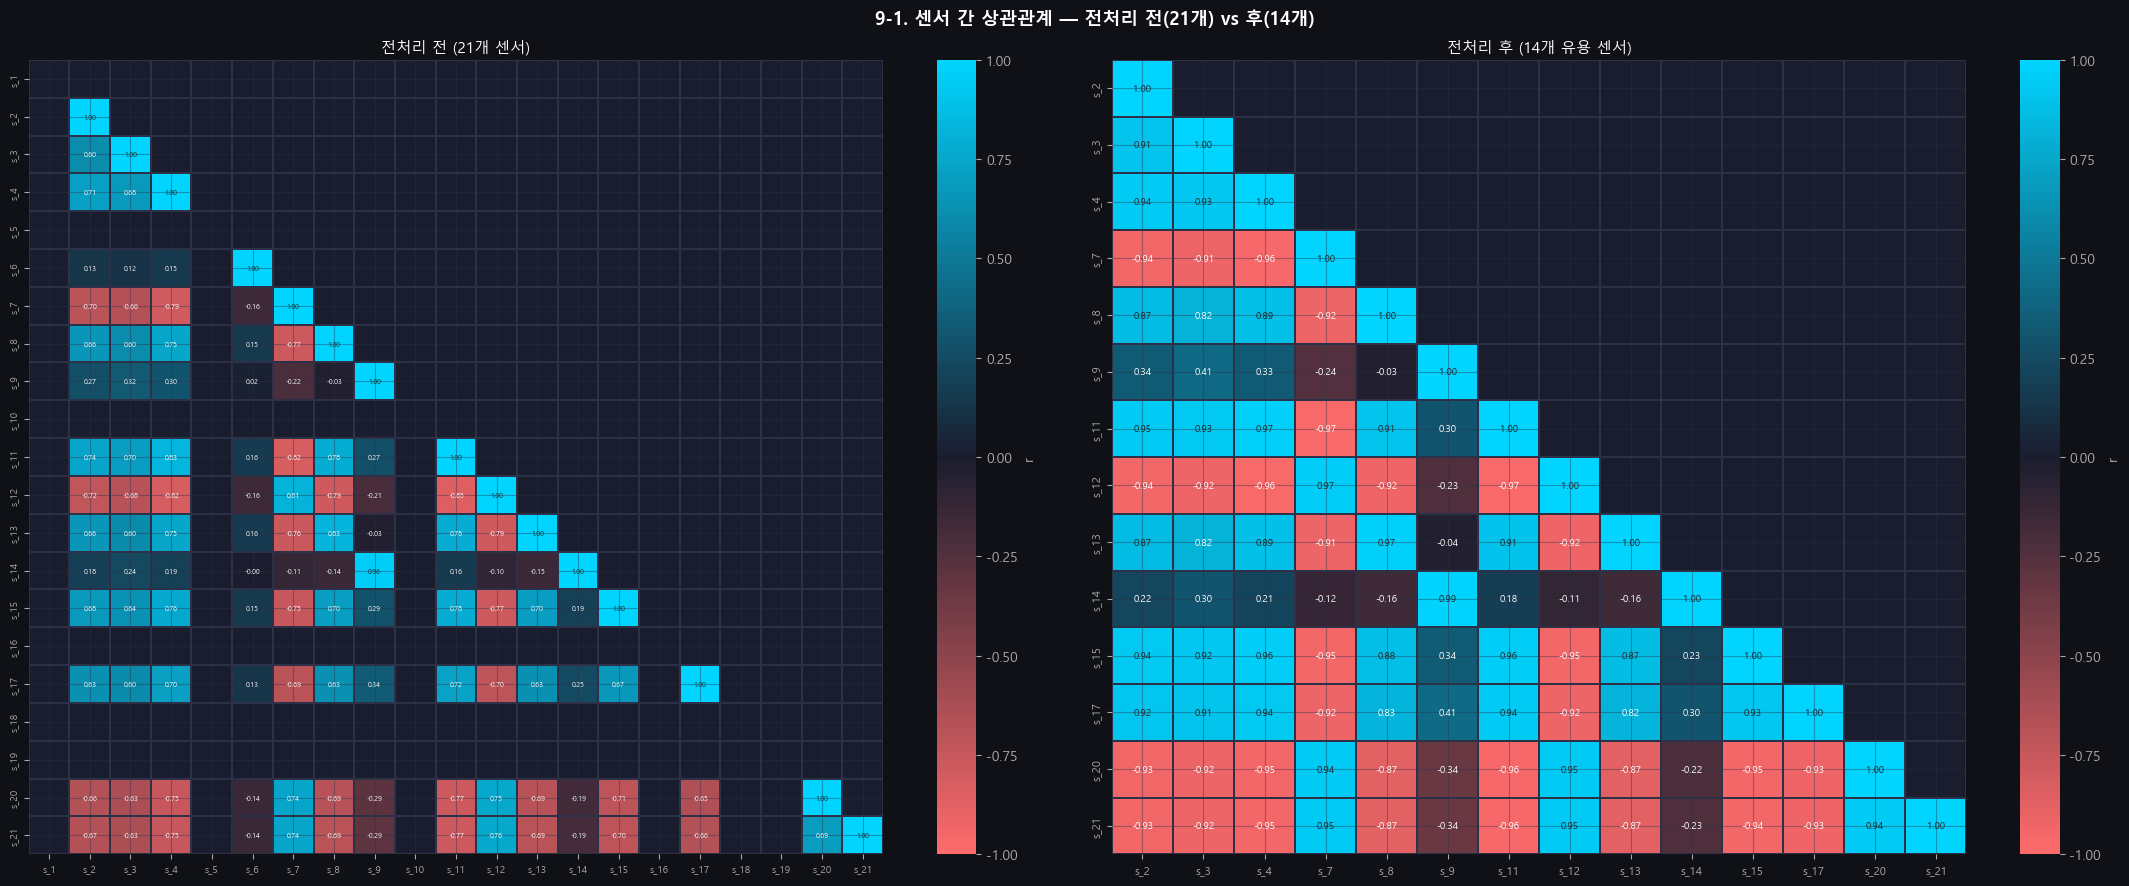

고상관 쌍(|r|>0.9): 전 1개 → 후 53개


In [21]:
corr_after = train_s4[USEFUL_SENSORS].corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle('9-1. 센서 간 상관관계 — 전처리 전(21개) vs 후(14개)', fontsize=13, fontweight='bold')

mask_b = np.triu(np.ones_like(corr_before, dtype=bool), k=1)
sns.heatmap(corr_before, ax=axes[0], mask=mask_b, cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size':5}, linewidths=0.3, linecolor=GRID, cbar_kws={'label':'r'})
axes[0].set_title('전처리 전 (21개 센서)', fontsize=11); axes[0].tick_params(labelsize=7)

mask_a = np.triu(np.ones_like(corr_after, dtype=bool), k=1)
sns.heatmap(corr_after, ax=axes[1], mask=mask_a, cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size':7}, linewidths=0.3, linecolor=GRID, cbar_kws={'label':'r'})
axes[1].set_title('전처리 후 (14개 유용 센서)', fontsize=11); axes[1].tick_params(labelsize=8)
plt.tight_layout(); plt.show()

pairs_after = [(USEFUL_SENSORS[i],USEFUL_SENSORS[j],round(corr_after.iloc[i,j],3))
               for i in range(len(USEFUL_SENSORS)) for j in range(i+1,len(USEFUL_SENSORS))
               if abs(corr_after.iloc[i,j])>0.9]
print(f'고상관 쌍(|r|>0.9): 전 {len(pairs)}개 → 후 {len(pairs_after)}개')


### 9-2. 센서 분포 전후 비교 (유용 센서 전체)

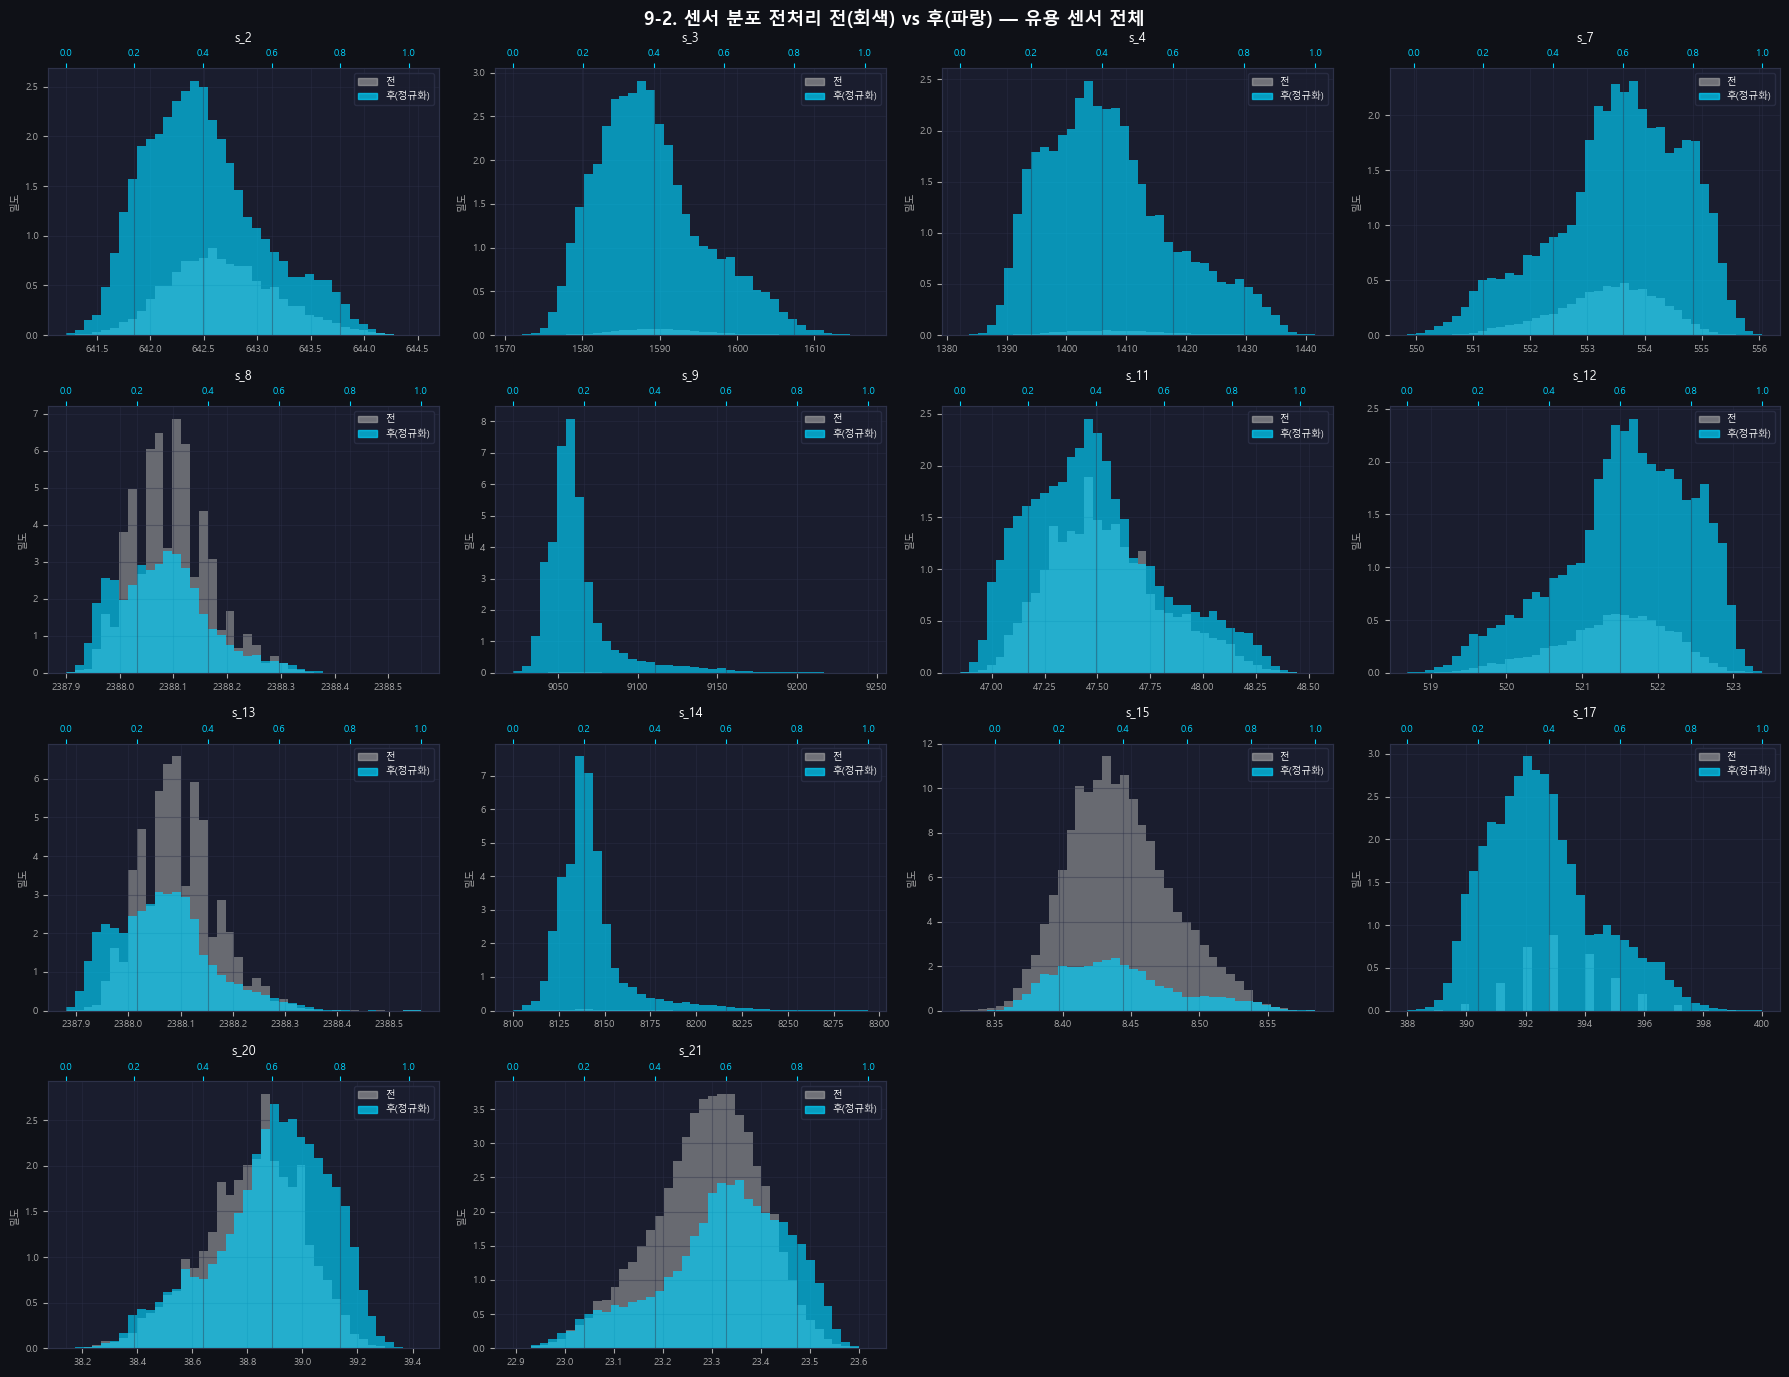

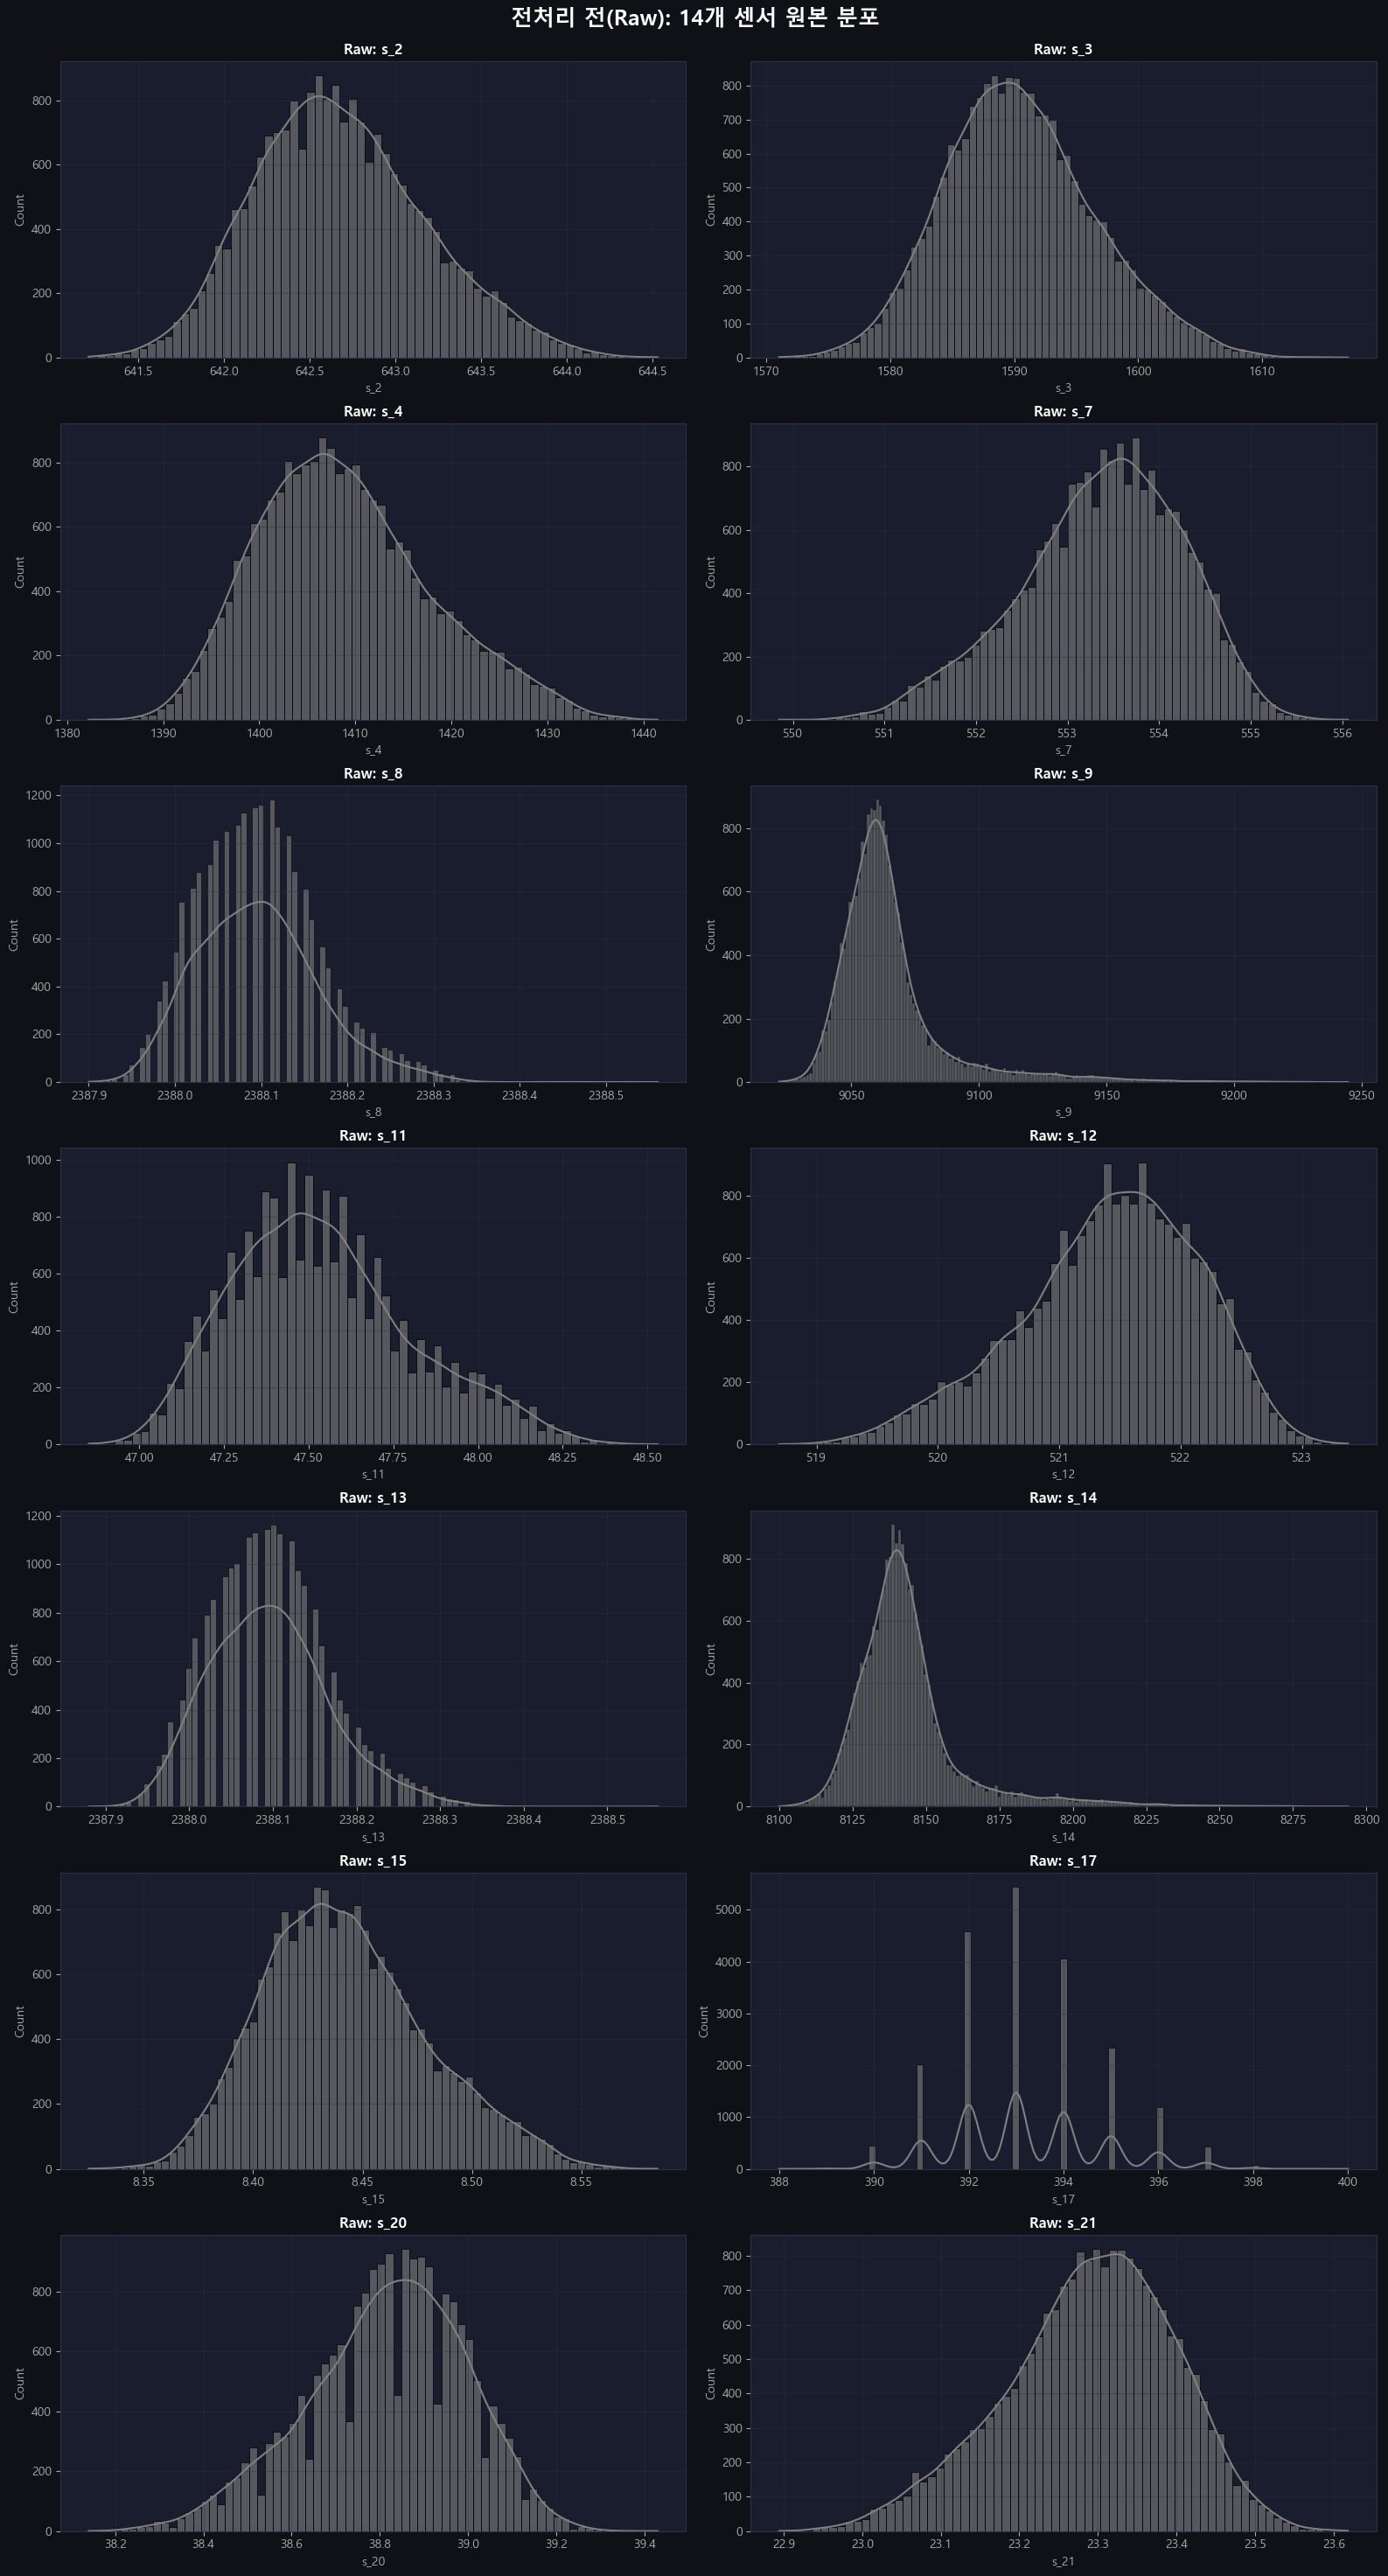

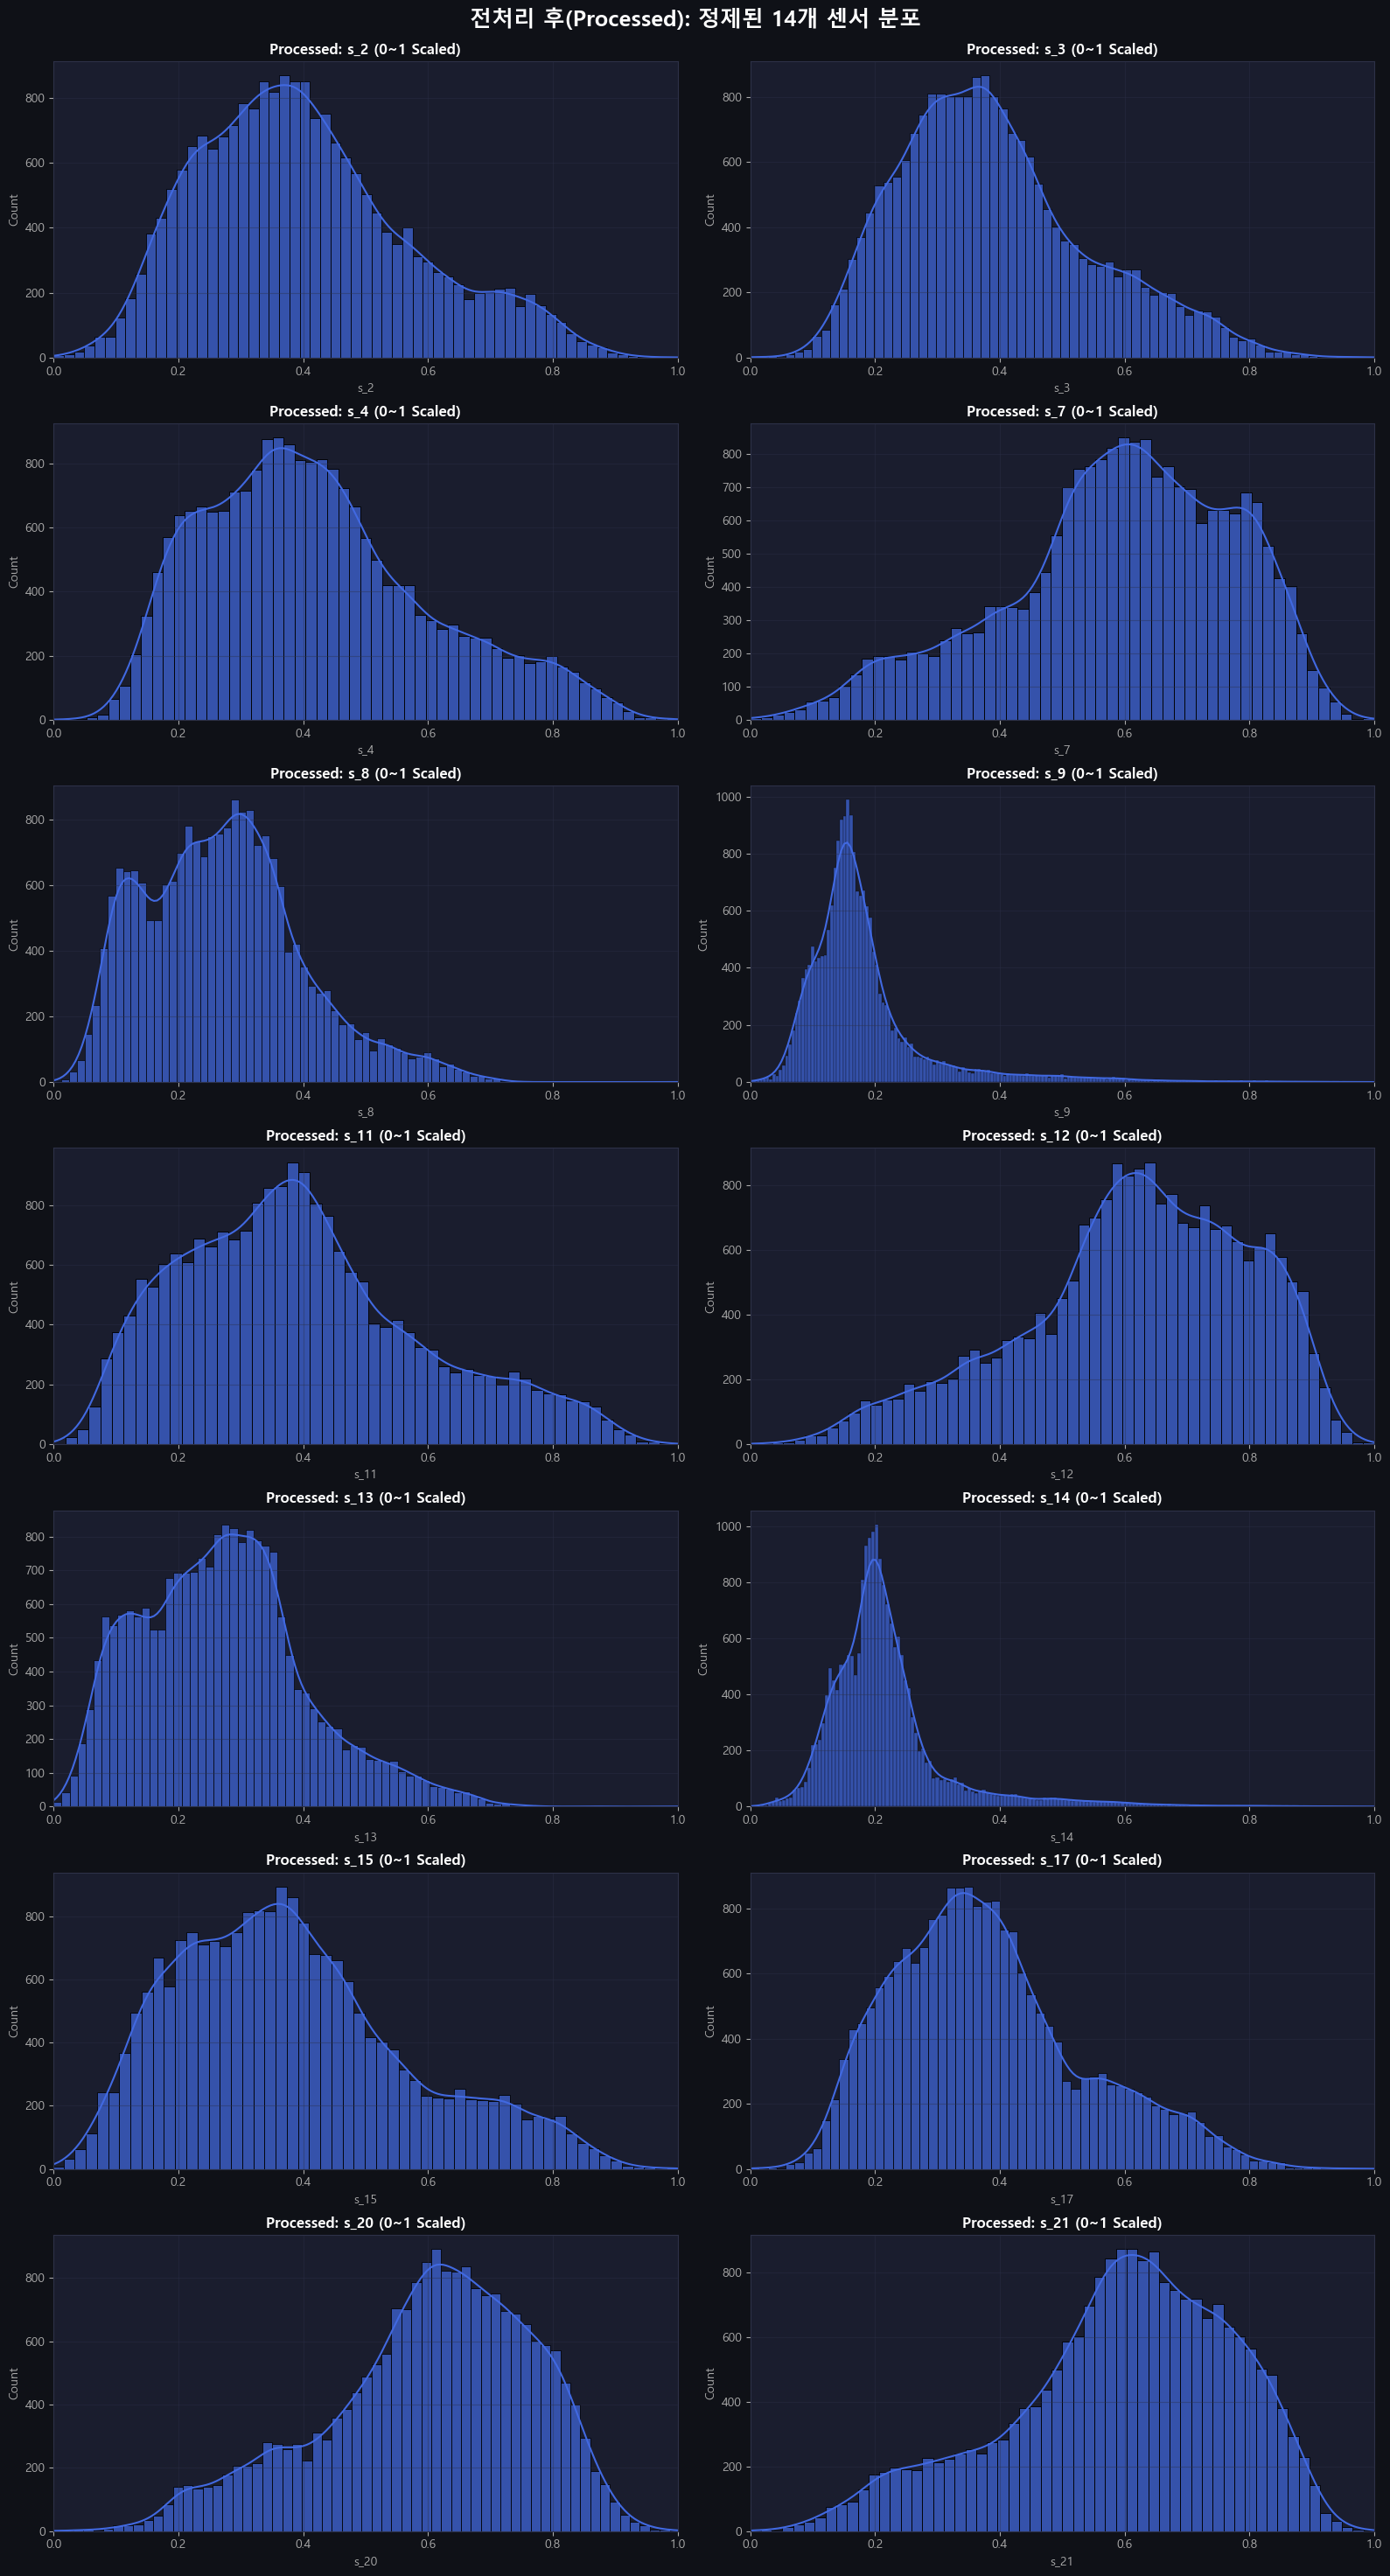

In [22]:
n_cols = 4
n_rows = (len(USEFUL_SENSORS)+n_cols-1)//n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*3.5))
fig.suptitle('9-2. 센서 분포 전처리 전(회색) vs 후(파랑) — 유용 센서 전체', fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, USEFUL_SENSORS):
    before_data = train_s2[s]; after_data = train_s4[s]
    ax2 = ax.twiny()
    ax.hist(before_data,  bins=40, color=GRAY, alpha=0.55, density=True)
    ax2.hist(after_data, bins=40, color=C[0],  alpha=0.65, density=True)
    ax.set_title(f'{s}', fontsize=9); ax.set_ylabel('밀도', fontsize=7)
    ax.tick_params(labelsize=7); ax2.tick_params(labelsize=7, colors=C[0])
    handles = [mpatches.Patch(color=GRAY, alpha=0.6, label='전'),
               mpatches.Patch(color=C[0], alpha=0.7, label='후(정규화)')]
    ax.legend(handles=handles, fontsize=7, loc='upper right')
for ax in axes.flat[len(USEFUL_SENSORS):]: ax.set_visible(False)
plt.tight_layout(); plt.show()

# 히스토그램 전후 (전처리 전 raw / 전처리 후 0~1)
fig_b, axes_b = plt.subplots(7, 2, figsize=(16, 30))
axes_b = axes_b.flatten()
for i, sensor in enumerate(USEFUL_SENSORS):
    sns.histplot(train_s2[sensor], color='gray', kde=True, ax=axes_b[i], alpha=0.6)
    axes_b[i].set_title(f'Raw: {sensor}', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.subplots_adjust(top=0.96)
fig_b.suptitle('전처리 전(Raw): 14개 센서 원본 분포', fontsize=18, fontweight='bold')
plt.show()

fig_a, axes_a = plt.subplots(7, 2, figsize=(16, 30))
axes_a = axes_a.flatten()
for i, sensor in enumerate(USEFUL_SENSORS):
    sns.histplot(train_s4[sensor], color='royalblue', kde=True, ax=axes_a[i], alpha=0.7)
    axes_a[i].set_xlim(0, 1)
    axes_a[i].set_title(f'Processed: {sensor} (0~1 Scaled)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.subplots_adjust(top=0.96)
fig_a.suptitle('전처리 후(Processed): 정제된 14개 센서 분포', fontsize=18, fontweight='bold')
plt.show()


### 9-3. Train vs Test 분포 비교 (전처리 후, KS 검정)

=== 9-3. Train vs Test 분포 비교 (KS 검정) ===


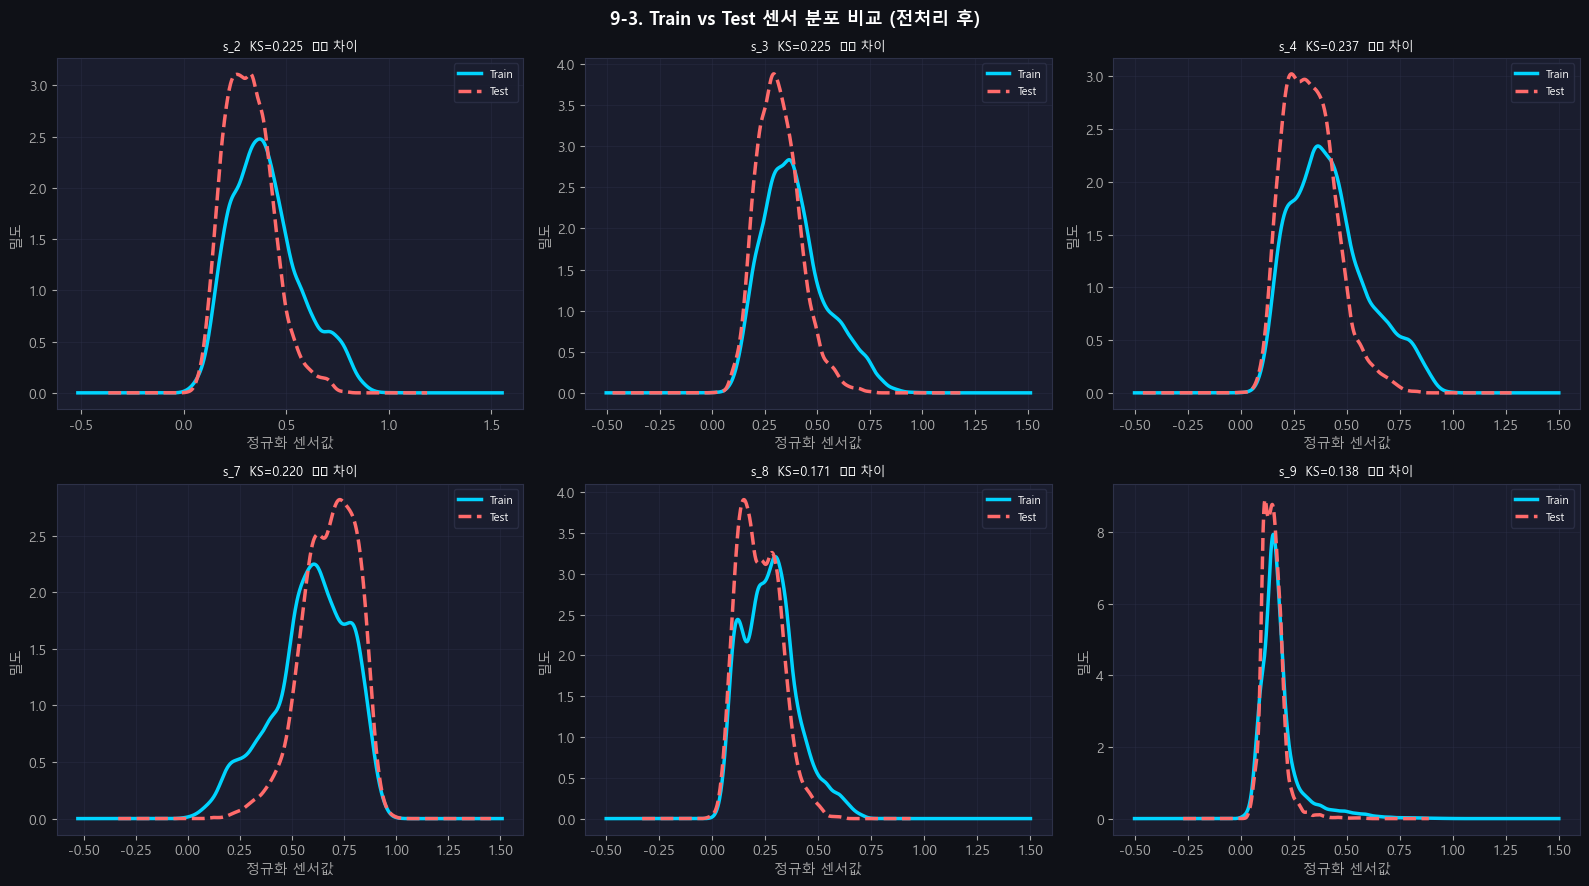

,KS통계량,p-value,판정
센서,,,
s_2,0.2251,0.0,⚠️ 차이
s_3,0.2248,0.0,⚠️ 차이
s_4,0.2369,0.0,⚠️ 차이
s_7,0.2201,0.0,⚠️ 차이
s_8,0.1711,0.0,⚠️ 차이
s_9,0.1384,0.0,⚠️ 차이


📌 Train=고장 전체기록(극단값 포함) / Test=고장 전 일부 → 분포 차이는 설계 특성


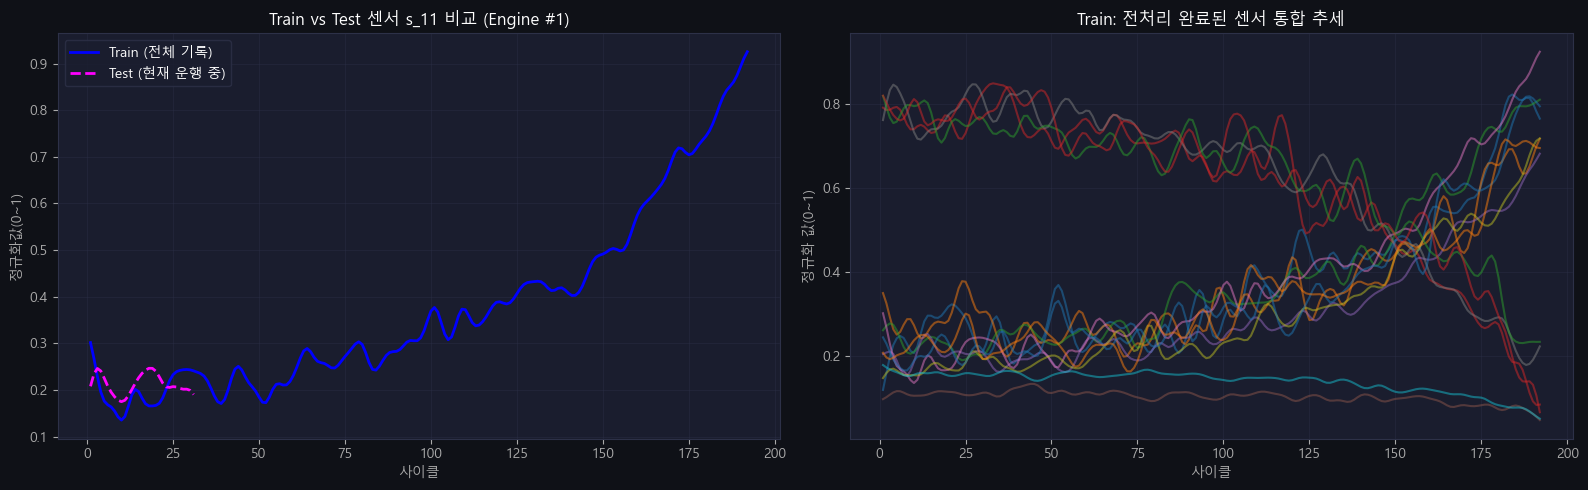

In [23]:
print('=== 9-3. Train vs Test 분포 비교 (KS 검정) ===')
show6 = USEFUL_SENSORS[:6]; ks_rows = []
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('9-3. Train vs Test 센서 분포 비교 (전처리 후)', fontsize=13, fontweight='bold')
for ax, s in zip(axes.flat, show6):
    tr_v = train_s4[s].dropna(); te_v = test_s4[s].dropna()
    try: tr_v.plot.kde(ax=ax, color=C[0], lw=2.5, label='Train')
    except: pass
    try: te_v.plot.kde(ax=ax, color=C[1], lw=2.5, ls='--', label='Test')
    except: pass
    ks_stat, ks_p = ks_2samp(tr_v, te_v)
    verdict = '✅ 유사' if ks_p>0.05 else '⚠️ 차이'
    ks_rows.append({'센서':s,'KS통계량':round(ks_stat,4),'p-value':round(ks_p,4),'판정':verdict})
    ax.set_title(f'{s}  KS={ks_stat:.3f}  {verdict}', fontsize=9)
    ax.set_xlabel('정규화 센서값'); ax.set_ylabel('밀도'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
display(pd.DataFrame(ks_rows).set_index('센서'))
print('📌 Train=고장 전체기록(극단값 포함) / Test=고장 전 일부 → 분포 차이는 설계 특성')

# Test 데이터 전처리 시각화 (엔진 #1)
unit_id_test = 1
test_sample = test_s4[test_s4['unit_nr'] == unit_id_test]
fig_t, axes_t = plt.subplots(1, 2, figsize=(16, 5))
for sensor_cmp in ['s_11']:
    train_unit_s = train_s4[train_s4['unit_nr'] == 1]
    test_unit_s  = test_s4[test_s4['unit_nr'] == 1]
    axes_t[0].plot(train_unit_s['time_cycles'], train_unit_s[sensor_cmp],
                   color='blue', lw=2, label='Train (전체 기록)')
    axes_t[0].plot(test_unit_s['time_cycles'], test_unit_s[sensor_cmp],
                   color='magenta', lw=2, ls='--', label='Test (현재 운행 중)')
    axes_t[0].set_title(f'Train vs Test 센서 {sensor_cmp} 비교 (Engine #1)', fontsize=12)
    axes_t[0].set_xlabel('사이클'); axes_t[0].set_ylabel('정규화값(0~1)'); axes_t[0].legend()

sensor_names_14 = USEFUL_SENSORS
train_unit_all = train_s4[train_s4['unit_nr'] == 1]
test_unit_all  = test_s4[test_s4['unit_nr'] == 1]
for sensor in sensor_names_14:
    axes_t[1].plot(train_unit_all['time_cycles'], train_unit_all[sensor], alpha=0.5)
axes_t[1].set_title('Train: 전처리 완료된 센서 통합 추세', fontsize=12)
axes_t[1].set_xlabel('사이클'); axes_t[1].set_ylabel('정규화 값(0~1)')
plt.tight_layout(); plt.show()


### 9-4. 열화 트렌드 + RUL 상관계수 변화

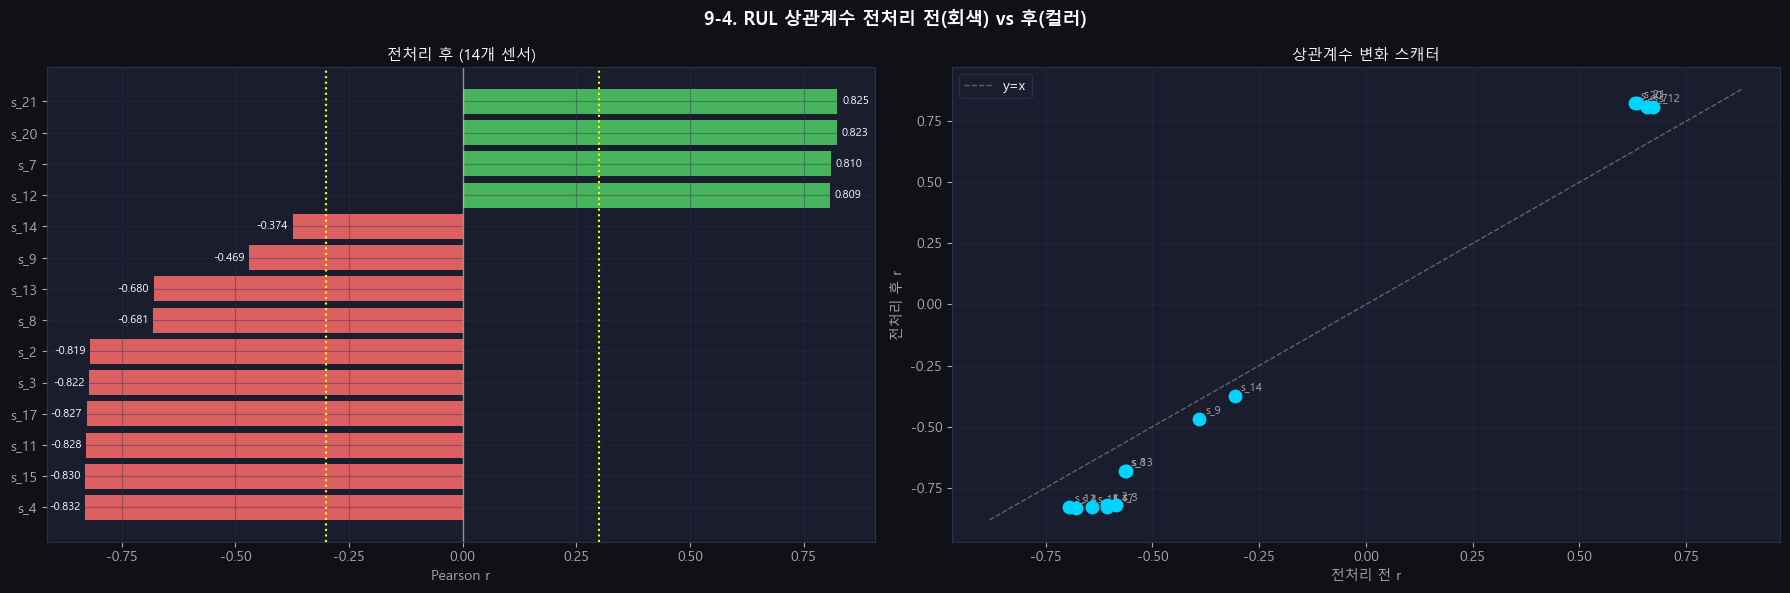

In [24]:
rul_corr_after = train_s4[USEFUL_SENSORS+['RUL']].corr()['RUL'][USEFUL_SENSORS].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('9-4. RUL 상관계수 전처리 전(회색) vs 후(컬러)', fontsize=13, fontweight='bold')

bc = [C[1] if v<0 else C[2] for v in rul_corr_after]
bars = axes[0].barh(rul_corr_after.index, rul_corr_after.values, color=bc, alpha=0.85)
axes[0].axvline(0, color='white', lw=1, alpha=0.5)
axes[0].axvline( 0.3, color='yellow', lw=1.5, ls=':')
axes[0].axvline(-0.3, color='yellow', lw=1.5, ls=':')
axes[0].set_title('전처리 후 (14개 센서)'); axes[0].set_xlabel('Pearson r')
for bar, val in zip(bars, rul_corr_after.values):
    axes[0].text(val+(0.01 if val>=0 else -0.01), bar.get_y()+bar.get_height()/2,
                 f'{val:.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=8)

common_s = [s for s in USEFUL_SENSORS if s in rul_corr_before.index]
r_b = rul_corr_before[common_s]; r_a = rul_corr_after[common_s]
axes[1].scatter(r_b, r_a, color=C[0], s=80, zorder=5)
for s in common_s:
    axes[1].annotate(s, (r_b[s], r_a[s]), fontsize=8, color=GRAY, xytext=(4,4), textcoords='offset points')
lim = max(abs(r_b).max(), abs(r_a).max()) + 0.05
axes[1].plot([-lim,lim],[-lim,lim], color=GRAY, ls='--', lw=1, alpha=0.5, label='y=x')
axes[1].set_xlabel('전처리 전 r'); axes[1].set_ylabel('전처리 후 r')
axes[1].set_title('상관계수 변화 스캐터'); axes[1].legend()
plt.tight_layout(); plt.show()


### 9-5. [ML] 파생변수 다중공선성 확인 (|r| > 0.95)

> **목적:** ML 파생변수 간 거의 동일한 정보를 담는 쌍 탐지 — 모델 피처 중요도 확인 후 제거 결정

In [25]:
# 이 셀은 ML 파생변수 생성(Section 10) 이후에 실행하세요.
# Section 10에서 subtrain_ml과 ML_FEATURES 변수를 생성한 후 아래 코드를 실행합니다.
# (여기서는 미리 정의 — Section 10 실행 후 자동으로 동작)
print('※ ML 파생변수 다중공선성 확인은 Section 10 실행 후 아래 코드가 동작합니다.')
print('   아직 ML_FEATURES가 정의되지 않았다면 Section 10을 먼저 실행하세요.')

def check_multicollinearity(subtrain_ml, ML_FEATURES, HIGH_THR=0.95):
    print(f'=== ML 파생변수 다중공선성 확인 (sub-train, |r|>{HIGH_THR}) ===')
    print(f'분석 대상: ML_FEATURES {len(ML_FEATURES)}개')

    corr_ml  = subtrain_ml[ML_FEATURES].corr().abs()
    upper_ml = corr_ml.where(np.triu(np.ones(corr_ml.shape), k=1).astype(bool))
    high_pairs_ml = (upper_ml.stack().reset_index()
                     .rename(columns={'level_0':'피처A','level_1':'피처B',0:'|r|'})
                     .query(f'`|r|` >= {HIGH_THR}')
                     .sort_values('|r|', ascending=False).reset_index(drop=True))

    print(f'|r|≥{HIGH_THR} 쌍: {len(high_pairs_ml)}개 / 전체 {len(ML_FEATURES)*(len(ML_FEATURES)-1)//2}쌍')
    all_upper_vals = upper_ml.stack().values

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'9-5. ML 파생변수 다중공선성 ({len(ML_FEATURES)}개 피처)', fontsize=13, fontweight='bold')
    axes[0].hist(all_upper_vals, bins=50, color=C[0], alpha=0.8, edgecolor='none')
    axes[0].axvline(HIGH_THR, color='yellow', lw=2, ls=':', label=f'기준선 |r|={HIGH_THR}')
    axes[0].set_title('피처 간 |r| 분포'); axes[0].legend()

    from matplotlib.colors import LinearSegmentedColormap
    cmap_mc = LinearSegmentedColormap.from_list('mc', ['#1a1d2e','#00d4ff'], N=256)
    corr_orig = subtrain_ml[USEFUL_SENSORS].corr().abs()
    sns.heatmap(corr_orig, ax=axes[1], cmap=cmap_mc, vmin=0, vmax=1,
                annot=True, fmt='.2f', annot_kws={'size':8},
                linewidths=0.3, linecolor=GRID, cbar_kws={'label':'|r|'})
    axes[1].set_title('원본 유용 센서 14개 간 |r|')
    plt.tight_layout(); plt.show()

    print('\n--- 상위 20 고상관 쌍 ---')
    display(high_pairs_ml.head(20))
    print('→ 실제 제거는 모델 피처 중요도 확인 후 결정 권장')


※ ML 파생변수 다중공선성 확인은 Section 10 실행 후 아래 코드가 동작합니다.
   아직 ML_FEATURES가 정의되지 않았다면 Section 10을 먼저 실행하세요.


---
## 10. [ML 분기] 시계열 파생변수 생성 (정규화 후 적용)

정규화된 센서값을 기준으로 **각 split 내에서 독립적으로** 파생변수 생성 → 누수 없음.

| 유형 | 변수 | 목적 |
|---|---|---|
| `lag` | 1, 3, 5 | 단기 과거 상태 |
| `diff` | 1 | 변화량 |
| `rolling mean` | 3, 5 | 단기 추세 |
| `rolling std` | 3, 5 | 변동성 |
| `EMA` | 5 | 최근값 가중 추세 |

> 결측 보완: 각 엔진 내부에서 `bfill → ffill → 0` 순서 적용


=== [ML] 시계열 파생변수 생성 완료 ===
원본 센서 수    : 14개
파생변수 수     : 126개
ML 입력 변수 수 : 140개
  lag [1, 3, 5]  diff [1]  roll [3, 5]  roll_std [3, 5]  ema [5]
subtrain_ml : (16561, 147)  |  결측: 0
valid_ml    : (4070, 147)     |  결측: 0
=== ML 파생변수 다중공선성 확인 (sub-train, |r|>0.95) ===
분석 대상: ML_FEATURES 140개
|r|≥0.95 쌍: 1074개 / 전체 9730쌍


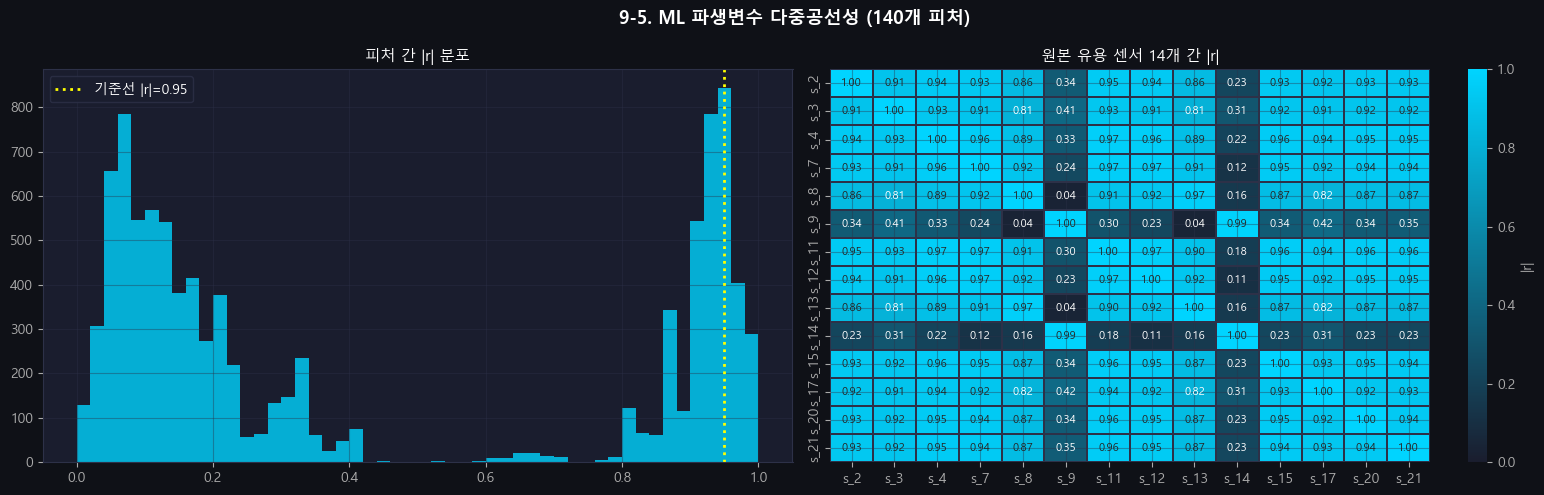


--- 상위 20 고상관 쌍 ---


,피처A,피처B,|r|
0,s_14_lag1,s_14_roll3,0.999990
1,s_9_lag1,s_9_roll3,0.999987
2,s_11_lag1,s_11_roll3,0.999939
3,s_14_roll5,s_14_ema5,0.999938
4,s_12_lag1,s_12_roll3,0.999928
5,s_13_lag1,s_13_roll3,0.999918
6,s_8_lag1,s_8_roll3,0.999917
7,s_9_roll5,s_9_ema5,0.999916
8,s_4_lag1,s_4_roll3,0.999910
9,s_7_lag1,s_7_roll3,0.999905


→ 실제 제거는 모델 피처 중요도 확인 후 결정 권장


In [26]:
def add_temporal_features(
    df, sensors,
    lags=TEMPORAL_LAGS, diffs=TEMPORAL_DIFFS,
    rolls=TEMPORAL_ROLLS, roll_stds=TEMPORAL_ROLL_STDS, emas=TEMPORAL_EMAS
):
    df = df.copy().sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
    created = []
    for s in sensors:
        grp = df.groupby('unit_nr', sort=False)[s]
        for lag in lags:
            col = f'{s}_lag{lag}'; df[col] = grp.shift(lag); created.append(col)
        for d in diffs:
            col = f'{s}_diff{d}'; df[col] = grp.diff(d); created.append(col)
        for r in rolls:
            col = f'{s}_roll{r}'
            df[col] = grp.transform(lambda x, r=r: x.rolling(r, min_periods=1).mean()); created.append(col)
        for r in roll_stds:
            col = f'{s}_roll_std{r}'
            df[col] = grp.transform(lambda x, r=r: x.rolling(r, min_periods=1).std()); created.append(col)
        for e in emas:
            col = f'{s}_ema{e}'
            df[col] = grp.transform(lambda x, e=e: x.ewm(span=e, adjust=False).mean()); created.append(col)
    df[created] = df.groupby('unit_nr', sort=False)[created].transform(
        lambda x: x.bfill().ffill())
    df[created] = df[created].fillna(0.0)
    return df, created

subtrain_ml, TEMPORAL_FEATURES = add_temporal_features(subtrain_s4, USEFUL_SENSORS)
valid_ml,    _                 = add_temporal_features(valid_s4,    USEFUL_SENSORS)
test_ml,     _                 = add_temporal_features(test_s4,     USEFUL_SENSORS)
ML_FEATURES = USEFUL_SENSORS + TEMPORAL_FEATURES

print('=== [ML] 시계열 파생변수 생성 완료 ===')
print(f'원본 센서 수    : {len(USEFUL_SENSORS)}개')
print(f'파생변수 수     : {len(TEMPORAL_FEATURES)}개')
print(f'ML 입력 변수 수 : {len(ML_FEATURES)}개')
print(f'  lag {TEMPORAL_LAGS}  diff {TEMPORAL_DIFFS}  roll {TEMPORAL_ROLLS}  roll_std {TEMPORAL_ROLL_STDS}  ema {TEMPORAL_EMAS}')
print(f'subtrain_ml : {subtrain_ml.shape}  |  결측: {subtrain_ml[ML_FEATURES].isnull().sum().sum()}')
print(f'valid_ml    : {valid_ml.shape}     |  결측: {valid_ml[ML_FEATURES].isnull().sum().sum()}')

# 다중공선성 확인 실행 (Section 9-5)
check_multicollinearity(subtrain_ml, ML_FEATURES)


### 10-1. 롤링 피처 생성 (window=15, ML 보조)

In [27]:
# 롤링 피처 (window=15) — ML 입력 보완용 추가 피처
WINDOW_ROLL = 15

def add_rolling_features(df, sensors, window):
    """이동평균(Mean) + 이동표준편차(Std) 피처 추가"""
    df_res = df.copy()
    for s in sensors:
        df_res[f'{s}_rmean{window}'] = df.groupby('unit_nr')[s].transform(
            lambda x: x.rolling(window, min_periods=1).mean())
        df_res[f'{s}_rstd{window}']  = df.groupby('unit_nr')[s].transform(
            lambda x: x.rolling(window, min_periods=1).std().fillna(0))
    return df_res

subtrain_ml_roll = add_rolling_features(subtrain_ml, USEFUL_SENSORS, WINDOW_ROLL)
valid_ml_roll    = add_rolling_features(valid_ml,    USEFUL_SENSORS, WINDOW_ROLL)
test_ml_roll     = add_rolling_features(test_ml,     USEFUL_SENSORS, WINDOW_ROLL)

rolling_sensor_names = [col for col in subtrain_ml_roll.columns if 's_' in col and col in ML_FEATURES or 'rmean' in col or 'rstd' in col]
print(f'✅ Rolling 피처(window={WINDOW_ROLL}) 추가 완료! 총 피처 수 확인:')
print(f'   ML_FEATURES: {len(ML_FEATURES)}개  |  rolling 추가 후: {len(rolling_sensor_names)}개')


✅ Rolling 피처(window=15) 추가 완료! 총 피처 수 확인:
   ML_FEATURES: 140개  |  rolling 추가 후: 168개


### 10-2. Train / Val 분리 및 데이터셋 구성

📊 ML 데이터셋 크기:
  X_train: (16561, 140)  y_train: (16561,)
  X_val  : (4070, 140)    y_val  : (4070,)
  X_test : (13096, 140)


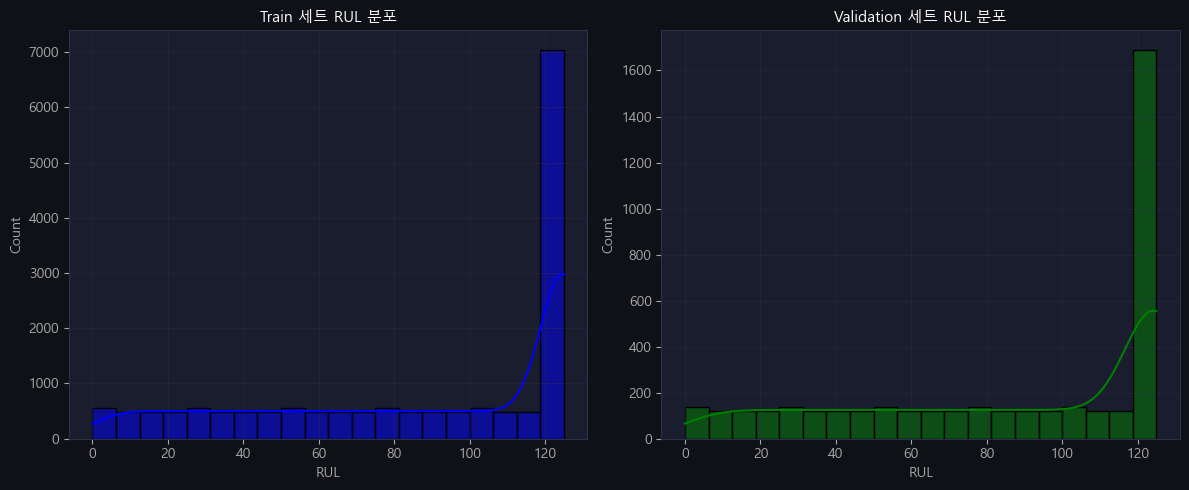


🔍 데이터셋 분리 무결성 검토
  학습용 엔진 수: 80개  |  검증용 엔진 수: 20개
✅ 학습용과 검증용 엔진이 완벽하게 분리되었습니다!


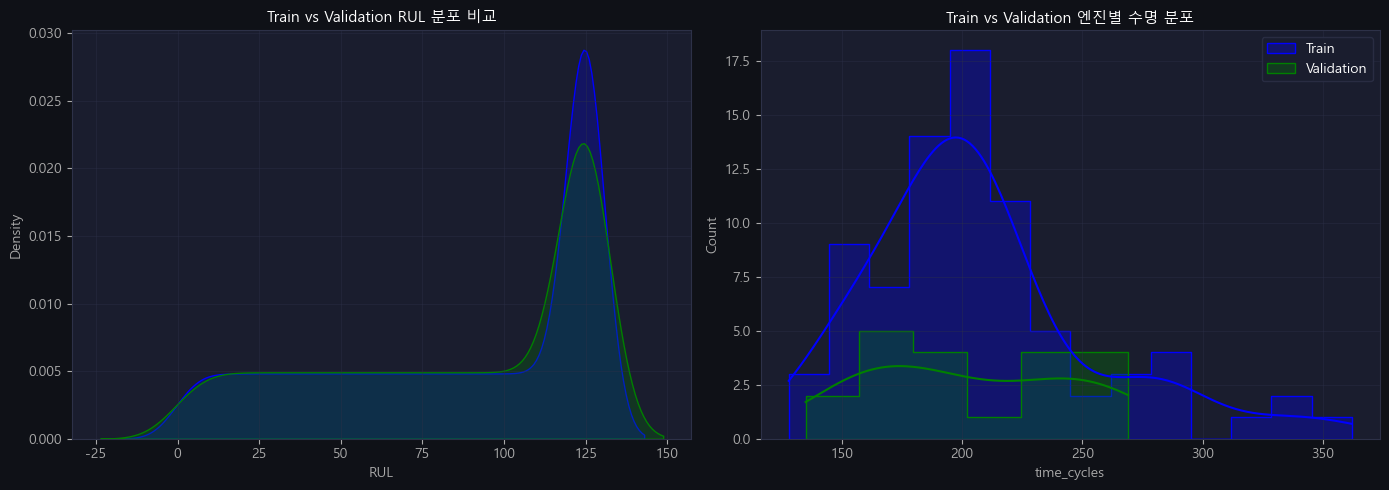

In [28]:
# ML용 X/y 분리
X_ml_train = subtrain_ml_roll[ML_FEATURES]
y_ml_train = subtrain_ml_roll['RUL']
X_ml_val   = valid_ml_roll[ML_FEATURES]
y_ml_val   = valid_ml_roll['RUL']
X_ml_test  = test_ml_roll[ML_FEATURES]

print(f'📊 ML 데이터셋 크기:')
print(f'  X_train: {X_ml_train.shape}  y_train: {y_ml_train.shape}')
print(f'  X_val  : {X_ml_val.shape}    y_val  : {y_ml_val.shape}')
print(f'  X_test : {X_ml_test.shape}')

# RUL 분포 비교
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(y_ml_train, color='blue', kde=True, bins=20)
plt.title('Train 세트 RUL 분포')
plt.subplot(1, 2, 2)
sns.histplot(y_ml_val, color='green', kde=True, bins=20)
plt.title('Validation 세트 RUL 분포')
plt.tight_layout(); plt.show()

# 엔진 ID 중복 체크
train_unit_set = set(subtrain_ml['unit_nr'].unique())
val_unit_set   = set(valid_ml['unit_nr'].unique())
intersection   = train_unit_set.intersection(val_unit_set)
print(f'\n🔍 데이터셋 분리 무결성 검토')
print(f'  학습용 엔진 수: {len(train_unit_set)}개  |  검증용 엔진 수: {len(val_unit_set)}개')
if len(intersection) == 0: print('✅ 학습용과 검증용 엔진이 완벽하게 분리되었습니다!')
else: print(f'❌ 중복 엔진 발견: {intersection}')

# train vs val RUL 분포
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.kdeplot(y_ml_train, label='Train', fill=True, color='blue')
sns.kdeplot(y_ml_val,   label='Validation', fill=True, color='green')
plt.title('Train vs Validation RUL 분포 비교')
plt.subplot(1, 2, 2)
train_mc = subtrain_ml.groupby('unit_nr')['time_cycles'].max()
val_mc   = valid_ml.groupby('unit_nr')['time_cycles'].max()
sns.histplot(train_mc, label='Train', kde=True, color='blue', element='step', alpha=0.3)
sns.histplot(val_mc,   label='Validation', kde=True, color='green', element='step', alpha=0.3)
plt.title('Train vs Validation 엔진별 수명 분포')
plt.legend(); plt.tight_layout(); plt.show()


### 10-3. XGBoost 베이스라인 모델

🚀 XGBoost 모델 학습 시작...
[0]	validation_0-rmse:39.97700
[100]	validation_0-rmse:15.44637
[200]	validation_0-rmse:15.62440
[300]	validation_0-rmse:15.76307
[400]	validation_0-rmse:15.80389
[499]	validation_0-rmse:15.83118
✅ 학습 완료!

📊 XGBoost 검증 세트 결과:
  RMSE        : 15.83
  R2 Score    : 0.8560
  NASA S-Score: 33636.76 (낮을수록 좋음)


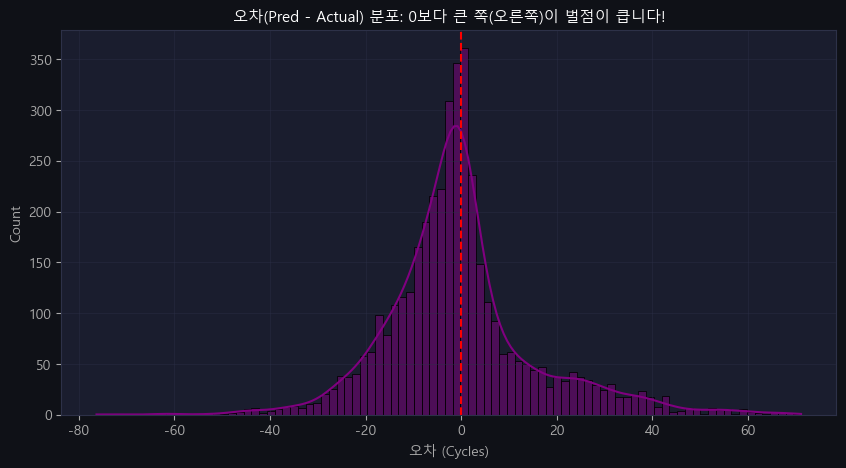

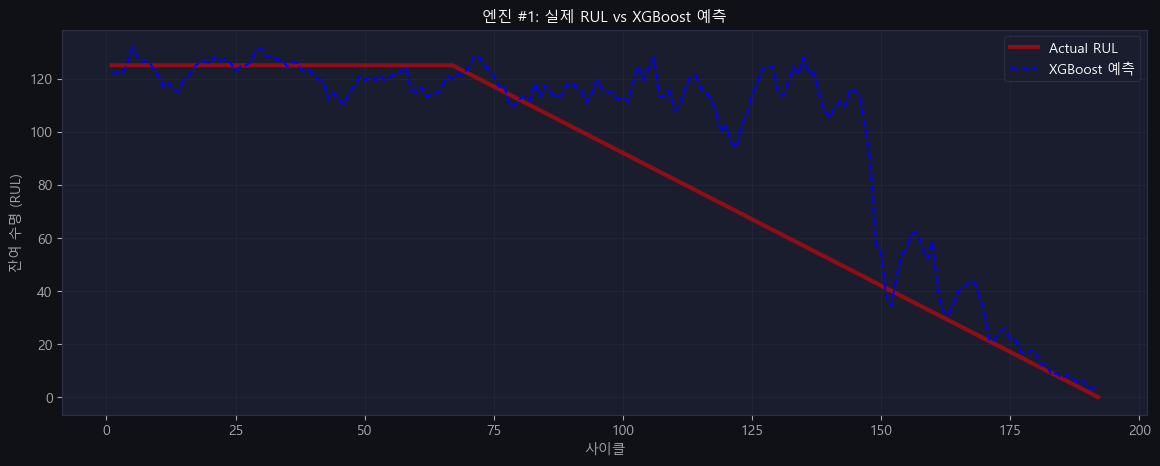

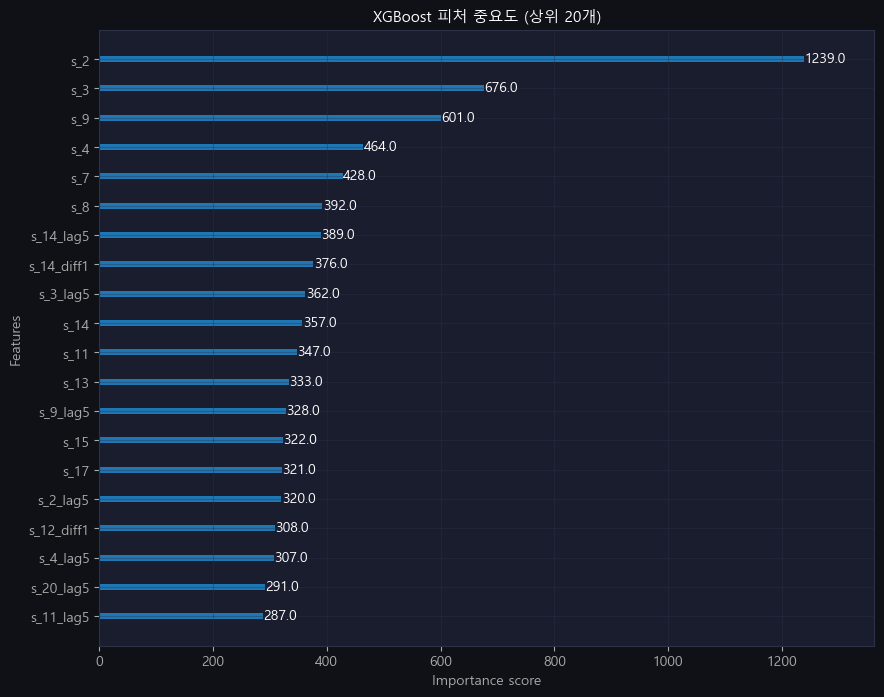

In [29]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# NASA S-Score 계산 함수
def calculate_nasa_score(y_true, y_pred):
    """NASA PHM 대회 공식 평가 지표 — 조기 예측 벌점 < 지연 예측 벌점"""
    d = np.array(y_pred) - np.array(y_true)
    score = 0
    for i in d:
        if i < 0:   # 조기 예측 (벌점 낮음)
            score += (np.exp(-i / 13) - 1)
        else:       # 지연 예측 (벌점 높음)
            score += (np.exp(i / 10) - 1)
    return score

model_xgb = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    random_state=42, n_jobs=-1
)

print('🚀 XGBoost 모델 학습 시작...')
model_xgb.fit(
    X_ml_train, y_ml_train,
    eval_set=[(X_ml_val, y_ml_val)],
    verbose=100
)
print('✅ 학습 완료!')

y_val_pred_xgb = model_xgb.predict(X_ml_val)
rmse_xgb  = np.sqrt(mean_squared_error(y_ml_val, y_val_pred_xgb))
r2_xgb    = r2_score(y_ml_val, y_val_pred_xgb)
nasa_xgb  = calculate_nasa_score(y_ml_val, y_val_pred_xgb)

print(f'\n📊 XGBoost 검증 세트 결과:')
print(f'  RMSE        : {rmse_xgb:.2f}')
print(f'  R2 Score    : {r2_xgb:.4f}')
print(f'  NASA S-Score: {nasa_xgb:.2f} (낮을수록 좋음)')

# 오차 분포 시각화
errors_xgb = y_val_pred_xgb - y_ml_val
plt.figure(figsize=(10, 5))
sns.histplot(errors_xgb, kde=True, color='purple')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('오차(Pred - Actual) 분포: 0보다 큰 쪽(오른쪽)이 벌점이 큽니다!')
plt.xlabel('오차 (Cycles)')
plt.show()

# 예측 추세 시각화 (검증 엔진 1개)
sample_val_unit = valid_units[0]
sample_mask = valid_ml_roll['unit_nr'] == sample_val_unit
plt.figure(figsize=(14, 5))
plt.plot(valid_ml_roll[sample_mask]['time_cycles'], y_ml_val[sample_mask],
         label='Actual RUL', color='red', lw=3, alpha=0.5)
plt.plot(valid_ml_roll[sample_mask]['time_cycles'], y_val_pred_xgb[sample_mask],
         label='XGBoost 예측', color='blue', linestyle='--')
plt.title(f'엔진 #{sample_val_unit}: 실제 RUL vs XGBoost 예측')
plt.xlabel('사이클'); plt.ylabel('잔여 수명 (RUL)'); plt.legend()
plt.show()

# 피처 중요도
plt.figure(figsize=(10, 8))
xgb.plot_importance(model_xgb, max_num_features=20, ax=plt.gca(), importance_type='weight')
plt.title('XGBoost 피처 중요도 (상위 20개)')
plt.show()


### 10-4. LightGBM 모델 + NASA S-Score 비교

In [30]:
import lightgbm as lgb

model_lgb = lgb.LGBMRegressor(
    n_estimators=1000, learning_rate=0.01, max_depth=8,
    num_leaves=31, random_state=42, n_jobs=-1, importance_type='gain'
)

print('🚀 LightGBM 모델 학습 시작...')
model_lgb.fit(
    X_ml_train, y_ml_train,
    eval_set=[(X_ml_val, y_ml_val)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(100)]
)

y_val_pred_lgb = model_lgb.predict(X_ml_val)
rmse_lgb  = np.sqrt(mean_squared_error(y_ml_val, y_val_pred_lgb))
r2_lgb    = r2_score(y_ml_val, y_val_pred_lgb)
nasa_lgb  = calculate_nasa_score(y_ml_val, y_val_pred_lgb)

print(f'\n📊 LightGBM 검증 세트 결과:')
print(f'  RMSE        : {rmse_lgb:.2f}')
print(f'  R2 Score    : {r2_lgb:.4f}')
print(f'  NASA S-Score: {nasa_lgb:.2f}')

print(f'\n📊 XGBoost vs LightGBM 비교:')
comparison = pd.DataFrame({
    '모델': ['XGBoost', 'LightGBM'],
    'RMSE': [round(rmse_xgb, 2), round(rmse_lgb, 2)],
    'R2 Score': [round(r2_xgb, 4), round(r2_lgb, 4)],
    'NASA S-Score': [round(nasa_xgb, 2), round(nasa_lgb, 2)],
})
display(comparison)


🚀 LightGBM 모델 학습 시작...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016923 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 35438
[LightGBM] [Info] Number of data points in the train set: 16561, number of used features: 140
[LightGBM] [Info] Start training from score 86.958819
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 21.3458	valid_0's l2: 455.645
[200]	valid_0's rmse: 16.555	valid_0's l2: 274.068
[300]	valid_0's rmse: 15.607	valid_0's l2: 243.579
[400]	valid_0's rmse: 15.3891	valid_0's l2: 236.825
[500]	valid_0's rmse: 15.3051	valid_0's l2: 234.246
[600]	valid_0's rmse: 15.2942	valid_0's l2: 233.914
Early stopping, best iteration is:
[602]	valid_0's rmse: 15.2928	valid_0's l2: 233.87

📊 LightGBM 검증 세트 결과:
  RMSE        : 15.29
  R2 Score    : 0.8656
  NASA S-Score: 27331.42

📊 XGBoost vs LightGBM 비교:


,모델,RMSE,R2 Score,NASA S-Score
0,XGBoost,15.83,0.8560,33636.76
1,LightGBM,15.29,0.8656,27331.42


---
## 11. [DL 분기] 슬라이딩 윈도우 생성 → Long Format

정규화된 `USEFUL_SENSORS`를 슬라이딩 윈도우로 변환 후 **Long Format CSV**  
LSTM·CNN·Transformer 등 시계열 모델에 활용 가능.

| 파라미터 | 값 | 설명 |
|---|---|---|
| `WINDOW_SIZE` | 30 | 한 샘플당 연속 사이클 수 |
| `STEP` | 1 | 슬라이딩 간격 (stride) |
| 타깃 | 마지막 timestep의 RUL | many-to-one 예측 |

> **Long Format 구조:**  
> `sample_id | timestep | s_2 | ... | s_21 | RUL`  
> - `sample_id`: 윈도우 단위 고유 ID  
> - `timestep`: 윈도우 내 위치 (0 ~ WINDOW_SIZE-1)  
> - `RUL`: 마지막 timestep 기준 타깃값 (모든 행에 동일하게 기재)  
> - **Test**: 엔진별 마지막 30사이클 → 1 샘플. 시계열이 짧으면 앞쪽 zero-pad


In [31]:
WINDOW_SIZE = 30
STEP        = 1
DL_FEATURES = USEFUL_SENSORS   # 원본 정규화 센서만 사용 (파생변수 불필요)

def create_sliding_windows(df, feature_cols, target_col=None,
                           window_size=WINDOW_SIZE, step=STEP):
    """3D 텐서 (n_samples, window_size, n_features) 반환"""
    X_list, y_list = [], []
    for uid in np.sort(df['unit_nr'].unique()):
        udf  = df[df['unit_nr'] == uid].sort_values('time_cycles')
        data = udf[feature_cols].values.astype(np.float32)
        tgt  = udf[target_col].values if target_col else None
        n    = len(data)
        for start in range(0, n - window_size + 1, step):
            end = start + window_size
            X_list.append(data[start:end])
            if tgt is not None:
                y_list.append(tgt[end - 1])
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32) if y_list else None
    return X, y

def create_test_windows(df, feature_cols, rul_series, window_size=WINDOW_SIZE):
    """Test: 엔진별 마지막 window_size 사이클 → 1샘플씩"""
    X_list, y_list = [], []
    for i, uid in enumerate(np.sort(df['unit_nr'].unique())):
        udf  = df[df['unit_nr'] == uid].sort_values('time_cycles')
        data = udf[feature_cols].values.astype(np.float32)
        if len(data) >= window_size:
            X_list.append(data[-window_size:])
        else:
            pad = np.zeros((window_size - len(data), len(feature_cols)), dtype=np.float32)
            X_list.append(np.vstack([pad, data]))
        y_list.append(float(rul_series.iloc[i]))
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

def windows_to_long_df(X, y, feature_cols):
    """3D 텐서 → Long Format DataFrame (sample_id | timestep | features | RUL)"""
    n_samples, win_size, n_feat = X.shape
    rows = []
    for sid in range(n_samples):
        rul_val = float(y[sid])
        for t in range(win_size):
            row = {'sample_id': sid, 'timestep': t}
            for fi, fname in enumerate(feature_cols):
                row[fname] = float(X[sid, t, fi])
            row['RUL'] = rul_val
            rows.append(row)
    col_order = ['sample_id', 'timestep'] + list(feature_cols) + ['RUL']
    return pd.DataFrame(rows, columns=col_order)

# 슬라이딩 윈도우 생성
X_subtrain_dl, y_subtrain_dl = create_sliding_windows(subtrain_s4, DL_FEATURES, 'RUL')
X_valid_dl,    y_valid_dl    = create_sliding_windows(valid_s4,    DL_FEATURES, 'RUL')
X_test_dl,     y_test_dl     = create_test_windows(  test_s4,     DL_FEATURES, rul_df['RUL'])

print('=== [DL] 슬라이딩 윈도우 생성 완료 ===')
print(f'WINDOW_SIZE={WINDOW_SIZE}  STEP={STEP}  DL 피처 수={len(DL_FEATURES)}')
print(f'X_subtrain_dl : {X_subtrain_dl.shape}  y: {y_subtrain_dl.shape}')
print(f'X_valid_dl    : {X_valid_dl.shape}     y: {y_valid_dl.shape}')
print(f'X_test_dl     : {X_test_dl.shape}      y: {y_test_dl.shape}')

# Long Format 변환
dl_subtrain_long = windows_to_long_df(X_subtrain_dl, y_subtrain_dl, DL_FEATURES)
dl_valid_long    = windows_to_long_df(X_valid_dl,    y_valid_dl,    DL_FEATURES)
dl_test_long     = windows_to_long_df(X_test_dl,     y_test_dl,     DL_FEATURES)

print(f'\nLong Format:')
print(f'  subtrain: {dl_subtrain_long.shape}')
print(f'  valid   : {dl_valid_long.shape}')
print(f'  test    : {dl_test_long.shape}')
display(dl_subtrain_long.head(3))


=== [DL] 슬라이딩 윈도우 생성 완료 ===
WINDOW_SIZE=30  STEP=1  DL 피처 수=14
X_subtrain_dl : (14241, 30, 14)  y: (14241,)
X_valid_dl    : (3490, 30, 14)     y: (3490,)
X_test_dl     : (100, 30, 14)      y: (100,)

Long Format:
  subtrain: (427230, 17)
  valid   : (104700, 17)
  test    : (3000, 17)


,sample_id,timestep,s_2,s_3,s_4,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21,RUL
0,0,0,0.043732,0.211552,0.074865,0.886589,0.097168,0.131351,0.008427,0.891739,0.127441,0.182388,0.107529,0.132759,0.801868,0.898842,125.0
1,0,1,0.024353,0.213974,0.104094,0.899620,0.098633,0.132233,0.046211,0.901718,0.088379,0.182575,0.109604,0.133186,0.841980,0.894276,125.0
2,0,2,0.006989,0.202816,0.135859,0.911232,0.104004,0.134075,0.074711,0.907013,0.053223,0.183380,0.104973,0.127926,0.882378,0.894016,125.0


### 11-1. val_eval 생성 — 수명 50~90% 랜덤 절단 (seed=42)

**기존 문제:** val_eval이 마지막 타임스텝(RUL≈0) 사용 → 모델이 0만 예측해도 RMSE≈0  
**해결:** 수명 50~90% 지점 랜덤 절단 → test와 유사한 평가 환경 구성

=== val_eval 생성 (수명 50~90% 절단, seed=42) ===
기존 val_eval RUL 평균: 0.0 (≈0에 가까움 → 모델 평가 왜곡 가능)
개선 val_eval RUL 평균: 62.2 (test 분포와 유사 → 올바른 평가 환경)
ML val_eval shape     : (20, 147)
DL val_eval shape     : (600, 17)


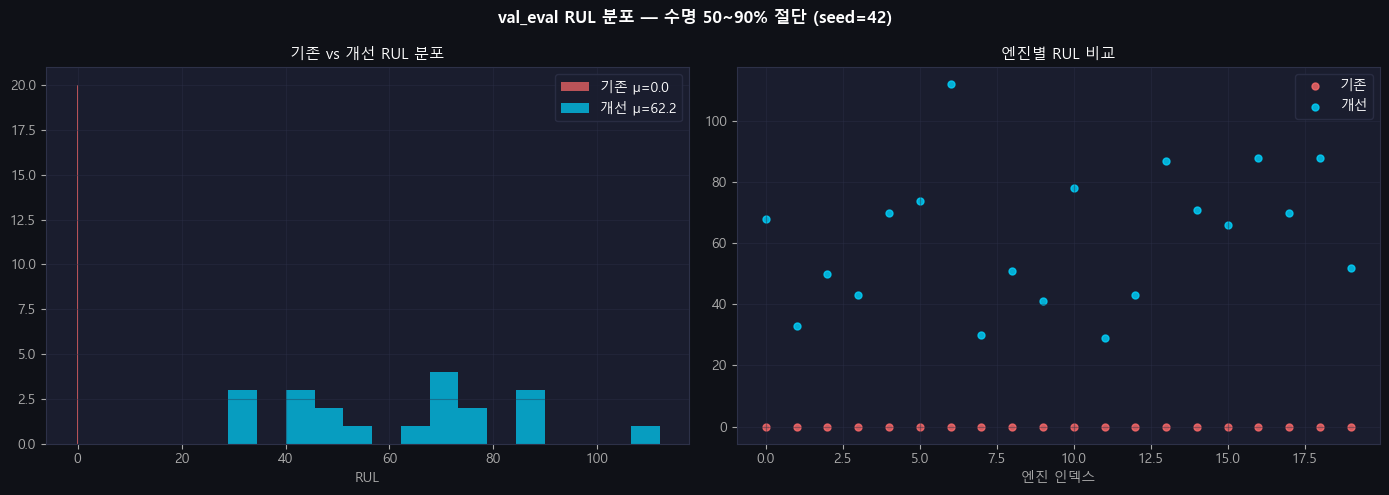

✅ val_eval 생성 완료


In [32]:
print('=== val_eval 생성 (수명 50~90% 절단, seed=42) ===')

WINDOW_SIZE_VE = 30
rng = np.random.RandomState(42)

ml_val_eval_rows, dl_val_eval_X, dl_val_eval_y = [], [], []

for uid in np.sort(valid_s4['unit_nr'].unique()):
    udf     = valid_s4[valid_s4['unit_nr']==uid].sort_values('time_cycles').reset_index(drop=True)
    n       = len(udf)
    cut_idx = max(WINDOW_SIZE_VE, min(int(n * rng.uniform(0.5, 0.9)), n))

    cut_time  = udf.iloc[cut_idx - 1]['time_cycles']
    ml_uid_df = valid_ml[valid_ml['unit_nr'] == uid].sort_values('time_cycles').reset_index(drop=True)
    ml_match  = ml_uid_df[ml_uid_df['time_cycles'] == cut_time]
    if len(ml_match) > 0:
        ml_val_eval_rows.append(ml_match.iloc[0].copy())
    else:
        ml_val_eval_rows.append(ml_uid_df.iloc[min(cut_idx - 1, len(ml_uid_df) - 1)].copy())

    data   = udf[DL_FEATURES].values.astype(np.float32)
    window = data[max(0, cut_idx - WINDOW_SIZE_VE):cut_idx]
    if len(window) < WINDOW_SIZE_VE:
        pad    = np.zeros((WINDOW_SIZE_VE - len(window), len(DL_FEATURES)), dtype=np.float32)
        window = np.vstack([pad, window])
    dl_val_eval_X.append(window)
    dl_val_eval_y.append(float(udf['RUL'].iloc[cut_idx - 1]))

val_eval_ml      = pd.DataFrame(ml_val_eval_rows).reset_index(drop=True)
X_ve             = np.array(dl_val_eval_X, dtype=np.float32)
y_ve             = np.array(dl_val_eval_y, dtype=np.float32)
dl_val_eval_long = windows_to_long_df(X_ve, y_ve, DL_FEATURES)

old_rul = np.array([
    float(valid_s4[valid_s4['unit_nr']==uid].sort_values('time_cycles')['RUL'].iloc[-1])
    for uid in np.sort(valid_s4['unit_nr'].unique())
])

print(f'기존 val_eval RUL 평균: {old_rul.mean():.1f} (≈0에 가까움 → 모델 평가 왜곡 가능)')
print(f'개선 val_eval RUL 평균: {y_ve.mean():.1f} (test 분포와 유사 → 올바른 평가 환경)')
print(f'ML val_eval shape     : {val_eval_ml.shape}')
print(f'DL val_eval shape     : {dl_val_eval_long.shape}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('val_eval RUL 분포 — 수명 50~90% 절단 (seed=42)', fontweight='bold')
axes[0].hist(old_rul, bins=15, color=C[1], alpha=0.7, label=f'기존 μ={old_rul.mean():.1f}')
axes[0].hist(y_ve,    bins=15, color=C[0], alpha=0.7, label=f'개선 μ={y_ve.mean():.1f}')
axes[0].set_title('기존 vs 개선 RUL 분포'); axes[0].set_xlabel('RUL'); axes[0].legend()
axes[1].scatter(range(len(old_rul)), old_rul, color=C[1], s=25, alpha=0.8, label='기존')
axes[1].scatter(range(len(y_ve)),   y_ve,     color=C[0], s=25, alpha=0.8, label='개선')
axes[1].set_title('엔진별 RUL 비교'); axes[1].set_xlabel('엔진 인덱스'); axes[1].legend()
plt.tight_layout(); plt.show()
print('✅ val_eval 생성 완료')
